# Projet BAS — Régression sur le jeu de données *UCI Air Quality*

Ce notebook étudie le jeu de données *UCI Air Quality*, qui regroupe des mesures horaires de pollution atmosphérique, de réponses de capteurs chimiques et de variables météorologiques. L’objectif est de comparer plusieurs méthodes d’apprentissage statistique sur un problème de régression construit à partir de ces observations.

---

## Sommaire

1. [Imports et configuration](#section-1)
2. [Chargement et première inspection](#section-2)
3. [Analyse descriptive](#section-3)
   - [3.1 Statistiques générales](#section-3)
   - [3.2 Valeurs manquantes](#section-3-2)
   - [3.3 Distributions des variables cibles](#section-3-3)
   - [3.4 Corrélations entre variables](#section-3-4)
   - [3.5 Analyse temporelle](#section-3-5)
4. [Préparation finale des données](#section-4)
5. [Séparation entraînement / validation](#section-5)
6. [Modélisation](#section-6)
   - [6.0 Comparaison des stratégies NaN](#section-6-nan)
   - [6.1 Régression linéaire (OLS)](#section-6-1)
   - [6.2 Régression Ridge](#section-6-2)
   - [6.3 Régression Lasso](#section-6-3)
   - [6.4 Elastic Net](#section-6-4)
   - [6.5 Méthode à noyau (KernelRidge RBF)](#section-6-5)
   - [6.6 Réseau de neurones dense (MLP)](#section-6-6)
   - [6.7 Régression en chaîne (RegressorChain)](#section-6-chain)
   - [6.8 Intégration de l'information temporelle](#section-6-time)
   - [6.9 Modèles complémentaires (Random Forest, XGBoost)](#section-6-bonus)
7. [Comparaison des performances](#section-7)
8. [Analyse critique](#section-8)
   - [8.1 Limites inhérentes aux données](#section-8-1)
   - [8.2 Pistes d'amélioration concrètes](#section-8-2)
   - [8.3 Regard critique sur les résultats remarquables](#section-8-3)
   - [8.4 Conclusion générale](#section-8-4)

<a id="section-1"></a>
---
## 1. Imports et configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

# ── Bibliothèques générales ───────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

# ── Sklearn : prétraitement et évaluation ─────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score

# ── Sklearn : modèles ─────────────────────────────────────────────────────────
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, ElasticNet
from sklearn.kernel_ridge import KernelRidge
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import RegressorChain
from sklearn.ensemble import RandomForestRegressor

# ── Bibliothèques optionnelles ────────────────────────────────────────────────
try:
    from xgboost import XGBRegressor
    xgb_available = True
    print("XGBoost disponible")
except ImportError:
    xgb_available = False
    print("XGBoost non installé — pip install xgboost")

try:
    from catboost import CatBoostRegressor
    cat_available = True
    print("CatBoost disponible")
except ImportError:
    cat_available = False
    print("CatBoost non installé — pip install catboost")

# ── Configuration globale ─────────────────────────────────────────────────────
RANDOM_STATE = 42
TRAIN_RATIO  = 0.8
TARGETS      = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

XGBoost disponible
CatBoost disponible


<a id="section-2"></a>
---
## 2. Chargement et première inspection

Le fichier fourni par l'UCI présente plusieurs particularités à traiter dès le chargement :

- **Séparateur** `;` (et non la virgule habituelle),
- **Décimales** écrites avec des virgules (format européen),
- **Deux colonnes vides** en fin de fichier (`Unnamed: 15` et `Unnamed: 16`),
- **Code de valeur manquante** : `-200` (convention propre à ce dataset, documentée par l'UCI).

In [2]:
# Chargement brut avec les paramètres adaptés au format du fichier
df = pd.read_csv("AirQualityUCI.csv", sep=";", decimal=",")

print("Dimensions initiales :", df.shape)
display(df.head())
display(df.tail())  # tail() affiche les 5 dernières lignes

Dimensions initiales : (9471, 17)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Suppression des deux dernières colonnes vides (artefacts du fichier CSV)
df = df.drop(columns=["Unnamed: 15", "Unnamed: 16"], errors="ignore")

# Suppression des lignes où TOUTES les valeurs sont manquantes
df = df.dropna(how="all")

# Remplacement de -200 par NaN : convention UCI pour les données absentes
df = df.replace(-200, np.nan)

# Suppression immédiate de NMHC(GT) : >90% de valeurs manquantes,
# cette variable est inexploitable et fausserait les statistiques descriptives
df = df.drop(columns=["NMHC(GT)"], errors="ignore")

print("Dimensions après premier nettoyage :", df.shape)
display(df.head())

Dimensions après premier nettoyage : (9357, 14)


,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [4]:
# Construction d'une variable temporelle unifiée à partir des colonnes Date et Time.
# errors='coerce' : les lignes mal formées deviennent NaT plutôt que lever une erreur.
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

# Tri chronologique pour garantir l'ordre temporel des observations
df = df.sort_values("Datetime").reset_index(drop=True)

display(df[["Date", "Time", "Datetime"]].head())

,Date,Time,Datetime
0,10/03/2004,18.00.00,2004-03-10 18:00:00
1,10/03/2004,19.00.00,2004-03-10 19:00:00
2,10/03/2004,20.00.00,2004-03-10 20:00:00
3,10/03/2004,21.00.00,2004-03-10 21:00:00
4,10/03/2004,22.00.00,2004-03-10 22:00:00


In [5]:
# Vue d'ensemble du DataFrame : types de colonnes, valeurs non-nulles, mémoire
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   str           
 1   Time           9357 non-null   str           
 2   CO(GT)         7674 non-null   float64       
 3   PT08.S1(CO)    8991 non-null   float64       
 4   C6H6(GT)       8991 non-null   float64       
 5   PT08.S2(NMHC)  8991 non-null   float64       
 6   NOx(GT)        7718 non-null   float64       
 7   PT08.S3(NOx)   8991 non-null   float64       
 8   NO2(GT)        7715 non-null   float64       
 9   PT08.S4(NO2)   8991 non-null   float64       
 10  PT08.S5(O3)    8991 non-null   float64       
 11  T              8991 non-null   float64       
 12  RH             8991 non-null   float64       
 13  AH             8991 non-null   float64       
 14  Datetime       9357 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(12

Le dataset contient **9 357 observations** et **15 colonnes** après nettoyage. On y trouve :
- des variables de date/heure (`Date`, `Time`, `Datetime`),
- des **concentrations directes** de polluants mesurées par un analyseur de référence,
- des **réponses de capteurs électrochimiques** (`PT08.S1` à `PT08.S5`), qui fournissent des mesures indirectes liées à la qualité de l’air,
- des **variables météorologiques** : température (`T`), humidité relative (`RH`) et humidité absolue (`AH`).

Le problème étudié dans la suite est un problème de régression supervisée traité **cible par cible**. On cherche à prédire les concentrations de référence `CO(GT)`, `C6H6(GT)`, `NOx(GT)` et `NO2(GT)` à partir des réponses des capteurs `PT08.*` et des variables météorologiques `T`, `RH`, `AH`. Les colonnes temporelles servent surtout à conserver l’ordre chronologique des observations au moment du découpage entraînement / validation.

La variable `NMHC(GT)` est bien présente dans le jeu de données, mais elle contient une très forte proportion de valeurs manquantes ; elle ne sera donc pas retenue comme cible principale dans la suite de l’étude. Toutes les variables numériques sont en `float64`, ce qui est cohérent avec un problème de régression.


<a id="section-3"></a>
---
## 3. Analyse descriptive

### 3.1 Statistiques générales

In [6]:
# Statistiques descriptives classiques pour chaque variable numérique
display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
CO(GT),7674.0,2.15275,0.1,1.1,1.8,2.9,11.9,1.453252
PT08.S1(CO),8991.0,1099.833166,647.0,937.0,1063.0,1231.0,2040.0,217.080037
C6H6(GT),8991.0,10.083105,0.1,4.4,8.2,14.0,63.7,7.44982
PT08.S2(NMHC),8991.0,939.153376,383.0,734.5,909.0,1116.0,2214.0,266.831429
NOx(GT),7718.0,246.896735,2.0,98.0,180.0,326.0,1479.0,212.979168
PT08.S3(NOx),8991.0,835.493605,322.0,658.0,806.0,969.5,2683.0,256.81732
NO2(GT),7715.0,113.091251,2.0,78.0,109.0,142.0,340.0,48.370108
PT08.S4(NO2),8991.0,1456.264598,551.0,1227.0,1463.0,1674.0,2775.0,346.206794
PT08.S5(O3),8991.0,1022.906128,221.0,731.5,963.0,1273.5,2523.0,398.484288
T,8991.0,18.317829,-1.9,11.8,17.8,24.4,44.6,8.832116


Quelques observations importantes issues de ce tableau :

- **Échelles très hétérogènes** : `NOx(GT)` varie de 2 à 1 479, tandis que `CO(GT)` va de 0,1 à 11,9. Les capteurs `PT08.Sx` opèrent sur des plages de l'ordre de 300–2 700. Une **normalisation sera indispensable** avant la modélisation, en particulier pour Ridge, Lasso, SVR et le réseau de neurones.
- **`NOx(GT)` est très dispersé** : son écart-type (~ 213) est presque aussi grand que sa moyenne (~ 247), ce qui traduit une forte variabilité et laisse présager que sa prédiction sera plus difficile que celle des autres cibles.
- **`NO2(GT)` est la cible la plus resserrée** : avec un écart-type de ~48 pour une moyenne de ~113, sa distribution est nettement moins étalée que celle de `NOx(GT)`, bien qu'elle reste asymétrique.
- **`C6H6(GT)`** présente une moyenne de ~10 µg/m³ mais un maximum de 63,7 — signe d'épisodes ponctuels intenses qui peuvent peser sur les métriques MSE.

<a id="section-3-2"></a>
### 3.2 Valeurs manquantes

In [7]:
# Calcul du nombre et du pourcentage de valeurs manquantes par variable
missing_counts = df.isna().sum()
missing_percent = 100 * missing_counts / len(df)

missing_table = pd.DataFrame({
    "Nombre de valeurs manquantes": missing_counts,
    "Pourcentage (%)": missing_percent.round(1)
}).sort_values("Pourcentage (%)", ascending=False)

display(missing_table)

,Nombre de valeurs manquantes,Pourcentage (%)
CO(GT),1683,18.0
NOx(GT),1639,17.5
NO2(GT),1642,17.5
C6H6(GT),366,3.9
PT08.S2(NMHC),366,3.9
PT08.S3(NOx),366,3.9
PT08.S1(CO),366,3.9
T,366,3.9
RH,366,3.9
PT08.S4(NO2),366,3.9


**`NMHC(GT)`** est la variable la plus problématique, avec plus de **90 % de valeurs manquantes**. La conserver imposerait de supprimer presque toutes les observations ou de faire une imputation très incertaine — elle sera donc **exclue** de la modélisation.

Les variables cibles `CO(GT)`, `NOx(GT)` et `NO2(GT)` présentent environ **17–18 % de valeurs manquantes**. Pour chaque cible, on filtrera les lignes où cette cible est renseignée lors de la séparation entraînement/validation.

Un groupe de variables (`PT08.Sx`, `T`, `RH`, `AH`, `C6H6(GT)`) présente exactement **366 valeurs manquantes** (~3,9 %), ce qui suggère une période commune d'interruption des capteurs.

<a id="section-3-3"></a>
### 3.3 Distributions des variables cibles

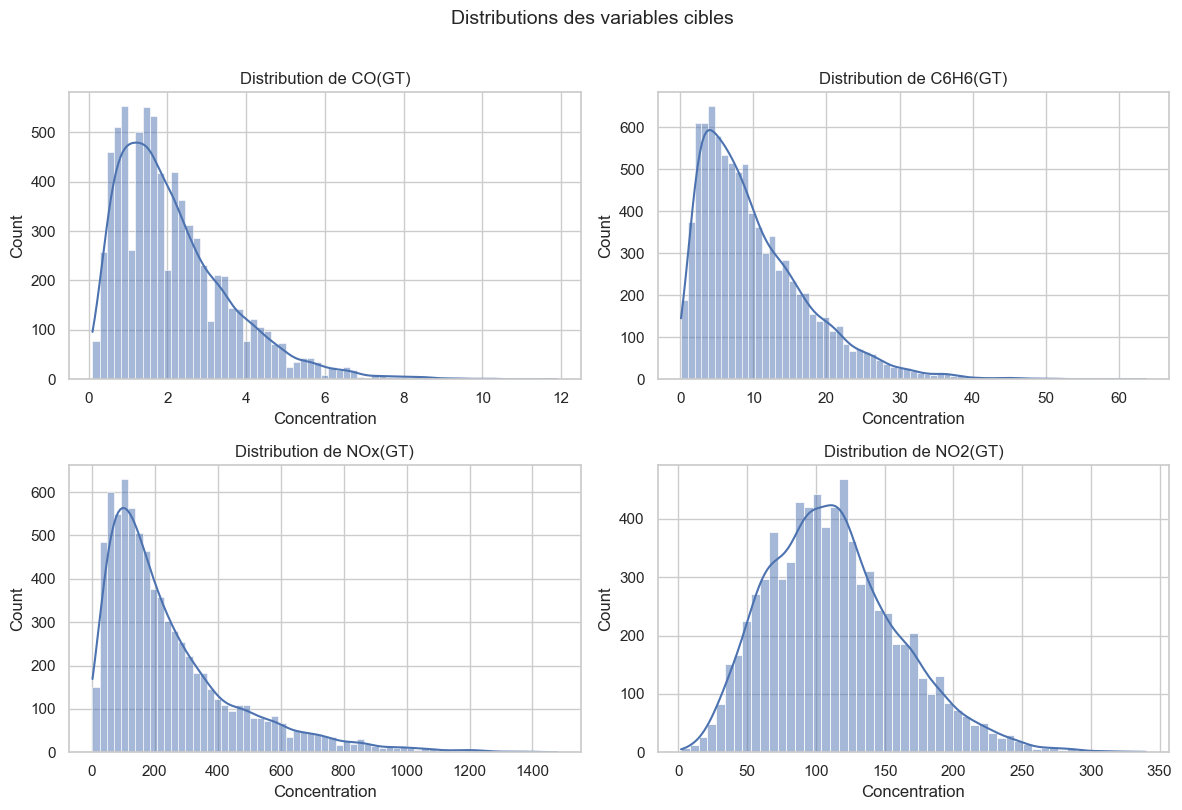

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, target in zip(axes.ravel(), TARGETS):
    # On ignore les NaN pour l'affichage
    sns.histplot(df[target].dropna(), kde=True, ax=ax)
    ax.set_title(f"Distribution de {target}")
    ax.set_xlabel("Concentration")

plt.suptitle("Distributions des variables cibles", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Les quatre variables cibles présentent toutes une **asymétrie droite**, mais avec des profils distincts visibles sur les histogrammes :

- **`CO(GT)`** : distribution concentrée entre 0 et 3 mg/m³, avec une queue s'étirant jusqu'à ~12. La majorité des observations correspond à des niveaux de pollution modérés.
- **`C6H6(GT)`** : pic prononcé autour de 4–8 µg/m³ et une queue longue atteignant ~60 µg/m³, confirmant l'existence d'épisodes ponctuels intenses.
- **`NOx(GT)`** : la distribution la plus étalée des quatre, avec un pic sous 200 ppb mais une queue extrême dépassant 1 400 ppb — cohérent avec l'écart-type élevé observé précédemment.
- **`NO2(GT)`** : la plus proche d'une distribution symétrique, avec une forme en cloche centrée autour de 100 µg/m³, bien que légèrement asymétrique à droite.

Cette asymétrie implique que les métriques classiques (MSE, MAE) seront sensibles aux pics de pollution — les modèles tendront à sous-estimer les épisodes extrêmes, un point à garder en tête lors de l'analyse des performances.

<a id="section-3-4"></a>
### 3.4 Corrélations entre variables

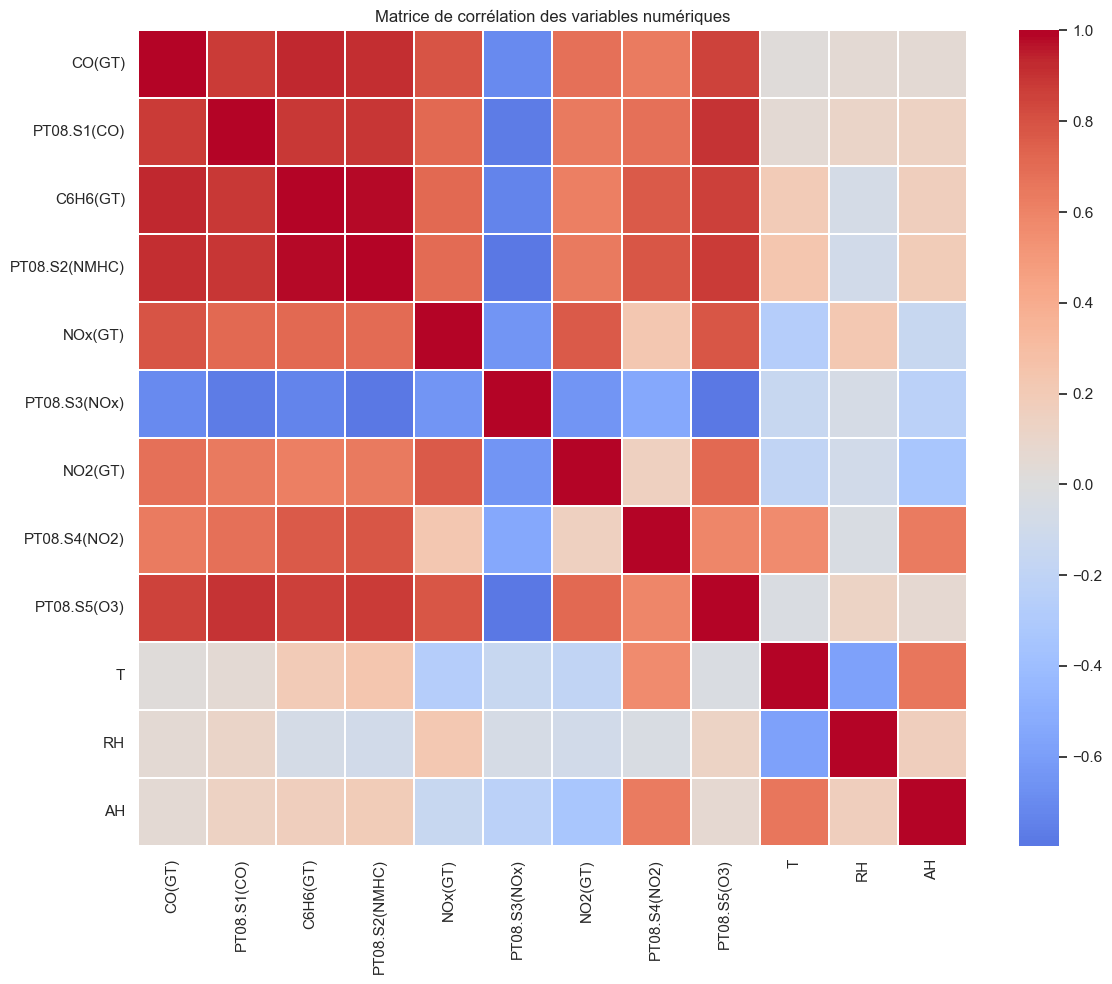

In [9]:
# Calcul de la matrice de corrélation sur les variables numériques uniquement
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Matrice de corrélation des variables numériques")
plt.tight_layout()
plt.show()

In [10]:
# Table des corrélations entre les features (hors cibles) et chacune des cibles
# On exclut les lignes correspondant aux cibles elles-mêmes pour ne garder que les prédicteurs
corr_with_targets = corr[TARGETS].drop(index=TARGETS, errors="ignore")
corr_with_targets = corr_with_targets.sort_values(by="CO(GT)", ascending=False)

display(
    corr_with_targets
    .style
    .background_gradient(cmap="coolwarm", axis=None, vmin=-1, vmax=1)
    .format("{:.2f}")
)

,CO(GT),C6H6(GT),NOx(GT),NO2(GT)
PT08.S2(NMHC),0.92,0.98,0.70,0.65
PT08.S1(CO),0.88,0.88,0.71,0.64
PT08.S5(O3),0.85,0.87,0.79,0.71
PT08.S4(NO2),0.63,0.77,0.23,0.16
RH,0.05,-0.06,0.22,-0.09
AH,0.05,0.17,-0.15,-0.34
T,0.02,0.20,-0.27,-0.19
PT08.S3(NOx),-0.70,-0.74,-0.66,-0.65


> **Note :** `NMHC(GT)` n'apparaît plus dans la matrice de corrélation car elle a été exclue dès le chargement (section 2). La table ci-dessus ne présente donc que les variables exploitables.

Plusieurs observations importantes se dégagent :

- **`PT08.S2(NMHC)`** est le prédicteur le plus corrélé à toutes les cibles : 0,92 pour `CO(GT)`, 0,98 pour `C6H6(GT)`, 0,70 pour `NOx(GT)` et 0,65 pour `NO2(GT)`. Il domine l'ensemble du tableau, ce qui s'explique par sa sensibilité aux hydrocarbures dont le benzène est le composant majoritaire.
- **`PT08.S1(CO)`** et **`PT08.S5(O3)`** suivent avec des corrélations élevées (0,85–0,88) sur `CO(GT)` et `C6H6(GT)`, confirmant les sources communes liées au trafic automobile.
- **`PT08.S3(NOx)`** est le seul prédicteur **négativement corrélé** à toutes les cibles (jusqu'à -0,74 pour `C6H6(GT)`, -0,66 pour `NOx(GT)`), ce qui reflète son comportement inversé visible dans la heatmap.
- **Multicolinéarité entre prédicteurs** : plusieurs capteurs `PT08.Sx` sont très corrélés entre eux. Cette situation dégrade les estimations de la régression linéaire ordinaire, ce qui **motivera le recours à Ridge et Lasso**.
- **`T`, `RH` et `AH`** sont peu corrélés aux cibles — ils apportent une information complémentaire (contexte météo) mais ne sont pas les prédicteurs dominants.

<a id="section-3-5"></a>
### 3.5 Analyse temporelle

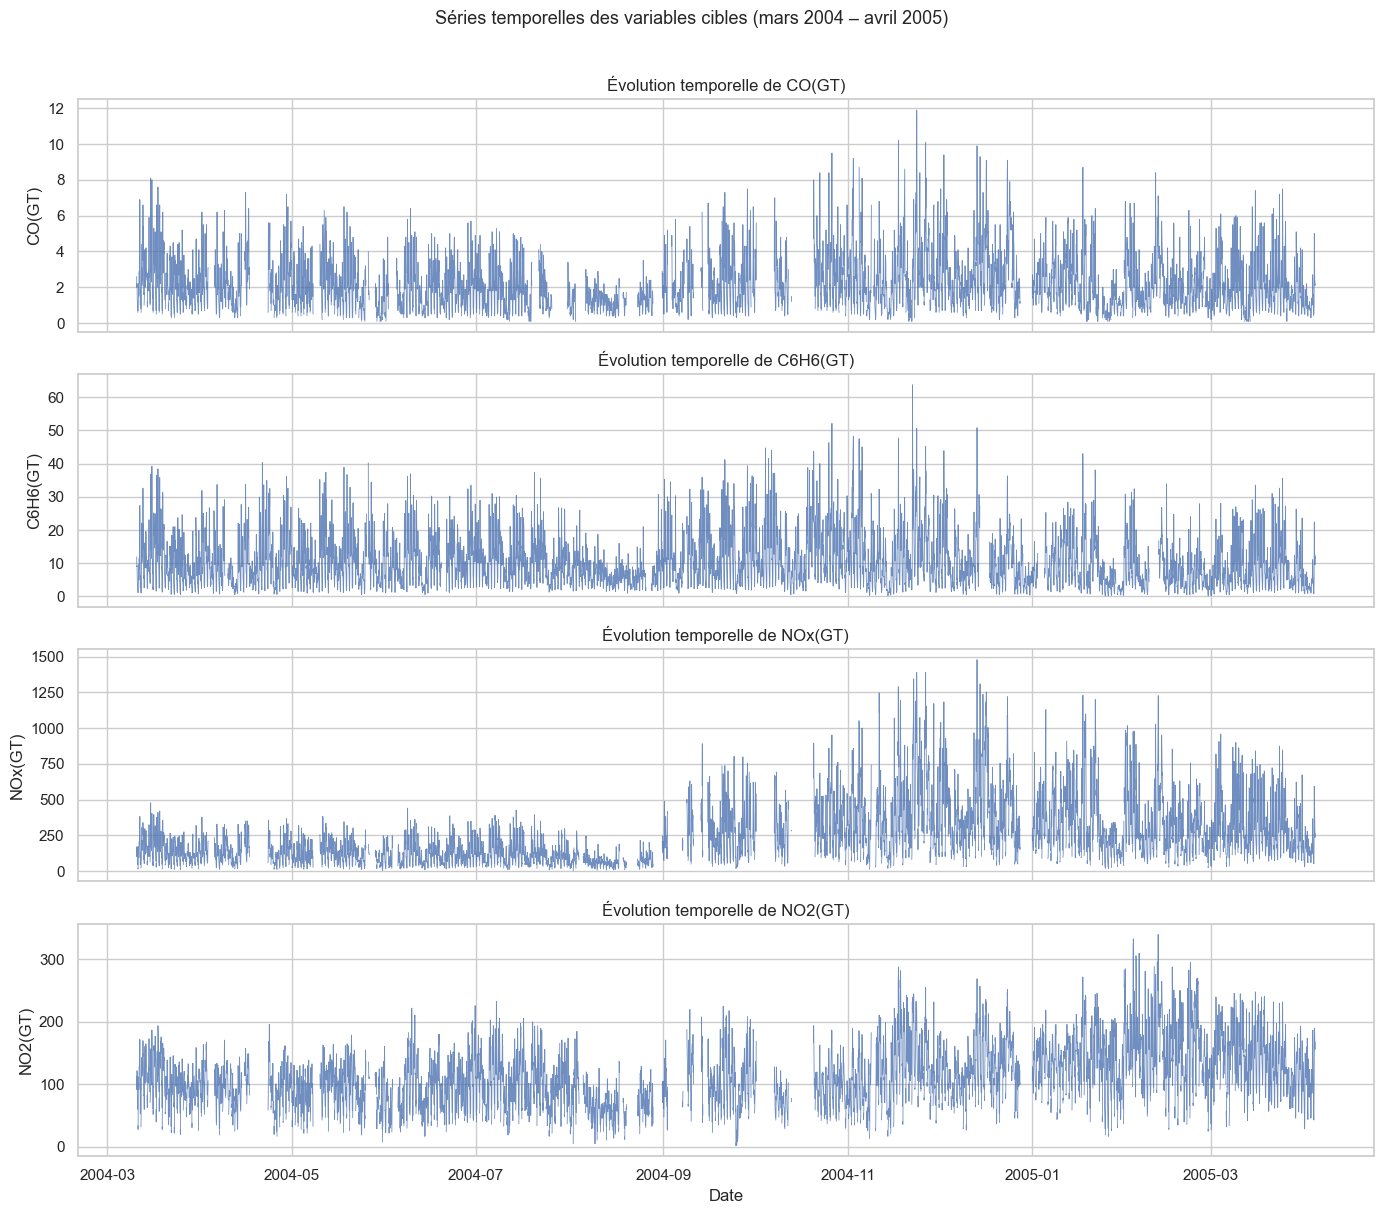

In [11]:
# Évolution temporelle des quatre concentrations sur toute la période
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for ax, target in zip(axes, TARGETS):
    ax.plot(df["Datetime"], df[target], linewidth=0.6, alpha=0.8)
    ax.set_title(f"Évolution temporelle de {target}")
    ax.set_ylabel(target)

axes[-1].set_xlabel("Date")
plt.suptitle("Séries temporelles des variables cibles (mars 2004 – avril 2005)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

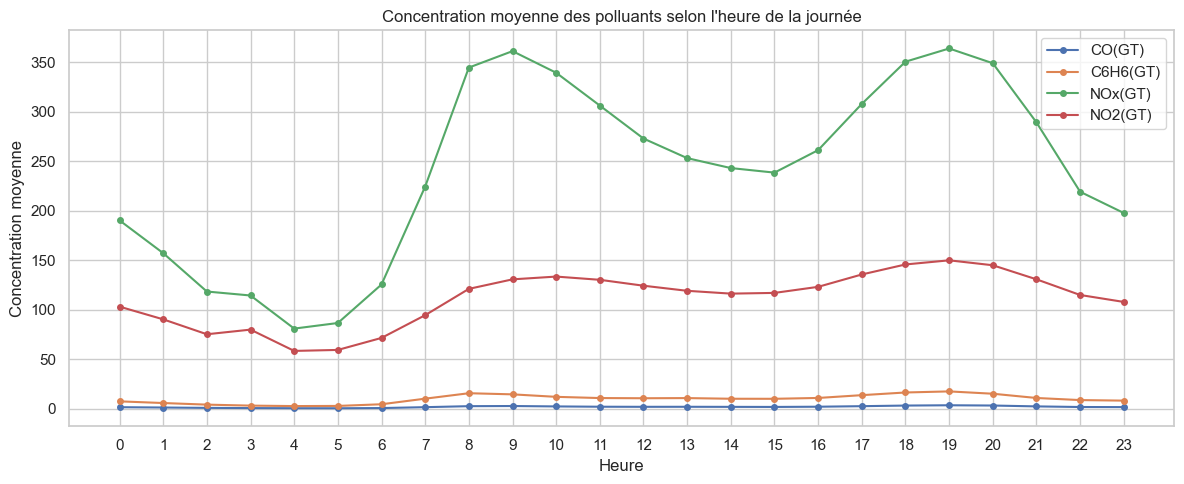

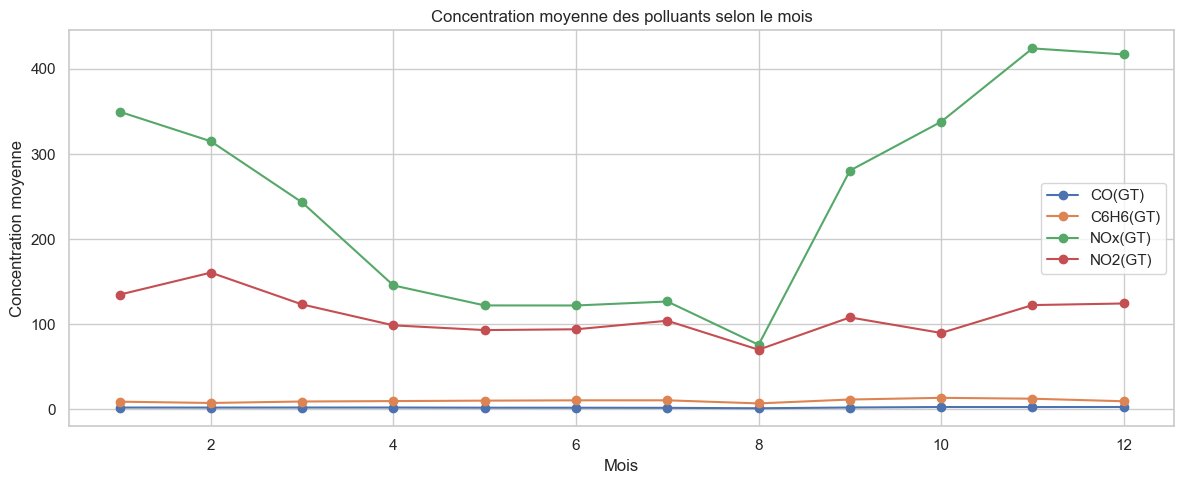

In [12]:
# Extraction de l'heure et du mois pour l'analyse de saisonnalité
df["Hour"] = df["Datetime"].dt.hour
df["Month"] = df["Datetime"].dt.month

# --- Profil horaire : concentration moyenne par heure de la journée ---
fig, ax = plt.subplots(figsize=(12, 5))
hourly_means = df.groupby("Hour")[TARGETS].mean()
hourly_means.plot(ax=ax, marker="o", markersize=4)
ax.set_title("Concentration moyenne des polluants selon l'heure de la journée")
ax.set_xlabel("Heure")
ax.set_ylabel("Concentration moyenne")
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

# --- Profil mensuel : concentration moyenne par mois ---
fig, ax = plt.subplots(figsize=(12, 5))
monthly_means = df.groupby("Month")[TARGETS].mean()
monthly_means.plot(ax=ax, marker="o")
ax.set_title("Concentration moyenne des polluants selon le mois")
ax.set_xlabel("Mois")
ax.set_ylabel("Concentration moyenne")
plt.tight_layout()
plt.show()

L'analyse temporelle révèle deux niveaux de saisonnalité :

**Profil intra-journalier :**
On observe deux pics nets pour `CO(GT)` et `NOx(GT)` : l'un vers 8–9h et l'autre vers 18–19h, correspondant aux heures de pointe du trafic automobile. `C6H6(GT)` reproduit le même schéma (sources communes au CO). `NO2(GT)` suit un profil similaire mais plus lissé.

**Profil mensuel :**
Les concentrations sont plus élevées en hiver (novembre–janvier) et plus faibles en été, ce qui s'explique par les inversions thermiques hivernales favorisant l'accumulation des polluants.

> **Note importante pour la suite — risque de data leakage :** ces données sont **temporellement structurées**. Un split aléatoire (`train_test_split` classique) utiliserait des observations du futur pour entraîner le modèle, ce qui biaiserait les performances estimées. Il faudra donc impérativement utiliser un **split chronologique** lors de la séparation entraînement/validation.

<a id="section-4"></a>
---
## 4. Préparation finale des données

Avant de passer à la modélisation, on effectue les dernières opérations de nettoyage :
1. Suppression de `NMHC(GT)` (>90 % de valeurs manquantes — inutilisable),
2. Suppression des colonnes temporelles et auxiliaires (`Date`, `Time`, `Datetime`, `Hour`, `Month`),
3. Définition du jeu de features numériques (`feature_cols`) commun à toutes les cibles.

In [13]:
# Colonnes à exclure : identifiants temporels et NMHC(GT) inutilisable
cols_to_drop = ["Date", "Time", "Datetime", "Hour", "Month", "NMHC(GT)"]
df_model = df.drop(columns=cols_to_drop, errors="ignore")

# Définition des colonnes de features : tout sauf les cibles
feature_cols = [c for c in df_model.columns if c not in TARGETS]

print("Variables explicatives retenues :")
print(feature_cols)
print(f"\n→ {len(feature_cols)} features, {len(TARGETS)} cibles.")
print("\nDimensions finales du DataFrame de modélisation :", df_model.shape)

Variables explicatives retenues :
['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

→ 8 features, 4 cibles.

Dimensions finales du DataFrame de modélisation : (9357, 12)


Le jeu de données est maintenant prêt pour la modélisation. Pour chaque cible, on travaillera sur le sous-ensemble des lignes où cette cible **et** toutes les features sont renseignées (un `dropna()` par cible lors de la séparation entraînement/validation, dans la section suivante).

<a id="section-5"></a>
---
## 5. Séparation entraînement / validation

On sépare ici les données en un jeu d'entraînement et un jeu de validation.

**Pourquoi un split chronologique ?**
Nos données sont des mesures horodatées collectées sur une année entière. Un split aléatoire (comme `train_test_split` de sklearn) mélangerait des observations passées et futures, ce qui permettrait au modèle d'apprendre indirectement sur des données qu'il est censé prédire — c'est du **data leakage**. La bonne pratique sur des données temporelles est de couper selon le temps : on entraîne sur le passé, on évalue sur le futur.

**Proportion retenue : 80 % train / 20 % test.**
Avec ~9 000 observations disponibles, cela donne environ 7 000 points d'entraînement et 1 800 de test — suffisant pour les deux phases.

**Gestion des valeurs manquantes :**
Comme chaque cible a ses NaN à des endroits différents, le filtrage se fait **par cible** : pour chaque cible, on conserve uniquement les lignes où cette cible *et* toutes les features sont renseignées, puis on effectue le split chronologique sur ce sous-ensemble.

In [14]:
# Dictionnaire qui contiendra les données train/test pour chaque cible.
# Structure : splits["CO(GT)"] = {"X_train": ..., "X_test": ..., "y_train": ..., "y_test": ...}
splits = {}

TRAIN_RATIO = 0.8  # 80 % des observations pour l'entraînement

for target in TARGETS:
    # 1. Sélection des lignes sans NaN dans les features ni dans la cible courante
    cols_needed = feature_cols + [target]
    df_target = df_model[cols_needed].dropna().reset_index(drop=True)

    # 2. Calcul de l'indice de coupure
    #    Les données sont déjà triées chronologiquement depuis la section 2
    cutoff = int(len(df_target) * TRAIN_RATIO)

    # 3. Split chronologique : les 'cutoff' premières lignes en train, le reste en test
    X_train = df_target[feature_cols].iloc[:cutoff]
    X_test  = df_target[feature_cols].iloc[cutoff:]
    y_train = df_target[target].iloc[:cutoff]
    y_test  = df_target[target].iloc[cutoff:]

    splits[target] = {
        "X_train": X_train,
        "X_test":  X_test,
        "y_train": y_train,
        "y_test":  y_test,
    }

# Récapitulatif des tailles de chaque split
print(f"Proportion train/test : {TRAIN_RATIO:.0%} / {1 - TRAIN_RATIO:.0%}")
print()
print(f"{'Cible':<15} {'N total':>8} {'N train':>8} {'N test':>8}")
print("-" * 45)
for target, s in splits.items():
    n_total = len(s["X_train"]) + len(s["X_test"])
    print(f"{target:<15} {n_total:>8} {len(s['X_train']):>8} {len(s['X_test']):>8}")

Proportion train/test : 80% / 20%

Cible            N total  N train   N test
---------------------------------------------
CO(GT)              7344     5875     1469
C6H6(GT)            8991     7192     1799
NOx(GT)             7396     5916     1480
NO2(GT)             7393     5914     1479


Le tableau ci-dessus confirme que chaque cible dispose de son propre sous-ensemble, dont la taille varie selon les NaN qui lui sont propres :

- `C6H6(GT)` conserve le plus grand nombre d'observations (~366 NaN seulement),
- `CO(GT)`, `NOx(GT)` et `NO2(GT)` perdent ~17–18 % de lignes supplémentaires.

Dans tous les cas, les jeux d'entraînement restent largement suffisants pour l'apprentissage des modèles.

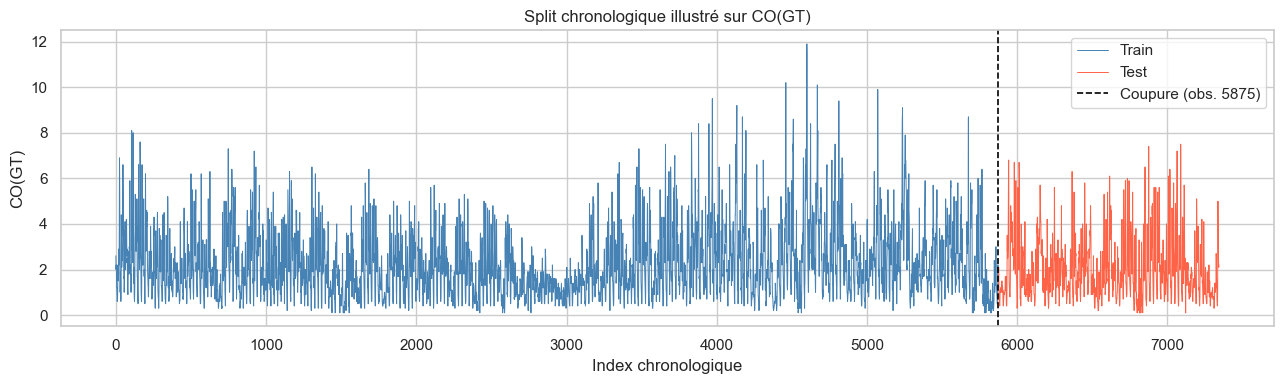

In [15]:
# Visualisation de la coupure temporelle pour vérifier le split visuellement.
# On illustre sur CO(GT) à titre d'exemple — le principe est identique pour les autres cibles.

example_target = "CO(GT)"
s = splits[example_target]
n_train = len(s["y_train"])

fig, ax = plt.subplots(figsize=(13, 4))

# Segment train (bleu) et segment test (rouge)
ax.plot(range(n_train),
        s["y_train"].values,
        color="steelblue", linewidth=0.7, label="Train")
ax.plot(range(n_train, n_train + len(s["y_test"])),
        s["y_test"].values,
        color="tomato", linewidth=0.7, label="Test")

# Ligne verticale indiquant la coupure
ax.axvline(n_train, color="black", linestyle="--", linewidth=1.2,
           label=f"Coupure (obs. {n_train})")

ax.set_title(f"Split chronologique illustré sur {example_target}")
ax.set_xlabel("Index chronologique")
ax.set_ylabel(example_target)
ax.legend()
plt.tight_layout()
plt.show()

Le graphique confirme que la coupure est bien chronologique : le modèle sera entraîné sur la partie bleue (passé) et évalué sur la partie rouge (futur). On note que le segment de test présente des **niveaux de concentration légèrement plus élevés et une variabilité plus forte** que le segment d'entraînement — ce qui illustre la dérive saisonnière : le train couvre principalement les mois d'été/automne 2004, tandis que le test correspond à l'hiver/printemps 2005, période où les concentrations de polluants sont naturellement plus élevées. Ce biais de distribution entre train et test pénalisera tous les modèles de façon uniforme et explique en partie les performances modestes observées sur certaines cibles.

Le dictionnaire `splits` est maintenant prêt. Dans chaque section de modélisation, on y accèdera simplement par :
```python
X_train = splits[target]["X_train"]
X_test  = splits[target]["X_test"]
y_train = splits[target]["y_train"]
y_test  = splits[target]["y_test"]
```

<a id="section-6"></a>
---
## 6. Modélisation

Les données étant prêtes, on commence par comparer les principales méthodes de régression du projet, puis on étudie quelques extensions complémentaires.

| Section | Méthode | Hyperparamètres principaux |
|---|---|---|
| 6.1 | Régression linéaire (OLS) | — |
| 6.2 | Ridge | `alpha` (via `RidgeCV` + `TimeSeriesSplit`) |
| 6.3 | Lasso | `alpha` (via `LassoCV` + `TimeSeriesSplit`) |
| 6.4 | Méthode à noyau (KernelRidge RBF) | `alpha`, `gamma` |
| 6.5 | Réseau de neurones dense (MLP) | architecture, `learning_rate`, `alpha` |

Pour aller un peu plus loin, il nous a également paru intéressant d’étudier l’apport d’une information temporelle explicite dans les variables explicatives. En effet, l’analyse descriptive a mis en évidence des variations selon l’heure et selon la période de l’année. On testera donc plus loin une version enrichie du problème dans laquelle quelques variables temporelles simples sont ajoutées afin de vérifier si elles peuvent améliorer la qualité prédictive.

**Structure commune à chaque sous-section :**
- Un rappel du principe mathématique de la méthode et de ses hyperparamètres,
- Un `Pipeline` sklearn composé d'un `StandardScaler` suivi du modèle — la normalisation est ajustée uniquement sur le train,
- Un entraînement et une évaluation **par cible** (boucle sur `TARGETS`),
- Une discussion sur l'influence des hyperparamètres et les résultats obtenus.

**Métriques retenues :**
- **RMSE** (Root Mean Squared Error) — pénalise fortement les grandes erreurs, sensible aux pics,
- **MAE** (Mean Absolute Error) — plus robuste aux valeurs extrêmes, plus facile à interpréter,
- **R²** (coefficient de détermination) — mesure la part de variance expliquée (1 = parfait, 0 = pas mieux que la moyenne).

Tous les résultats sont stockés dans un dictionnaire `results` pour la comparaison finale en section 7.

<a id="section-6-nan"></a>
### 6.0 — Comparaison des stratégies de gestion des valeurs manquantes

Avant d'entraîner les modèles, on évalue l'impact du choix de la stratégie d'imputation sur les performances d'une régression linéaire de référence (OLS). Quatre stratégies sont comparées :

- **`dropna`** : suppression des lignes incomplètes — stratégie conservatrice, aucune information inventée,
- **`mean`** : remplacement par la moyenne de la colonne — simple mais ignore la saisonnalité,
- **`median`** : remplacement par la médiane — plus robuste aux valeurs extrêmes que la moyenne,
- **`interpolation linéaire`** : estimation par interpolation entre valeurs voisines — exploite la structure temporelle.

Cette comparaison justifie le choix de stratégie retenu pour le reste du projet.

In [16]:
TRAIN_RATIO = 0.8  # déjà défini en section 1, rappel pour clarté

feature_cols_nan = [
    "PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
    "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH"
]

def prepare_dataset_with_strategy(df, target, strategy="dropna", train_ratio=0.8):
    cols = [c for c in feature_cols_nan if c in df.columns]
    data = df[cols + [target]].copy()
    if strategy == "dropna":
        data = data.dropna()
    elif strategy == "mean":
        data = data.dropna(subset=[target]).copy()
        imputer = SimpleImputer(strategy="mean")
        data[cols] = imputer.fit_transform(data[cols])
    elif strategy == "median":
        data = data.dropna(subset=[target]).copy()
        imputer = SimpleImputer(strategy="median")
        data[cols] = imputer.fit_transform(data[cols])
    elif strategy == "interpolate":
        data = data.dropna(subset=[target]).copy()
        data[cols] = data[cols].interpolate(method="linear", limit_direction="both")
        data = data.dropna()
    else:
        raise ValueError(f"Stratégie inconnue : {strategy}")
    cutoff = int(len(data) * train_ratio)
    X, y = data[cols], data[target]
    return X.iloc[:cutoff], X.iloc[cutoff:], y.iloc[:cutoff], y.iloc[cutoff:]

def evaluate_strategy(df, strategy):
    rows = []
    for target in TARGETS:
        X_train, X_test, y_train, y_test = prepare_dataset_with_strategy(
            df, target, strategy=strategy, train_ratio=TRAIN_RATIO)
        pipe = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        rows.append({"Stratégie": strategy, "Cible": target,
                     "n_train": len(X_train), "n_test": len(X_test),
                     "RMSE": root_mean_squared_error(y_test, y_pred),
                     "MAE": mean_absolute_error(y_test, y_pred),
                     "R2": r2_score(y_test, y_pred)})
    return pd.DataFrame(rows)

In [17]:
strategies = ["dropna", "mean", "median", "interpolate"]

comparison_nan = pd.concat(
    [evaluate_strategy(df_model, s) for s in strategies],
    ignore_index=True
)

display(comparison_nan)

,Stratégie,Cible,n_train,n_test,RMSE,MAE,R2
0,dropna,CO(GT),5875,1469,0.483551,0.343733,0.861724
1,dropna,C6H6(GT),7192,1799,1.684771,1.279646,0.933123
2,dropna,NOx(GT),5916,1480,76.805785,51.896214,0.835989
3,dropna,NO2(GT),5914,1479,36.133391,26.481367,0.523843
4,mean,CO(GT),6139,1535,0.631686,0.380216,0.779266
5,mean,C6H6(GT),7192,1799,1.684771,1.279646,0.933123
6,mean,NOx(GT),6174,1544,103.545907,59.674054,0.724503
7,mean,NO2(GT),6172,1543,41.133853,28.413662,0.417571
8,median,CO(GT),6139,1535,0.641370,0.376877,0.772446
9,median,C6H6(GT),7192,1799,1.684771,1.279646,0.933123


**Conclusion :** `dropna` est la stratégie la plus performante sur toutes les cibles, ou à égalité. En particulier sur `CO(GT)` (R²=0.862) et `NOx(GT)` (R²=0.836), les stratégies d'imputation (`mean`, `median`, `interpolate`) dégradent significativement les performances : R² chute à 0.779–0.821 pour `CO(GT)` et à 0.705–0.782 pour `NOx(GT)`. Pour `NO2(GT)`, le même phénomène s'observe (dropna : 0.524 vs 0.418–0.493 pour les autres stratégies). Cela s'explique par le fait que les 366 valeurs manquantes correspondent à une période commune d'interruption des capteurs — les imputer revient à inventer des données dans un contexte où les vraies valeurs pourraient être atypiques.

**Exception notable :** pour `C6H6(GT)`, toutes les stratégies donnent exactement le même résultat (R²=0.933, RMSE=1.685, MAE=1.280). Cela s'explique par le fait que les NaN de `C6H6(GT)` coïncident exactement avec ceux des features — `dropna` et les stratégies d'imputation opèrent donc sur le même sous-ensemble d'observations.

**La stratégie `dropna` est donc retenue pour toute la suite du projet.**

In [18]:
# Imports nécessaires à toute la partie modélisation

# Dictionnaire de stockage des résultats
# Structure : results["NomModèle"]["Cible"] = {"RMSE": ..., "MAE": ..., "R2": ...}
results = {}

def evaluate(model_name, target, y_test, y_pred):
    """Calcule RMSE, MAE et R², les affiche et les stocke dans results."""
    rmse = root_mean_squared_error(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    if model_name not in results:
        results[model_name] = {}
    results[model_name][target] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"  {target:<15}  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.3f}")

def show_results(model_name):
    """Affiche un tableau pandas stylisé des performances d'un modèle depuis results."""
    if model_name not in results:
        print(f"Aucun résultat pour {model_name}")
        return
    rows = []
    for target in TARGETS:
        m = results[model_name][target]
        rows.append({"Cible": target,
                     "RMSE": round(m["RMSE"], 3),
                     "MAE":  round(m["MAE"],  3),
                     "R²":   round(m["R2"],   3)})
    df = pd.DataFrame(rows).set_index("Cible")

    def color_r2(val):
        if val >= 0.9:  return "background-color: #1a7a4a; color: white; font-weight: bold"  # vert foncé
        if val >= 0.8:  return "background-color: #57bb5e; color: white; font-weight: bold"  # vert moyen
        if val >= 0.6:  return "background-color: #f4a261; color: white; font-weight: bold"  # orange
        if val >= 0.4:  return "background-color: #e05c3a; color: white; font-weight: bold"  # rouge-orange
        return                  "background-color: #c0392b; color: white; font-weight: bold"  # rouge foncé

    display(df.style
    .map(color_r2, subset=["R²"])
    .format({"RMSE": "{:.3f}", "MAE": "{:.3f}", "R²": "{:.3f}"})
    .set_caption(f"Performances — {model_name}")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "14px")]},
        {"selector": "th", "props": [("text-align", "center")]}
    ])
)

def cv_rmse_mae(pipe, X_train, y_train, tscv):
    """Retourne (rmse_moyen, mae_moyen) par cross-validation TimeSeriesSplit."""
    rmse_folds, mae_folds = [], []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_val)
        rmse_folds.append(root_mean_squared_error(y_val, y_pred))
        mae_folds.append(mean_absolute_error(y_val, y_pred))
    return np.mean(rmse_folds), np.mean(mae_folds)

La fonction `evaluate()` centralise le calcul et le stockage des métriques pour éviter toute répétition dans les sections suivantes.

<a id="section-6-1"></a>
---
### 6.1 — Régression linéaire (OLS)

**Principe :**
La régression linéaire ordinaire (OLS — *Ordinary Least Squares*) modélise la cible comme une combinaison linéaire des features. En notation matricielle, avec $X \in \mathbb{R}^{n \times p}$ la matrice des features et $y \in \mathbb{R}^n$ le vecteur cible :

$$\min_{\beta} \| y - X\beta \|_2^2$$

La solution analytique exacte est : $\hat{\beta} = (X^\top X)^{-1} X^\top y$

C'est le modèle le plus simple parmi les approches supervisées. Il sert ici de **première référence** : il exploite l'information contenue dans les features via une combinaison linéaire, et servira de point d'appui pour évaluer l'apport des méthodes plus sophistiquées qui suivent.

**Hyperparamètres :** aucun. OLS a une solution analytique exacte — il n'y a rien à régler.

**Limite connue :** lorsque $X^\top X$ est mal conditionnée — ce qui arrive en présence de multicolinéarité — l'inversion devient instable et les coefficients $\hat{\beta}$ peuvent exploser. C'est précisément ce que Ridge corrigera en régularisant cette inversion.

In [19]:
model_name = "Régression linéaire (OLS)"
print(f"=== {model_name} ===\n")

for target in TARGETS:
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_train = splits[target]["y_train"]
    y_test  = splits[target]["y_test"]

    pipe = Pipeline([
        ("scaler", StandardScaler()),   # normalisation ajustée sur le train uniquement
        ("model",  LinearRegression())
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    evaluate(model_name, target, y_test, y_pred)

=== Régression linéaire (OLS) ===

  CO(GT)           RMSE=0.484  MAE=0.344  R²=0.862
  C6H6(GT)         RMSE=1.685  MAE=1.280  R²=0.933
  NOx(GT)          RMSE=76.806  MAE=51.896  R²=0.836
  NO2(GT)          RMSE=36.133  MAE=26.481  R²=0.524


> Les quatre cibles sont modélisées **indépendamment** dans les sections 6.1 à 6.6. Une approche complémentaire exploitant la corrélation entre cibles — la régression en chaîne (`RegressorChain`) — est présentée en section 6.7.

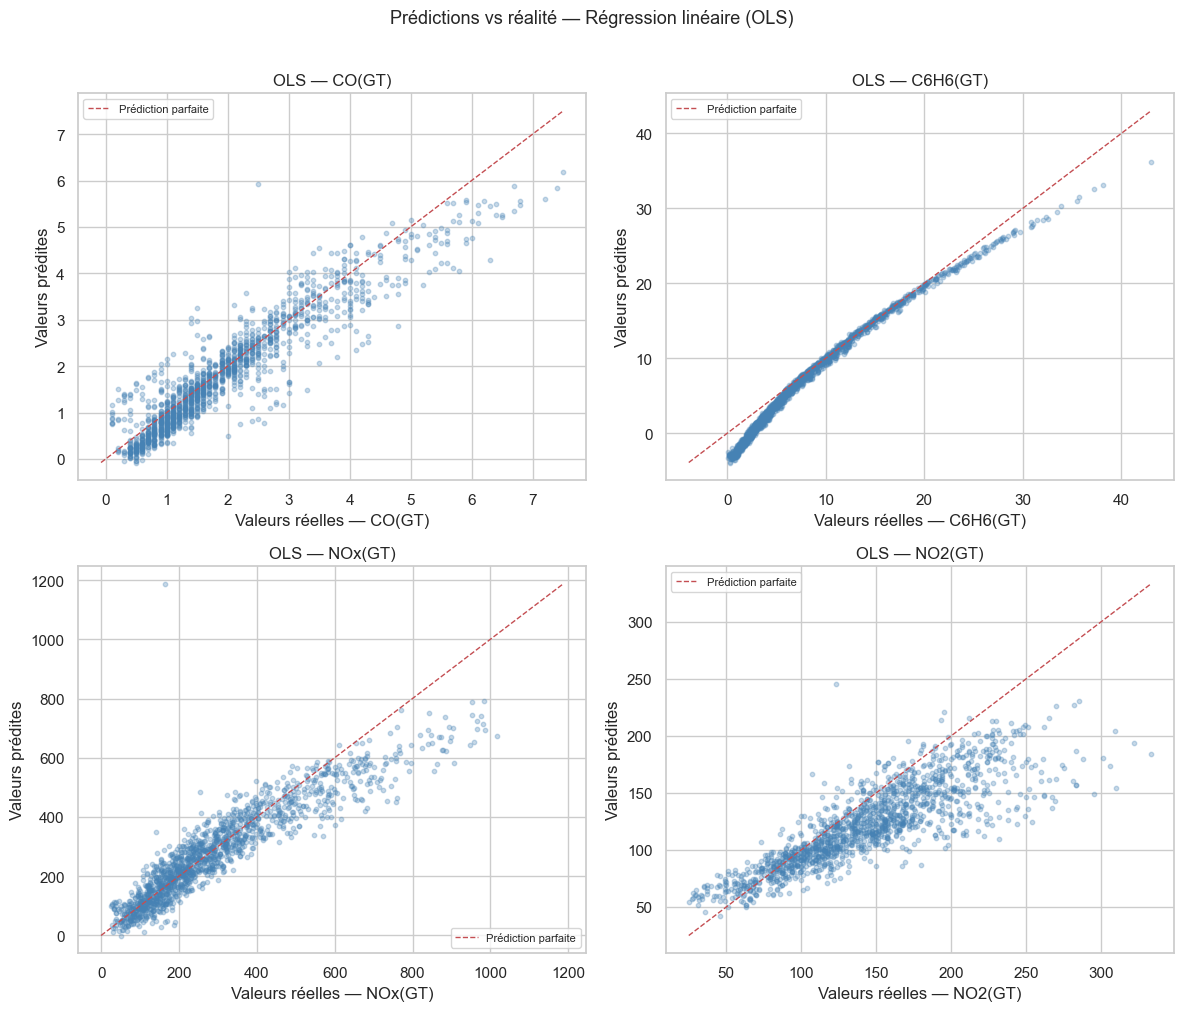

In [20]:
# Scatter prédictions vs réalité — OLS
# Permet de visualiser où le modèle pèche (valeurs extrêmes, biais systématique)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, target in zip(axes.ravel(), TARGETS):
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_train = splits[target]["y_train"]
    y_test  = splits[target]["y_test"]

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LinearRegression())
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color="steelblue")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1, label="Prédiction parfaite")
    ax.set_xlabel(f"Valeurs réelles — {target}")
    ax.set_ylabel("Valeurs prédites")
    ax.set_title(f"OLS — {target}")
    ax.legend(fontsize=8)

plt.suptitle("Prédictions vs réalité — Régression linéaire (OLS)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [21]:
show_results("Régression linéaire (OLS)")

,RMSE,MAE,R²
Cible,,,
CO(GT),0.484,0.344,0.862
C6H6(GT),1.685,1.280,0.933
NOx(GT),76.806,51.896,0.836
NO2(GT),36.133,26.481,0.524


<a id="section-6-2"></a>
---
### 6.2 — Régression Ridge

**Principe :**
La régression Ridge ajoute à la fonction de coût d'OLS une **pénalisation L2** sur le vecteur de coefficients :

$$\min_{\beta} \| y - X\beta \|_2^2 + \alpha \| \beta \|_2^2$$

La solution admet une forme analytique : $\hat{\beta}_{\text{Ridge}} = (X^\top X + \alpha I)^{-1} X^\top y$. Le terme $\alpha I$ régularise la matrice $X^\top X$, ce qui évite les problèmes d'inversibilité liés à la multicolinéarité et contracte les coefficients vers zéro.

**Hyperparamètre clé : `alpha` $\geq 0$**
- `alpha = 0` → Ridge identique à OLS,
- `alpha` grand → $\|\beta\|_2^2$ fortement contraint, modèle plus biaisé mais plus stable.

Plutôt que de fixer `alpha` manuellement, on utilise **`RidgeCV`** qui le sélectionne automatiquement par cross-validation sur le jeu d'entraînement — ce qui évite tout leakage lié à une sélection sur le test.

On présente deux versions : une cross-validation standard (`cv=5`, vue en cours) et une cross-validation temporelle (`TimeSeriesSplit`), plus rigoureuse pour des données horodatées.

#### Version 1 — `RidgeCV` avec cross-validation standard (`cv=5`)

On divise le train en 5 blocs aléatoires. Pour chaque `alpha` candidat, on évalue l'erreur sur chaque bloc tour à tour et on retient l'`alpha` minimisant l'erreur moyenne. C'est l'approche classique vue en cours.

In [22]:
# Grille d'alphas candidates sur échelle logarithmique
alphas_grid = np.logspace(-2, 4, 100)

model_name_v1 = "Ridge CV=5"
print(f"=== {model_name_v1} ===\n")

alphas_selected_v1 = {}

for target in TARGETS:
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_train = splits[target]["y_train"]
    y_test  = splits[target]["y_test"]

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RidgeCV(alphas=alphas_grid, cv=5))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    alpha_chosen = pipe["model"].alpha_
    alphas_selected_v1[target] = alpha_chosen
    print(f"  alpha retenu = {alpha_chosen:.3f}")
    evaluate(model_name_v1, target, y_test, y_pred)

=== Ridge CV=5 ===

  alpha retenu = 0.010
  CO(GT)           RMSE=0.484  MAE=0.344  R²=0.862
  alpha retenu = 0.010
  C6H6(GT)         RMSE=1.685  MAE=1.280  R²=0.933
  alpha retenu = 0.010
  NOx(GT)          RMSE=76.805  MAE=51.896  R²=0.836
  alpha retenu = 24.771
  NO2(GT)          RMSE=36.051  MAE=26.381  R²=0.526


**Pourquoi garder les deux versions ?**
Les résultats montrent des écarts significatifs entre CV=5 et TSS sur certaines cibles (`CO` : alpha 0.01 vs 7.05 ; `NO2` : alpha 24.77 vs 100.00). Ces différences justifient de présenter les deux approches : elles illustrent concrètement le biais introduit par une k-fold standard sur des données temporelles et défendent l'usage de `TimeSeriesSplit` comme méthode plus rigoureuse.

**Limite de cette approche :** la k-fold standard mélange les observations sans tenir compte de l'ordre temporel. Un bloc de validation peut donc contenir des observations *antérieures* à certaines observations d'entraînement — le modèle "voit le futur", ce qui introduit un biais optimiste dans la sélection d'`alpha`.

La solution est d'utiliser une **cross-validation temporelle** (`TimeSeriesSplit`) : chaque fold entraîne sur le passé et valide sur le futur immédiat.

#### Version 2 — `RidgeCV` avec cross-validation temporelle (`TimeSeriesSplit`)

`TimeSeriesSplit` découpe le train en `n_splits` folds successifs en respectant l'ordre chronologique. Pour `n_splits=5` :

```
Fold 1 : Train [0 → 1/6]   Validation [1/6 → 2/6]
Fold 2 : Train [0 → 2/6]   Validation [2/6 → 3/6]
Fold 3 : Train [0 → 3/6]   Validation [3/6 → 4/6]
Fold 4 : Train [0 → 4/6]   Validation [4/6 → 5/6]
Fold 5 : Train [0 → 5/6]   Validation [5/6 → 6/6]
```

À chaque fold, le modèle n'accède jamais à des données futures — la causalité temporelle est respectée.

In [23]:
# TimeSeriesSplit avec 5 folds — respecte l'ordre chronologique
tscv = TimeSeriesSplit(n_splits=5)

model_name_v2 = "Ridge TimeSeriesSplit"
print(f"=== {model_name_v2} ===\n")

alphas_selected_v2 = {}

for target in TARGETS:
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_train = splits[target]["y_train"]
    y_test  = splits[target]["y_test"]

    # Recherche manuelle du meilleur alpha avec TimeSeriesSplit
    # (RidgeCV n'accepte pas directement un objet TimeSeriesSplit dans toutes les versions)
    best_alpha, best_score = None, -np.inf

    for alpha in alphas_grid:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model",  Ridge(alpha=alpha))
        ])
        scores = cross_val_score(pipe, X_train, y_train, cv=tscv, scoring="r2")
        mean_score = scores.mean()
        if mean_score > best_score:
            best_score = mean_score
            best_alpha = alpha

    alphas_selected_v2[target] = best_alpha

    # Entraînement final sur tout le train avec le meilleur alpha
    pipe_best = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  Ridge(alpha=best_alpha))
    ])
    pipe_best.fit(X_train, y_train)
    y_pred = pipe_best.predict(X_test)

    print(f"  alpha retenu = {best_alpha:.3f}  (R² CV moyen = {best_score:.3f})")
    evaluate(model_name_v2, target, y_test, y_pred)

=== Ridge TimeSeriesSplit ===

  alpha retenu = 7.055  (R² CV moyen = 0.853)
  CO(GT)           RMSE=0.484  MAE=0.344  R²=0.862
  alpha retenu = 8.111  (R² CV moyen = 0.955)
  C6H6(GT)         RMSE=1.670  MAE=1.260  R²=0.934
  alpha retenu = 0.010  (R² CV moyen = 0.636)
  NOx(GT)          RMSE=76.805  MAE=51.896  R²=0.836
  alpha retenu = 100.000  (R² CV moyen = 0.673)
  NO2(GT)          RMSE=35.954  MAE=26.251  R²=0.529


In [24]:
# Comparaison des alphas retenus par les deux approches
print(f"{'Cible':<15} {'Alpha CV=5':>12} {'Alpha TSS':>12} {'Ecart':>10}")
print("-" * 55)
for target in TARGETS:
    a1 = alphas_selected_v1[target]
    a2 = alphas_selected_v2[target]
    print(f"{target:<15} {a1:>12.3f} {a2:>12.3f} {abs(a1-a2):>10.3f}")

Cible             Alpha CV=5    Alpha TSS      Ecart
-------------------------------------------------------
CO(GT)                 0.010        7.055      7.045
C6H6(GT)               0.010        8.111      8.101
NOx(GT)                0.010        0.010      0.000
NO2(GT)               24.771      100.000     75.229


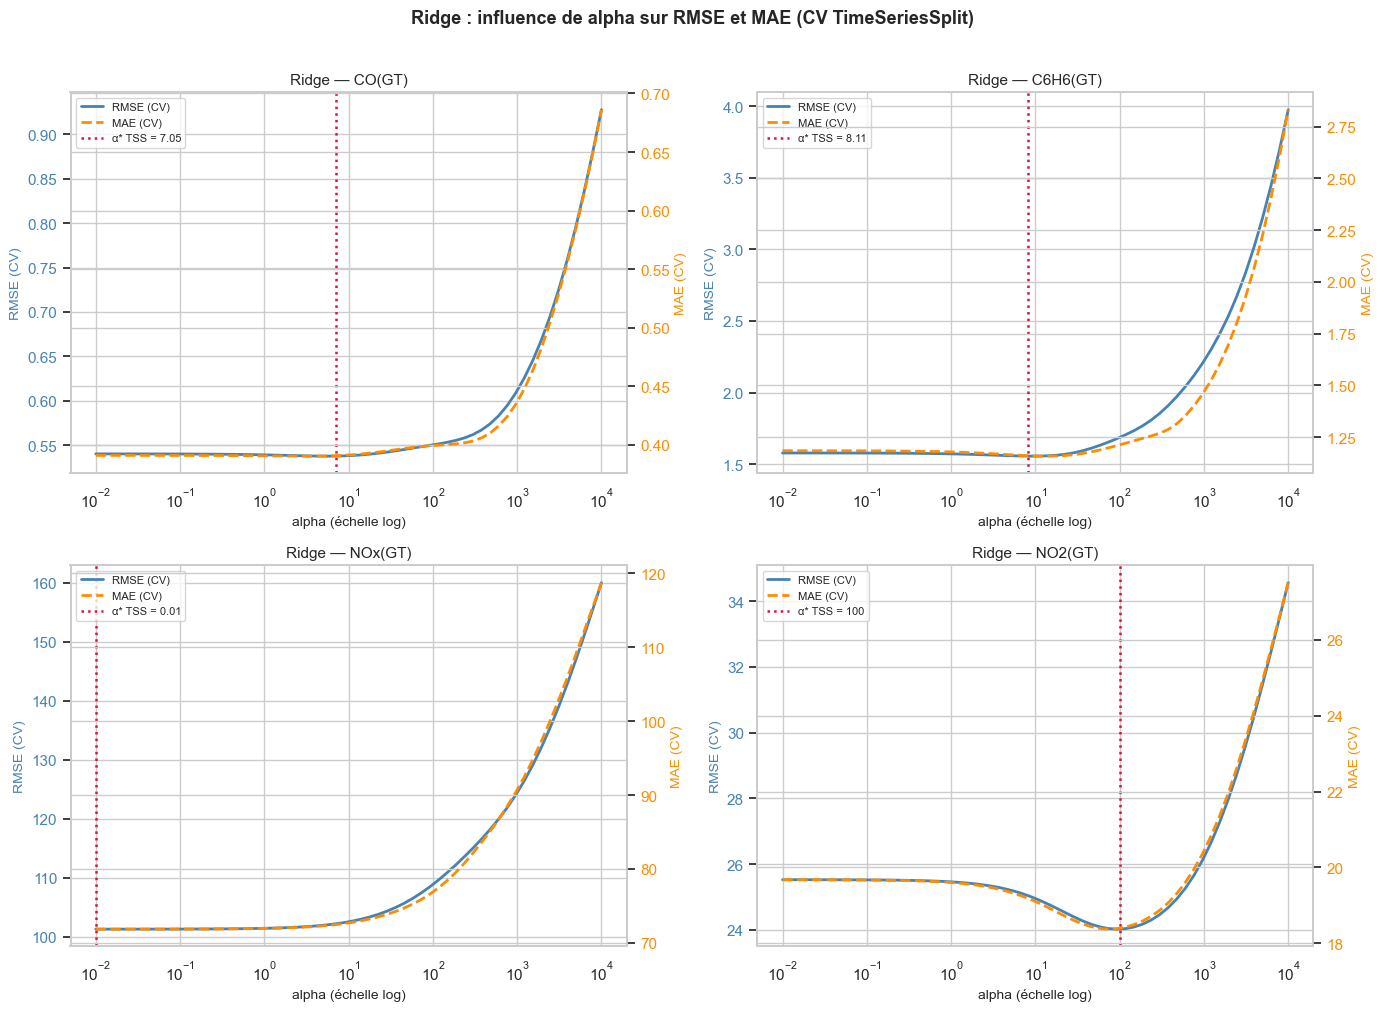

In [25]:
# Sensibilité de Ridge à alpha : courbes RMSE et MAE sur le jeu de test
alphas_ridge_viz = np.logspace(-2, 4, 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, target in zip(axes.ravel(), TARGETS):
    X_train = splits[target]["X_train"]
    y_train = splits[target]["y_train"]

    rmse_values, mae_values = [], []

    for alpha in alphas_ridge_viz:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model",  Ridge(alpha=alpha))
        ])
        rmse, mae = cv_rmse_mae(pipe, X_train, y_train, tscv)
        rmse_values.append(rmse)
        mae_values.append(mae)

    ax2 = ax.twinx()
    line1, = ax.semilogx(alphas_ridge_viz, rmse_values, color="steelblue",
                         linewidth=2, label="RMSE (CV)")
    line2, = ax2.semilogx(alphas_ridge_viz, mae_values, color="darkorange",
                          linewidth=2, linestyle="--", label="MAE (CV)")

    alpha_opt = alphas_selected_v2[target]
    ax.axvline(alpha_opt, color="crimson", linestyle=":", linewidth=1.8,
               label=f"α* TSS = {alpha_opt:.3g}")

    ax.set_xlabel("alpha (échelle log)", fontsize=10)
    ax.set_ylabel("RMSE (CV)", color="steelblue", fontsize=10)
    ax2.set_ylabel("MAE (CV)", color="darkorange", fontsize=10)
    ax.tick_params(axis="y", labelcolor="steelblue")
    ax2.tick_params(axis="y", labelcolor="darkorange")
    ax.set_title(f"Ridge — {target}", fontsize=11)

    lines = [line1, line2,
             plt.Line2D([0], [0], color="crimson", linestyle=":",
                        linewidth=1.8, label=f"α* TSS = {alpha_opt:.3g}")]
    ax.legend(handles=lines, fontsize=8, loc="upper left")

plt.suptitle("Ridge : influence de alpha sur RMSE et MAE (CV TimeSeriesSplit)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

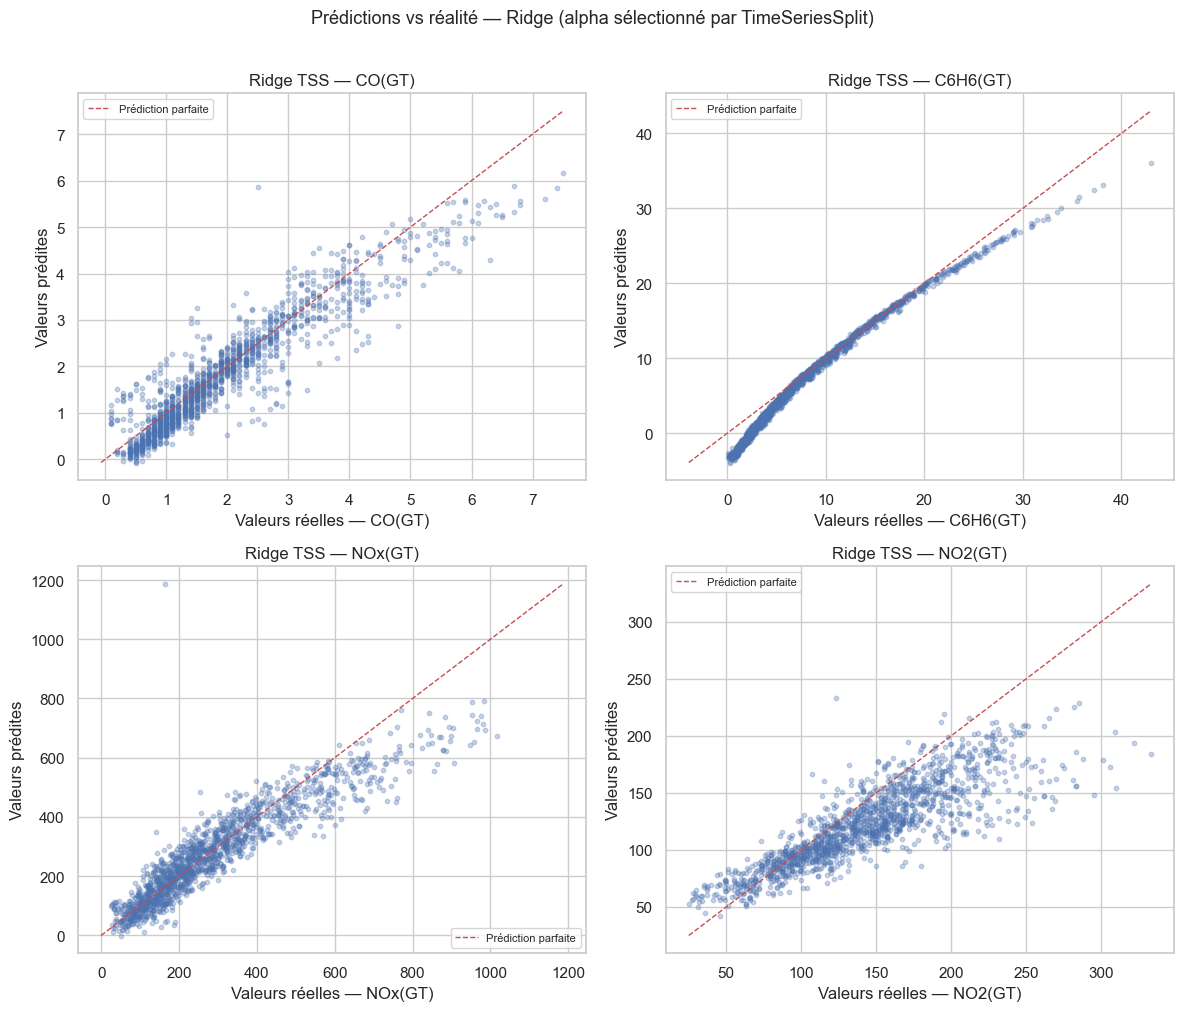

In [26]:
# Comparaison visuelle : prédictions vs valeurs réelles pour Ridge (alpha via TimeSeriesSplit)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, target in zip(axes.ravel(), TARGETS):
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_train = splits[target]["y_train"]
    y_test  = splits[target]["y_test"]

    alpha = alphas_selected_v2[target]
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  Ridge(alpha=alpha))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.3, s=10)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1, label="Prédiction parfaite")
    ax.set_xlabel(f"Valeurs réelles — {target}")
    ax.set_ylabel("Valeurs prédites")
    ax.set_title(f"Ridge TSS — {target}")
    ax.legend(fontsize=8)

plt.suptitle("Prédictions vs réalité — Ridge (alpha sélectionné par TimeSeriesSplit)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [27]:
show_results("Ridge TimeSeriesSplit")

,RMSE,MAE,R²
Cible,,,
CO(GT),0.484,0.344,0.862
C6H6(GT),1.670,1.260,0.934
NOx(GT),76.805,51.896,0.836
NO2(GT),35.954,26.251,0.529


**Comparaison des alphas retenus CV=5 vs TimeSeriesSplit :**

| Cible | Alpha CV=5 | Alpha TSS | Écart |
|---|---:|---:|---:|
| `CO(GT)` | 0.010 | 7.055 | 7.045 |
| `C6H6(GT)` | 0.010 | 8.111 | 8.101 |
| `NOx(GT)` | 0.010 | 0.010 | 0.000 |
| `NO2(GT)` | 24.771 | 100.000 | 75.229 |

Les écarts sont significatifs pour trois cibles sur quatre. La validation croisée standard `cv=5` retient des alphas très faibles (≈ OLS non régularisé), tandis que `TimeSeriesSplit` recommande une régularisation bien plus forte — ce qui valide le choix de TSS comme méthode de référence.

**Performances Ridge TSS :**

| Cible | RMSE | MAE | R² | vs OLS |
|---|---|---|---|---|
| `CO(GT)` | 0.484 | 0.344 | 0.862 | = |
| `C6H6(GT)` | 1.670 | 1.260 | 0.934 | +0.001 |
| `NOx(GT)` | 76.805 | 51.896 | 0.836 | = |
| `NO2(GT)` | 35.954 | 26.251 | 0.529 | +0.005 |

Les gains sont modestes mais cohérents : Ridge améliore `C6H6` et `NO2`, là où la multicolinéarité était la plus pénalisante pour OLS.

**Lecture des courbes alpha vs RMSE/MAE :**
- `CO(GT)` et `NOx(GT)` : les courbes sont quasiment plates pour les petites valeurs d'alpha — Ridge n'apporte rien pour ces cibles tant qu'alpha reste faible. La dégradation n'intervient que pour alpha > 10² (forte sur-régularisation).
- `C6H6(GT)` : un minimum net apparaît autour d'alpha ≈ 8–10. La régularisation est bénéfique ici — l'alpha TSS de 8.11 est bien positionné dans ce creux.
- `NO2(GT)` : le creux est plus large, centré autour d'alpha ≈ 100. L'alpha TSS de 100 est parfaitement aligné sur cet optimum.

<a id="section-6-3"></a>
---
### 6.3 — Régression Lasso

**Principe :**
La régression Lasso (*Least Absolute Shrinkage and Selection Operator*) ajoute une **pénalisation L1** sur le vecteur de coefficients :

$$\min_{\beta} \| y - X\beta \|_2^2 + \alpha \| \beta \|_1$$

Contrairement à Ridge (pénalisation L2), la norme L1 $\|\beta\|_1 = \sum_j |\beta_j|$ produit des solutions **parcimonieuses** : pour un alpha suffisamment grand, certains coefficients sont forcés exactement à **zéro**. Lasso réalise ainsi simultanément régularisation et **sélection de variables**.

Géométriquement, la contrainte L1 définit un polytope (losange en 2D) dont les sommets sont sur les axes — la solution optimale tombe souvent exactement sur un sommet, annulant certains coefficients. C'est la différence fondamentale avec Ridge dont la contrainte L2 (sphère) ne produit jamais de zéros exacts.

**Hyperparamètre clé : `alpha` $\geq 0$**
- `alpha = 0` → Lasso identique à OLS,
- `alpha` grand → de plus en plus de coefficients mis à zéro, jusqu'au modèle constant.

Comme pour Ridge, on utilise `LassoCV` avec `TimeSeriesSplit` pour sélectionner `alpha` de façon rigoureuse, puis `cv=5` comme comparaison.

Pour Lasso, on retient directement la **cross-validation temporelle (`TimeSeriesSplit`)**, sans présenter la version CV=5. En effet, les résultats Ridge ont clairement montré que la k-fold standard sous-estime le niveau de régularisation nécessaire sur des données temporelles. La comparaison ayant déjà été illustrée et défendue pour Ridge, la répéter pour Lasso n'apporterait pas d'information supplémentaire.

In [28]:
# Grille d'alphas pour Lasso — plus sensible aux petits alphas que Ridge
alphas_lasso_grid = np.logspace(-4, 1, 100)

# TimeSeriesSplit (déjà défini en section Ridge, redéfini ici par sécurité)
if 'tscv' not in dir():
    tscv = TimeSeriesSplit(n_splits=5)

#### Sélection d'alpha par `TimeSeriesSplit`

On recherche l'alpha optimal en respectant la causalité temporelle : pour chaque valeur candidate de la grille, on évalue le R² par `TimeSeriesSplit` sur le train, puis on retient la valeur maximisant ce score.

In [29]:
model_name_lasso_v2 = "Lasso TimeSeriesSplit"
print(f"=== {model_name_lasso_v2} ===\n")

alphas_lasso_v2 = {}

for target in TARGETS:
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_train = splits[target]["y_train"]
    y_test  = splits[target]["y_test"]

    best_alpha, best_score = None, -np.inf

    for alpha in alphas_lasso_grid:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model",  Lasso(alpha=alpha, max_iter=10000))
        ])
        scores = cross_val_score(pipe, X_train, y_train, cv=tscv, scoring="r2")
        mean_score = scores.mean()
        if mean_score > best_score:
            best_score = mean_score
            best_alpha = alpha

    alphas_lasso_v2[target] = best_alpha

    # Entraînement final sur tout le train avec le meilleur alpha
    pipe_best = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  Lasso(alpha=best_alpha, max_iter=10000))
    ])
    pipe_best.fit(X_train, y_train)
    y_pred = pipe_best.predict(X_test)

    n_zero = np.sum(pipe_best["model"].coef_ == 0)
    n_total = len(pipe_best["model"].coef_)
    print(f"  alpha retenu = {best_alpha:.4f}  (R² CV moyen = {best_score:.3f})")
    print(f"  coefficients nuls : {n_zero}/{n_total}")
    evaluate(model_name_lasso_v2, target, y_test, y_pred)

=== Lasso TimeSeriesSplit ===

  alpha retenu = 0.0335  (R² CV moyen = 0.869)
  coefficients nuls : 4/8
  CO(GT)           RMSE=0.492  MAE=0.348  R²=0.857
  alpha retenu = 0.1072  (R² CV moyen = 0.969)
  coefficients nuls : 2/8
  C6H6(GT)         RMSE=1.440  MAE=1.015  R²=0.951
  alpha retenu = 0.1918  (R² CV moyen = 0.637)
  coefficients nuls : 0/8
  NOx(GT)          RMSE=76.700  MAE=51.966  R²=0.836
  alpha retenu = 0.1918  (R² CV moyen = 0.652)
  coefficients nuls : 0/8
  NO2(GT)          RMSE=36.387  MAE=26.745  R²=0.517


In [30]:
# Récapitulatif des alphas retenus par TimeSeriesSplit et du nombre de coefficients nuls
print(f"{'Cible':<15} {'Alpha TSS':>12} {'Coefs nuls':>12} {'R² CV moyen':>12}")
print("-" * 55)
for target in TARGETS:
    alpha = alphas_lasso_v2[target]
    # Recalcul du nombre de zéros pour le récapitulatif
    cols_needed = feature_cols + [target]
    df_t = df_model[cols_needed].dropna()
    cutoff = int(len(df_t) * TRAIN_RATIO)
    X_tr = df_t[feature_cols].iloc[:cutoff]
    y_tr = df_t[target].iloc[:cutoff]
    pipe_tmp = Pipeline([("scaler", StandardScaler()),
                         ("model", Lasso(alpha=alpha, max_iter=10000))])
    pipe_tmp.fit(X_tr, y_tr)
    n_zero = np.sum(pipe_tmp["model"].coef_ == 0)
    n_total = len(pipe_tmp["model"].coef_)
    print(f"{target:<15} {alpha:>12.4f} {n_zero:>10}/{n_total} {'':>12}")

Cible              Alpha TSS   Coefs nuls  R² CV moyen
-------------------------------------------------------
CO(GT)                0.0335          4/8             
C6H6(GT)              0.1072          2/8             
NOx(GT)               0.1918          0/8             
NO2(GT)               0.1918          0/8             


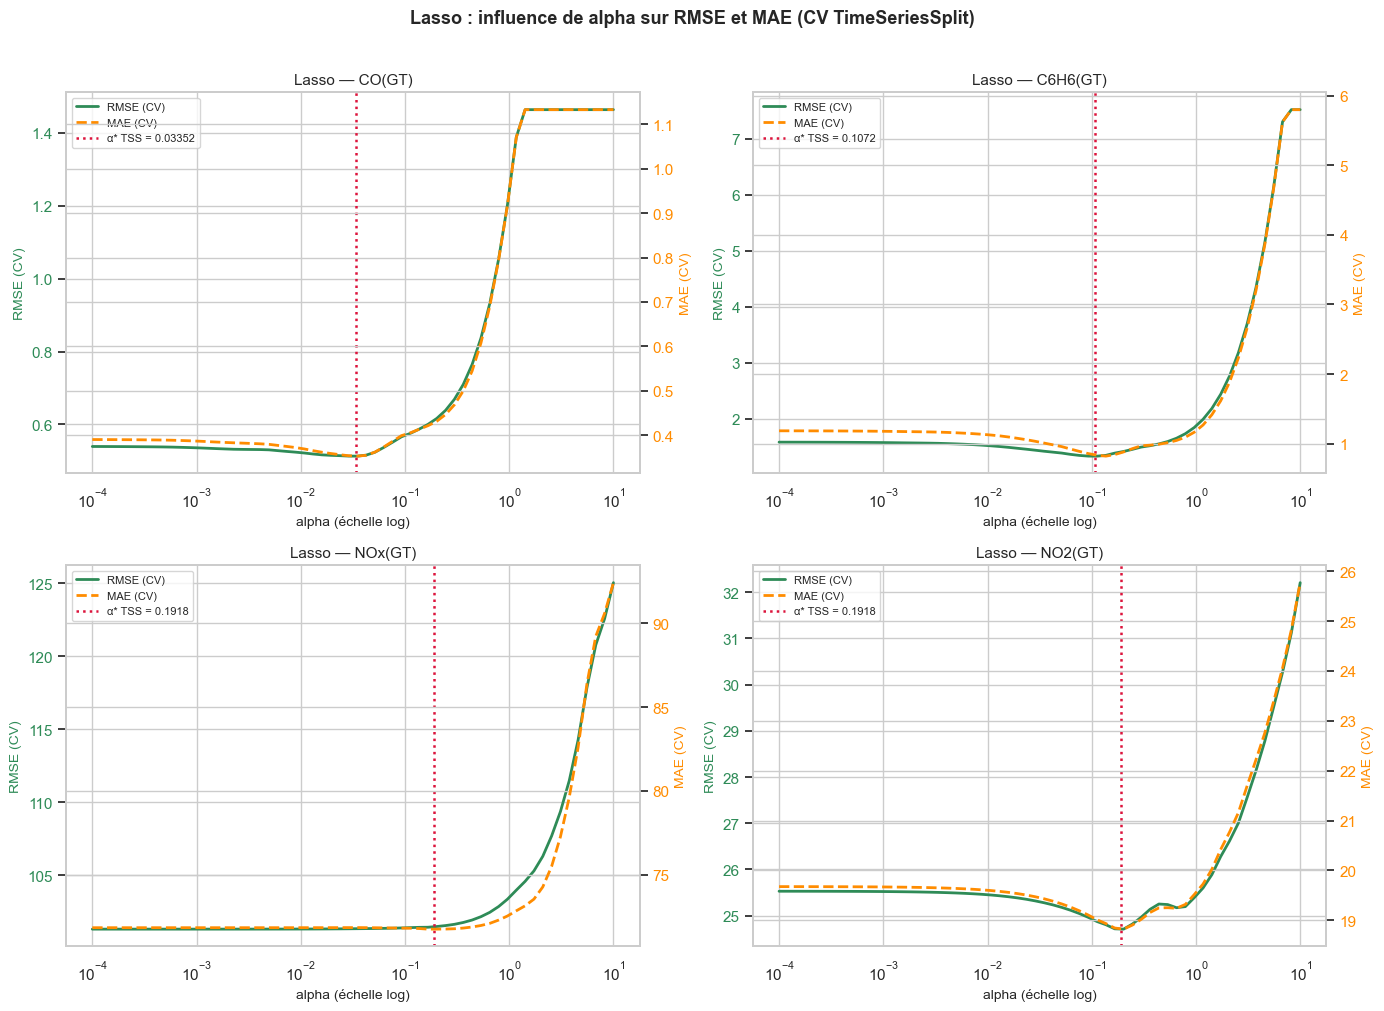

In [31]:
# Sensibilité de Lasso à alpha : courbes RMSE et MAE sur le jeu de test
alphas_lasso_viz = np.logspace(-4, 1, 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, target in zip(axes.ravel(), TARGETS):
    X_train = splits[target]["X_train"]
    y_train = splits[target]["y_train"]

    rmse_values, mae_values = [], []

    for alpha in alphas_lasso_viz:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model",  Lasso(alpha=alpha, max_iter=10000))
        ])
        rmse, mae = cv_rmse_mae(pipe, X_train, y_train, tscv)
        rmse_values.append(rmse)
        mae_values.append(mae)

    ax2 = ax.twinx()
    line1, = ax.semilogx(alphas_lasso_viz, rmse_values, color="seagreen",
                         linewidth=2, label="RMSE (CV)")
    line2, = ax2.semilogx(alphas_lasso_viz, mae_values, color="darkorange",
                          linewidth=2, linestyle="--", label="MAE (CV)")

    alpha_opt = alphas_lasso_v2[target]
    ax.axvline(alpha_opt, color="crimson", linestyle=":", linewidth=1.8,
               label=f"α* TSS = {alpha_opt:.4g}")

    ax.set_xlabel("alpha (échelle log)", fontsize=10)
    ax.set_ylabel("RMSE (CV)", color="seagreen", fontsize=10)
    ax2.set_ylabel("MAE (CV)", color="darkorange", fontsize=10)
    ax.tick_params(axis="y", labelcolor="seagreen")
    ax2.tick_params(axis="y", labelcolor="darkorange")
    ax.set_title(f"Lasso — {target}", fontsize=11)

    lines = [line1, line2,
             plt.Line2D([0], [0], color="crimson", linestyle=":",
                        linewidth=1.8, label=f"α* TSS = {alpha_opt:.4g}")]
    ax.legend(handles=lines, fontsize=8, loc="upper left")

plt.suptitle("Lasso : influence de alpha sur RMSE et MAE (CV TimeSeriesSplit)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

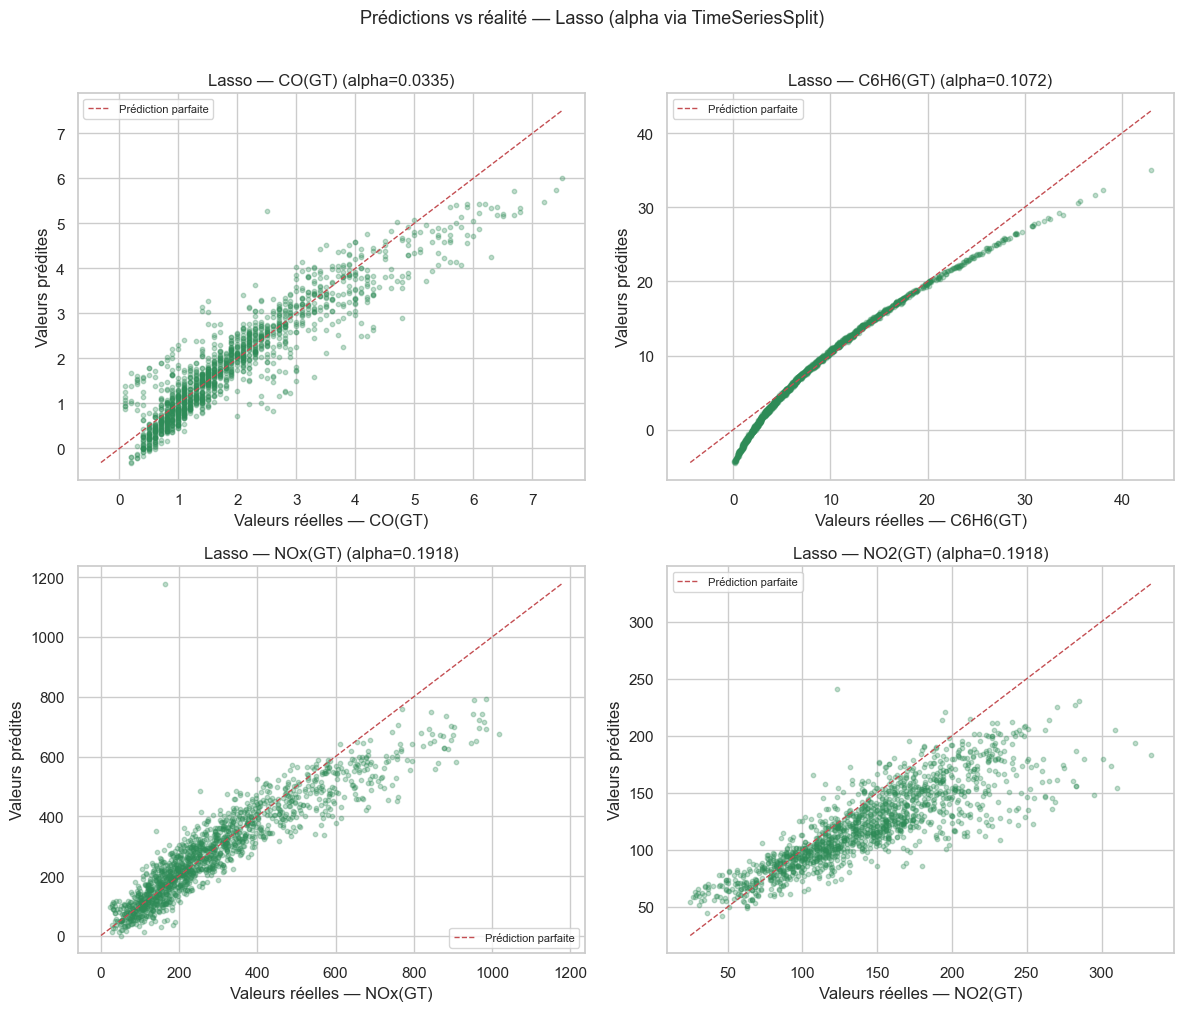

In [32]:
# Scatter prédictions vs réalité — Lasso (alpha via TimeSeriesSplit)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, target in zip(axes.ravel(), TARGETS):
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_train = splits[target]["y_train"]
    y_test  = splits[target]["y_test"]

    alpha = alphas_lasso_v2[target]
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  Lasso(alpha=alpha, max_iter=10000))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color="seagreen")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1, label="Prédiction parfaite")
    ax.set_xlabel(f"Valeurs réelles — {target}")
    ax.set_ylabel("Valeurs prédites")
    ax.set_title(f"Lasso — {target} (alpha={alpha:.4f})")
    ax.legend(fontsize=8)

plt.suptitle("Prédictions vs réalité — Lasso (alpha via TimeSeriesSplit)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Alphas retenus et sélection de variables (Lasso TSS) :**

| Cible | Alpha TSS | Coefs nuls | R² CV moyen |
|---|---|---|---|
| `CO(GT)` | 0.0335 | 4/8 | 0.869 |
| `C6H6(GT)` | 0.1072 | 2/8 | 0.969 |
| `NOx(GT)` | 0.1918 | 0/8 | 0.637 |
| `NO2(GT)` | 0.1918 | 0/8 | 0.652 |

**Sélection de variables :** `CO(GT)` est la cible la plus parcimonieuse — 4 features sur 8 sont annulées, ce qui indique que la moitié des prédicteurs est redondante pour cette cible. `C6H6(GT)` élimine 2 features. En revanche, `NOx(GT)` et `NO2(GT)` retiennent les 8 features, signe que toutes contribuent marginalement et qu'aucune n'est clairement superflue.

**Performances finales (Lasso TSS) :**

| Cible | RMSE | MAE | R² |
|---|---|---|---|
| `CO(GT)` | 0.492 | 0.348 | 0.857 |
| `C6H6(GT)` | 1.440 | 1.015 | 0.951 |
| `NOx(GT)` | 76.700 | 51.966 | 0.836 |
| `NO2(GT)` | 36.387 | 26.745 | 0.517 |

**Lecture des courbes alpha vs RMSE/MAE (image Lasso) :**
- `CO(GT)` : un minimum net est visible autour d'alpha ≈ 0.03–0.05 — l'alpha TSS de 0.0335 est bien positionné dans ce creux. Au-delà d'alpha ≈ 0.1, les erreurs explosent brutalement (modèle trop contraint).
- `C6H6(GT)` : le creux est plus plat, centré autour d'alpha ≈ 0.1. L'alpha TSS de 0.1072 est aligné sur cet optimum.
- `NOx(GT)` et `NO2(GT)` partagent le même alpha TSS (0.1918), ce qui reflète la similarité de leur comportement face à la régularisation L1. Leurs courbes montrent un plateau stable pour alpha < 0.1, puis une dégradation progressive.

**Scatters prédictions vs réalité :** les nuages confirment les métriques. `C6H6(GT)` est très bien capturé (points serrés autour de la diagonale, légère courbure pour les grandes valeurs). `CO(GT)` présente une dispersion modérée aux valeurs élevées. `NOx(GT)` et `NO2(GT)` sont plus diffus, avec une tendance à sous-estimer les pics — cohérent avec l'asymétrie droite de leurs distributions.

**Comparaison avec OLS et Ridge :** Lasso améliore légèrement `C6H6(GT)` (0.951 vs 0.933 OLS) grâce à l'élimination de features redondantes. Sur `CO(GT)`, la parcimonisation coûte quelques points de R² (0.857 vs 0.862). Sur `NOx` et `NO2`, les performances restent proches des méthodes linéaires précédentes.

In [33]:
show_results("Lasso TimeSeriesSplit")

,RMSE,MAE,R²
Cible,,,
CO(GT),0.492,0.348,0.857
C6H6(GT),1.440,1.015,0.951
NOx(GT),76.700,51.966,0.836
NO2(GT),36.387,26.745,0.517


<a id="section-6-4"></a>
---
### 6.4 — Elastic Net

**Principe :**
L'Elastic Net combine les pénalisations L1 (Lasso) et L2 (Ridge) dans une seule fonction de coût :

$$\min_{\beta} \| y - X\beta \|_2^2 + \alpha \left[ \rho \| \beta \|_1 + \frac{1-\rho}{2} \| \beta \|_2^2 \right]$$

- **`alpha`** contrôle l'intensité globale de la régularisation,
- **`l1_ratio`** ($\rho \in [0, 1]$) pondère entre L1 et L2 :
  - $\rho = 1$ → Lasso pur (sélection de variables),
  - $\rho = 0$ → Ridge pur (contraction sans sélection),
  - $0 < \rho < 1$ → compromis : contraction + sélection partielle.

**Intérêt sur notre dataset :** les capteurs `PT08.Sx` sont très corrélés entre eux. Lasso tend à sélectionner un capteur arbitrairement et ignorer les autres. Elastic Net répartit le poids entre features corrélées (grâce à L2) tout en éliminant les features réellement non informatives (grâce à L1). C'est la méthode la plus appropriée en présence de multicolinéarité couplée à de la parcimonie souhaitée.

On utilise `TimeSeriesSplit` pour la sélection conjointe de `alpha` et `l1_ratio`.

In [34]:
# Grille conjointe alpha × l1_ratio
alphas_en    = np.logspace(-4, 1, 20)
l1_ratios_en = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

model_name_en = "Elastic Net"
print(f"=== {model_name_en} ===\n")

en_best_params = {}

for target in TARGETS:
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_train = splits[target]["y_train"]
    y_test  = splits[target]["y_test"]

    best_score, best_alpha, best_l1 = -np.inf, None, None

    for alpha in alphas_en:
        for l1_ratio in l1_ratios_en:
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("model",  ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
                                      max_iter=10000))
            ])
            scores = cross_val_score(pipe, X_train, y_train,
                                     cv=tscv, scoring="r2")
            if scores.mean() > best_score:
                best_score = scores.mean()
                best_alpha = alpha
                best_l1    = l1_ratio

    en_best_params[target] = {"alpha": best_alpha, "l1_ratio": best_l1}

    pipe_best = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  ElasticNet(alpha=best_alpha, l1_ratio=best_l1, max_iter=10000))
    ])
    pipe_best.fit(X_train, y_train)
    y_pred = pipe_best.predict(X_test)

    n_zero = np.sum(pipe_best["model"].coef_ == 0)
    n_total = len(pipe_best["model"].coef_)
    print(f"  alpha={best_alpha:.4f}  l1_ratio={best_l1}  "
          f"coefs nuls={n_zero}/{n_total}  (R² CV={best_score:.3f})")
    evaluate(model_name_en, target, y_test, y_pred)

=== Elastic Net ===

  alpha=0.0234  l1_ratio=1.0  coefs nuls=3/8  (R² CV=0.868)
  CO(GT)           RMSE=0.488  MAE=0.347  R²=0.859
  alpha=0.0785  l1_ratio=1.0  coefs nuls=2/8  (R² CV=0.968)
  C6H6(GT)         RMSE=1.496  MAE=1.056  R²=0.947
  alpha=0.2637  l1_ratio=1.0  coefs nuls=0/8  (R² CV=0.636)
  NOx(GT)          RMSE=76.671  MAE=52.005  R²=0.837
  alpha=0.0428  l1_ratio=0.3  coefs nuls=0/8  (R² CV=0.664)
  NO2(GT)          RMSE=36.010  MAE=26.291  R²=0.527


In [35]:
# Tableau récapitulatif — hyperparamètres et sélection de variables
print(f"{'Cible':<15} {'Alpha':>10} {'l1_ratio':>10} {'Coefs nuls':>12}")
print("-" * 52)
for target in TARGETS:
    p = en_best_params[target]
    # Recalcul coefs nuls
    cols_needed = feature_cols + [target]
    df_t  = df_model[cols_needed].dropna()
    cutoff = int(len(df_t) * TRAIN_RATIO)
    X_tr  = df_t[feature_cols].iloc[:cutoff]
    y_tr  = df_t[target].iloc[:cutoff]
    pipe_tmp = Pipeline([("scaler", StandardScaler()),
                          ("model", ElasticNet(alpha=p["alpha"],
                                               l1_ratio=p["l1_ratio"],
                                               max_iter=10000))])
    pipe_tmp.fit(X_tr, y_tr)
    n_zero = np.sum(pipe_tmp["model"].coef_ == 0)
    n_total = len(pipe_tmp["model"].coef_)
    print(f"{target:<15} {p['alpha']:>10.4f} {p['l1_ratio']:>10.2f} {n_zero:>10}/{n_total}")

Cible                Alpha   l1_ratio   Coefs nuls
----------------------------------------------------
CO(GT)              0.0234       1.00          3/8
C6H6(GT)            0.0785       1.00          2/8
NOx(GT)             0.2637       1.00          0/8
NO2(GT)             0.0428       0.30          0/8


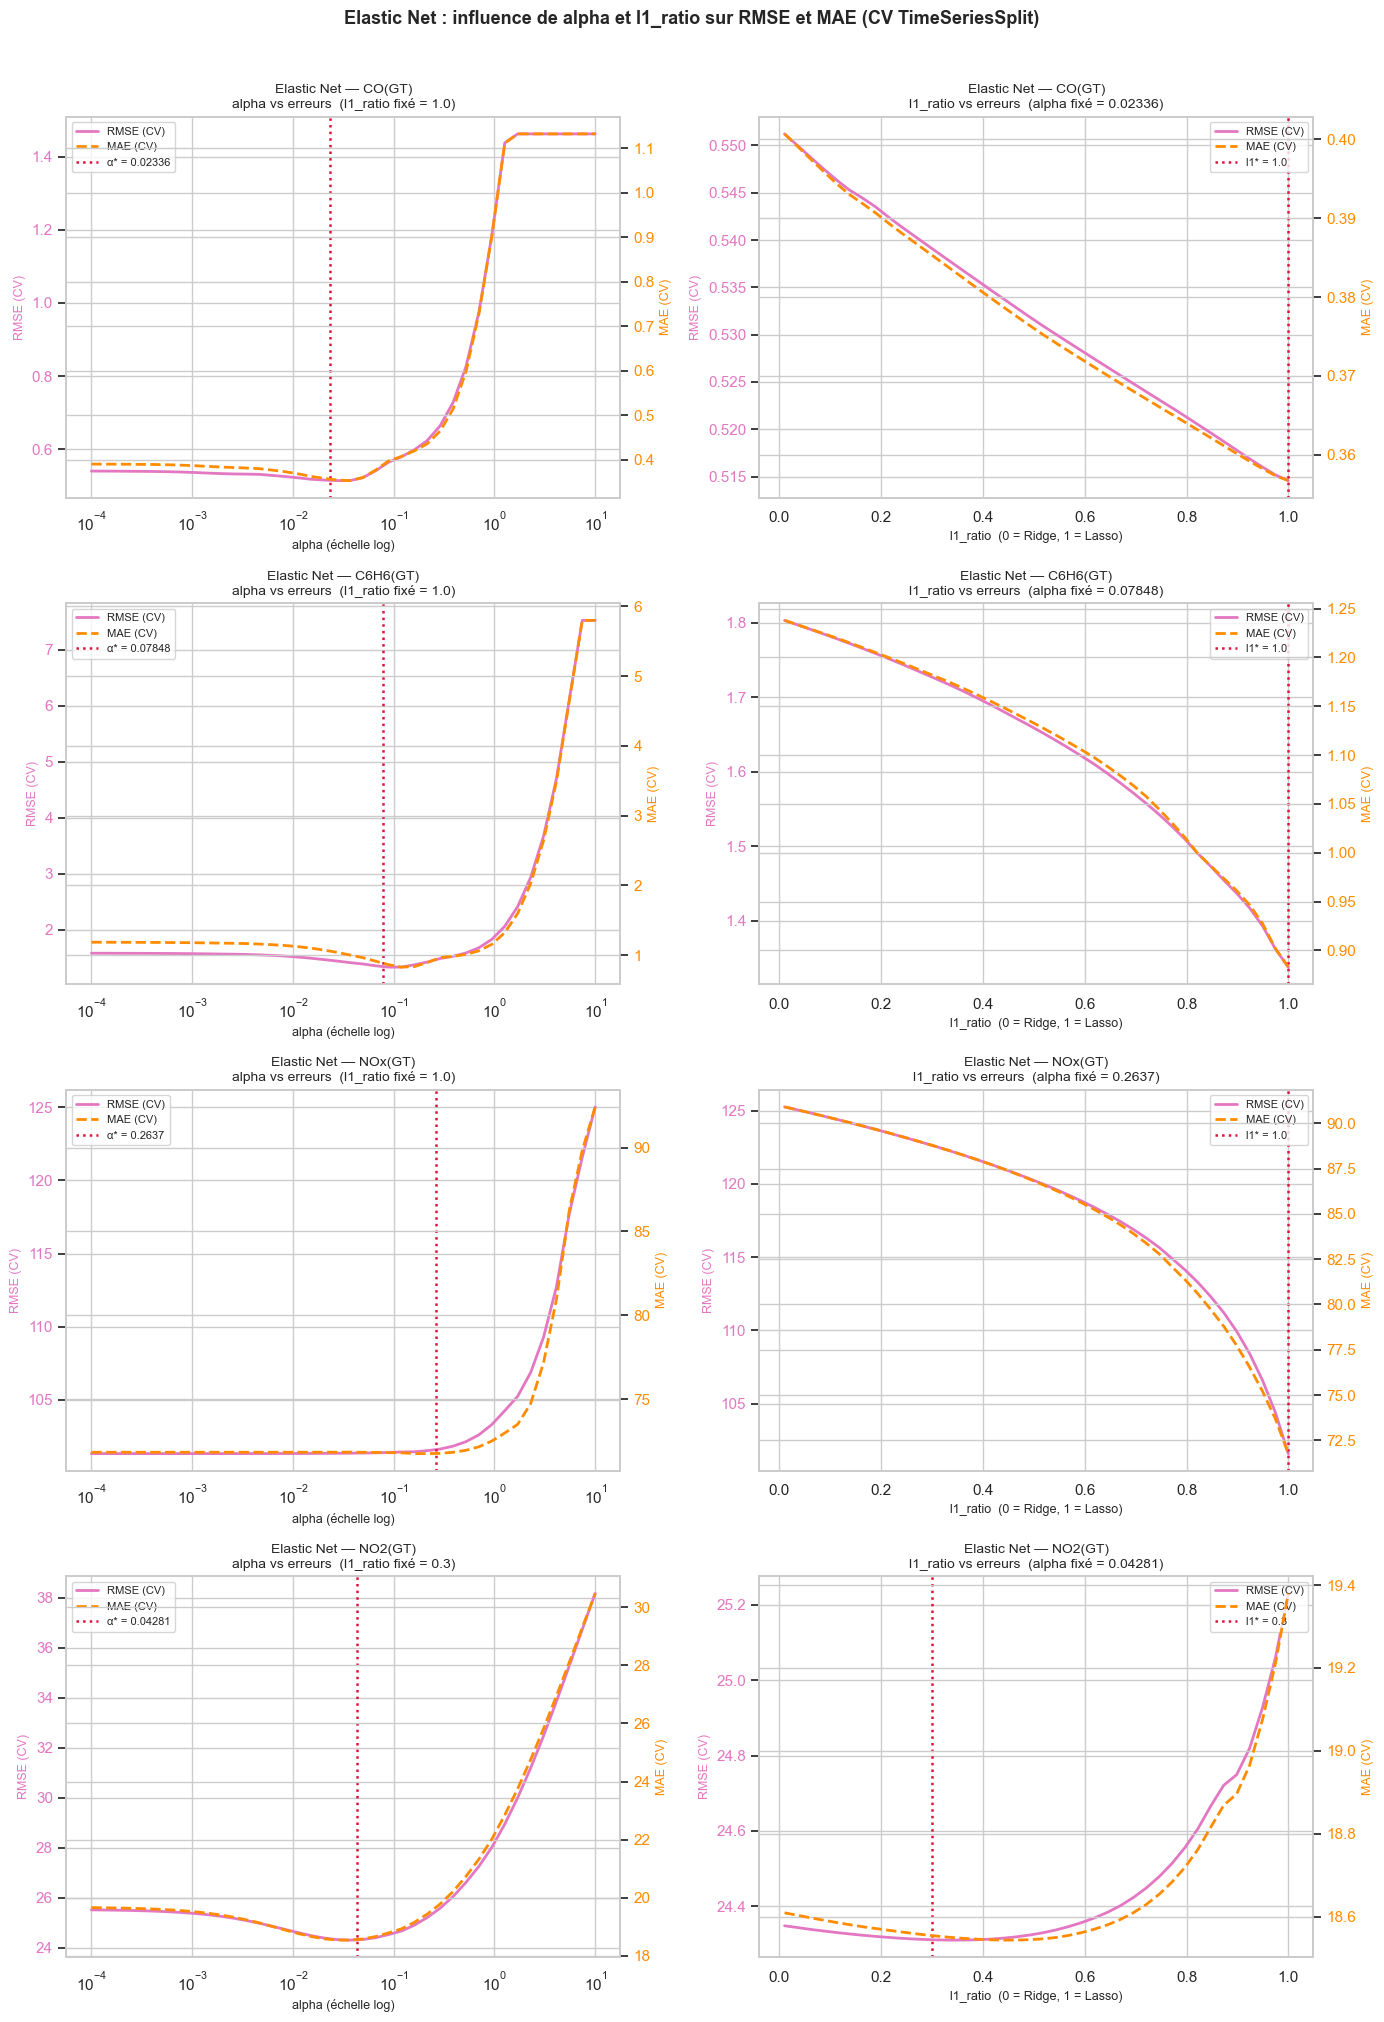

In [36]:
# Courbes RMSE et MAE sur le jeu de test pour chaque cible
alphas_en_viz    = np.logspace(-4, 1, 40)
l1_ratios_en_viz = np.linspace(0.01, 1.0, 40)

fig, axes = plt.subplots(4, 2, figsize=(14, 20))

for row, target in enumerate(TARGETS):
    X_train = splits[target]["X_train"]
    y_train = splits[target]["y_train"]

    best_alpha_en = en_best_params[target]["alpha"]
    best_l1_en    = en_best_params[target]["l1_ratio"]

    # ── Graphique 1 : alpha vs RMSE/MAE (l1_ratio fixé à l'optimal) ──
    rmse_a, mae_a = [], []
    for alpha in alphas_en_viz:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model",  ElasticNet(alpha=alpha, l1_ratio=best_l1_en, max_iter=10000))
        ])
        rmse, mae = cv_rmse_mae(pipe, X_train, y_train, tscv)
        rmse_a.append(rmse)
        mae_a.append(mae)

    ax = axes[row, 0]
    ax2 = ax.twinx()
    l1, = ax.semilogx(alphas_en_viz, rmse_a, color="#e377c2", linewidth=2, label="RMSE (CV)")
    l2, = ax2.semilogx(alphas_en_viz, mae_a, color="darkorange",
                       linewidth=2, linestyle="--", label="MAE (CV)")
    ax.axvline(best_alpha_en, color="crimson", linestyle=":", linewidth=1.8,
               label=f"α* = {best_alpha_en:.4g}")
    ax.set_xlabel("alpha (échelle log)", fontsize=9)
    ax.set_ylabel("RMSE (CV)", color="#e377c2", fontsize=9)
    ax2.set_ylabel("MAE (CV)", color="darkorange", fontsize=9)
    ax.tick_params(axis="y", labelcolor="#e377c2")
    ax2.tick_params(axis="y", labelcolor="darkorange")
    ax.set_title(f"Elastic Net — {target}\nalpha vs erreurs  (l1_ratio fixé = {best_l1_en})",
                 fontsize=10)
    lines = [l1, l2, plt.Line2D([0], [0], color="crimson", linestyle=":",
                                 linewidth=1.8, label=f"α* = {best_alpha_en:.4g}")]
    ax.legend(handles=lines, fontsize=8, loc="upper left")

    # ── Graphique 2 : l1_ratio vs RMSE/MAE (alpha fixé à l'optimal) ──
    rmse_l, mae_l = [], []
    for l1r in l1_ratios_en_viz:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model",  ElasticNet(alpha=best_alpha_en, l1_ratio=l1r, max_iter=10000))
        ])
        rmse, mae = cv_rmse_mae(pipe, X_train, y_train, tscv)
        rmse_l.append(rmse)
        mae_l.append(mae)

    ax = axes[row, 1]
    ax2 = ax.twinx()
    l1, = ax.plot(l1_ratios_en_viz, rmse_l, color="#e377c2", linewidth=2, label="RMSE (CV)")
    l2, = ax2.plot(l1_ratios_en_viz, mae_l, color="darkorange",
                   linewidth=2, linestyle="--", label="MAE (CV)")
    ax.axvline(best_l1_en, color="crimson", linestyle=":", linewidth=1.8,
               label=f"l1* = {best_l1_en}")
    ax.set_xlabel("l1_ratio  (0 = Ridge, 1 = Lasso)", fontsize=9)
    ax.set_ylabel("RMSE (CV)", color="#e377c2", fontsize=9)
    ax2.set_ylabel("MAE (CV)", color="darkorange", fontsize=9)
    ax.tick_params(axis="y", labelcolor="#e377c2")
    ax2.tick_params(axis="y", labelcolor="darkorange")
    ax.set_title(f"Elastic Net — {target}\nl1_ratio vs erreurs  (alpha fixé = {best_alpha_en:.4g})",
                 fontsize=10)
    lines = [l1, l2, plt.Line2D([0], [0], color="crimson", linestyle=":",
                                 linewidth=1.8, label=f"l1* = {best_l1_en}")]
    ax.legend(handles=lines, fontsize=8, loc="upper right")

plt.suptitle("Elastic Net : influence de alpha et l1_ratio sur RMSE et MAE (CV TimeSeriesSplit)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

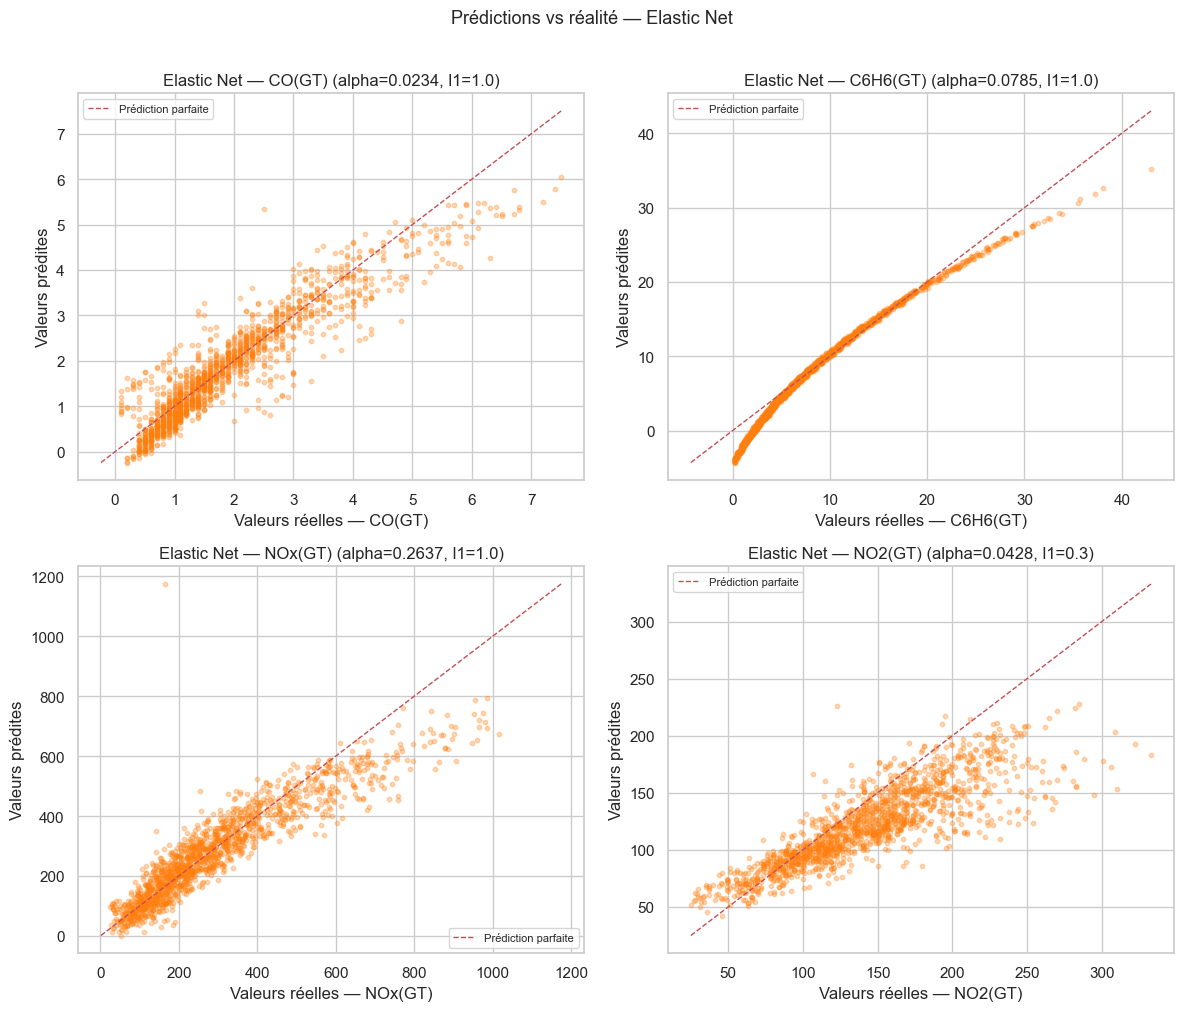

In [37]:
# Scatter prédictions vs réalité — Elastic Net
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, target in zip(axes.ravel(), TARGETS):
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_train = splits[target]["y_train"]
    y_test  = splits[target]["y_test"]
    p = en_best_params[target]

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  ElasticNet(alpha=p["alpha"], l1_ratio=p["l1_ratio"], max_iter=10000))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color="#ff7f0e")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1, label="Prédiction parfaite")
    ax.set_xlabel(f"Valeurs réelles — {target}")
    ax.set_ylabel("Valeurs prédites")
    ax.set_title(f"Elastic Net — {target} (alpha={p['alpha']:.4f}, l1={p['l1_ratio']})")
    ax.legend(fontsize=8)

plt.suptitle("Prédictions vs réalité — Elastic Net", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Alphas retenus et sélection de variables (Elastic Net TSS) :**

| Cible | Alpha | l1_ratio | Coefs nuls | Interprétation |
|---|---|---|---|---|
| `CO(GT)` | 0.0234 | 1.00 | 3/8 | l1_ratio=1 → Lasso pur, 3 features éliminées |
| `C6H6(GT)` | 0.0785 | 1.00 | 2/8 | l1_ratio=1 → Lasso pur, 2 features éliminées |
| `NOx(GT)` | 0.2637 | 1.00 | 0/8 | Lasso pur mais aucune feature nulle |
| `NO2(GT)` | 0.0428 | 0.30 | 0/8 | l1_ratio=0.3 → mélange Ridge/Lasso |

**Interprétation des hyperparamètres :** Pour `CO`, `C6H6` et `NOx`, le l1_ratio optimal est 1.0 — Elastic Net converge vers Lasso pur, confirmant que la sélection de variables domine sur la stabilisation Ridge pour ces cibles. Pour `NO2`, le l1_ratio de 0.3 indique que la composante Ridge est nécessaire pour stabiliser les coefficients face à la multicolinéarité.

**Lecture des courbes (alpha et l1_ratio) :** Les graphiques gauches (alpha vs erreur, l1_ratio fixé à la valeur optimale) montrent les mêmes profils que Lasso : un creux bien marqué pour `CO` et `C6H6`, un plateau stable pour `NOx`. Les graphiques droits (l1_ratio vs erreur, alpha fixé) sont particulièrement instructifs pour `NO2` : l'erreur décroît nettement quand le l1_ratio diminue de 1 vers 0.3, confirmant que la composante Ridge apporte une stabilisation réelle sur cette cible. Pour les trois autres cibles, la courbe est quasiment plate ou légèrement décroissante vers l1_ratio=1 — Ridge n'apporte rien.

**Performances finales (Elastic Net) :**

| Cible | RMSE | MAE | R² |
|---|---|---|---|
| `CO(GT)` | 0.488 | 0.347 | 0.859 |
| `C6H6(GT)` | 1.496 | 1.056 | 0.947 |
| `NOx(GT)` | 76.671 | 52.005 | 0.837 |
| `NO2(GT)` | 36.010 | 26.291 | 0.527 |

**Scatters prédictions vs réalité :** Les nuages sont très similaires à ceux de Lasso, confirmant la convergence vers Lasso pur sur 3 cibles sur 4. `C6H6(GT)` reste la mieux ajustée avec la légère courbure caractéristique aux grandes valeurs. `NO2(GT)` montre une dispersion réduite par rapport à Lasso pur (R² 0.527 vs 0.517), cohérent avec le gain apporté par la composante Ridge.

**Bilan des méthodes linéaires :** OLS, Ridge, Lasso et Elastic Net donnent des performances très proches (R² moyen 0.789–0.793). La valeur ajoutée de chaque méthode est davantage qualitative (stabilité, parcimonie, combinaison des deux) que quantitative.

In [38]:
show_results("Elastic Net")

,RMSE,MAE,R²
Cible,,,
CO(GT),0.488,0.347,0.859
C6H6(GT),1.496,1.056,0.947
NOx(GT),76.671,52.005,0.837
NO2(GT),36.010,26.291,0.527


<a id="section-6-5"></a>
---
### 6.5 — Méthode à noyau (KernelRidge RBF)

**Principe :**
La régression à noyau étend la régression Ridge au cadre non-linéaire grâce au **kernel trick** : plutôt que de travailler directement dans l'espace des features $\mathbb{R}^p$, on projette implicitement les données dans un espace de dimension potentiellement infinie via une fonction noyau $k(x, x')$.

La fonction de coût devient :

$$\min_{\alpha} \| y - K\alpha \|_2^2 + \lambda \alpha^\top K \alpha$$

où $K$ est la **matrice de Gram** de taille $n \times n$ avec $K_{ij} = k(x_i, x_j)$, et $\lambda$ joue le rôle du paramètre de régularisation.

On utilise ici le **noyau RBF** (*Radial Basis Function*, aussi appelé noyau gaussien) :

$$k(x, x') = \exp\left(-\gamma \|x - x'\|_2^2\right)$$

Ce noyau mesure la similarité entre deux observations : proche de 1 si $x \approx x'$, proche de 0 si elles sont éloignées. Il permet de capturer des **relations non-linéaires** arbitrairement complexes sans les spécifier explicitement.

**Hyperparamètres clés :**
- **`alpha`** ($\lambda$) — régularisation : contrôle le compromis biais/variance, comme dans Ridge,
- **`gamma`** — largeur du noyau RBF : 
  - `gamma` petit → noyau large, chaque point influence ses voisins lointains → modèle plus lisse (biais élevé),
  - `gamma` grand → noyau étroit, chaque point n'influence que son voisinage immédiat → modèle plus flexible (risque de surapprentissage).

Ces deux hyperparamètres interagissent : on les explore conjointement sur une grille 2D.

In [39]:
# Grille réduite 5×5 — couvre les ordres de grandeur importants sans exploser le temps de calcul.
# Une grille 8×8 avec TimeSeriesSplit (5 folds) = 320 fits par cible, soit ~20 min au total.
# Une grille 5×5 = 125 fits par cible, soit ~2-3 min — bien suffisant pour identifier la zone optimale.
param_grid = {
    "model__alpha": np.logspace(-3, 1, 5),   # [0.001, 0.01, 0.1, 1, 10]
    "model__gamma": np.logspace(-3, 0, 5),   # [0.001, 0.01, 0.1, 1, 10] — on évite les grands gamma (zone rouge)
}

model_name_kr = "KernelRidge RBF"
print(f"=== {model_name_kr} ===\n")

best_params_kr = {}
best_searches_kr = {}

for target in TARGETS:
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_train = splits[target]["y_train"]
    y_test  = splits[target]["y_test"]

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  KernelRidge(kernel="rbf"))
    ])

    # GridSearchCV avec TimeSeriesSplit — n_jobs=-1 pour paralléliser sur tous les cœurs
    search = GridSearchCV(
        pipe,
        param_grid,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train, y_train)

    best_searches_kr[target] = search
    best_params_kr[target] = search.best_params_
    y_pred = search.best_estimator_.predict(X_test)

    alpha_best = search.best_params_["model__alpha"]
    gamma_best = search.best_params_["model__gamma"]
    print(f"  alpha={alpha_best:.4f}  gamma={gamma_best:.4f}  (R² CV={search.best_score_:.3f})")
    evaluate(model_name_kr, target, y_test, y_pred)

=== KernelRidge RBF ===

  alpha=0.0100  gamma=0.0010  (R² CV=-0.469)
  CO(GT)           RMSE=0.451  MAE=0.293  R²=0.880
  alpha=0.0010  gamma=0.0056  (R² CV=-0.146)
  C6H6(GT)         RMSE=0.058  MAE=0.044  R²=1.000
  alpha=0.0010  gamma=0.0010  (R² CV=-92.038)
  NOx(GT)          RMSE=63.831  MAE=42.652  R²=0.887
  alpha=0.0100  gamma=0.0010  (R² CV=-23.374)
  NO2(GT)          RMSE=33.508  MAE=25.213  R²=0.591


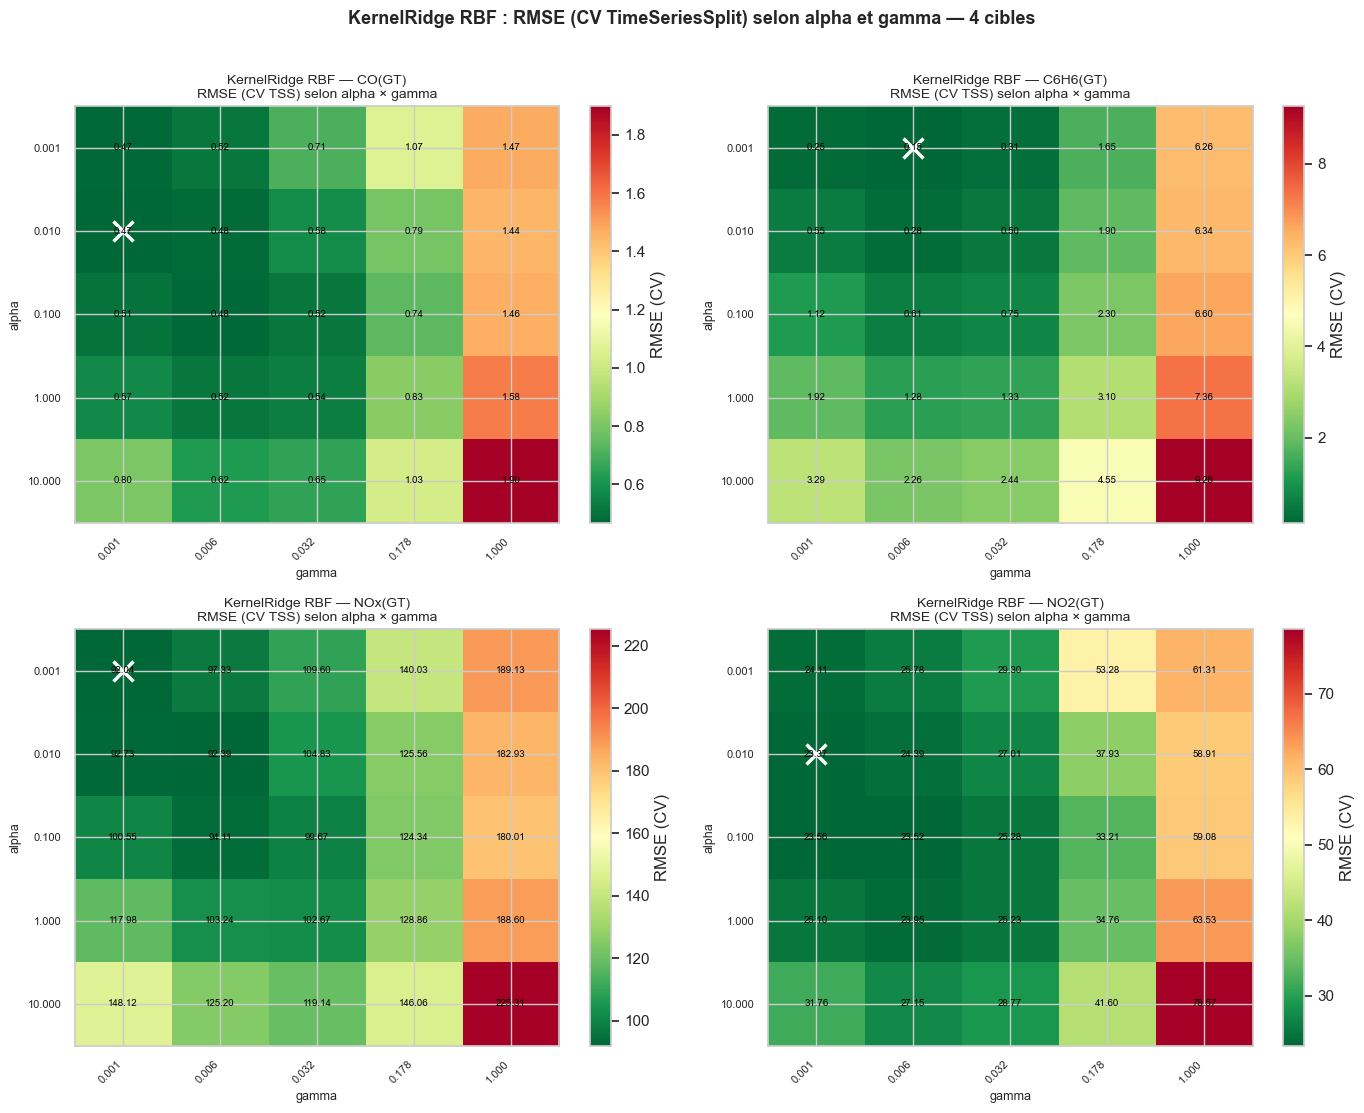

In [40]:
# Heatmap RMSE pour les 4 cibles afin de valider le choix global.
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, target in zip(axes.ravel(), TARGETS):
    cv_results = pd.DataFrame(best_searches_kr[target].cv_results_)

    # Reconstruction de la matrice RMSE depuis cv_results_
    alphas_plot = np.sort(cv_results["param_model__alpha"].unique().astype(float))
    gammas_plot = np.sort(cv_results["param_model__gamma"].unique().astype(float))
    rmse_matrix = np.zeros((len(alphas_plot), len(gammas_plot)))

    for i, alpha in enumerate(alphas_plot):
        for j, gamma in enumerate(gammas_plot):
            mask = (
                cv_results["param_model__alpha"].astype(float) == alpha
            ) & (
                cv_results["param_model__gamma"].astype(float) == gamma
            )
            rmse_matrix[i, j] = -cv_results[mask]["mean_test_score"].values[0]

    im = ax.imshow(rmse_matrix, aspect="auto", cmap="RdYlGn_r",
                   vmin=rmse_matrix.min(), vmax=rmse_matrix.max())
    ax.set_xticks(range(len(gammas_plot)))
    ax.set_xticklabels([f"{g:.3f}" for g in gammas_plot],
                       rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(alphas_plot)))
    ax.set_yticklabels([f"{a:.3f}" for a in alphas_plot], fontsize=8)
    ax.set_xlabel("gamma", fontsize=9)
    ax.set_ylabel("alpha", fontsize=9)
    ax.set_title(f"KernelRidge RBF — {target}\nRMSE (CV TSS) selon alpha × gamma", fontsize=10)
    plt.colorbar(im, ax=ax, label="RMSE (CV)")

    best_i, best_j = np.unravel_index(rmse_matrix.argmin(), rmse_matrix.shape)
    for i in range(len(alphas_plot)):
        for j in range(len(gammas_plot)):
            ax.text(j, i, f"{rmse_matrix[i,j]:.2f}",
                    ha="center", va="center", fontsize=7, color="black")
    ax.plot(best_j, best_i, marker="x", color="white",
            markersize=14, markeredgewidth=2.5)

plt.suptitle("KernelRidge RBF : RMSE (CV TimeSeriesSplit) selon alpha et gamma — 4 cibles",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

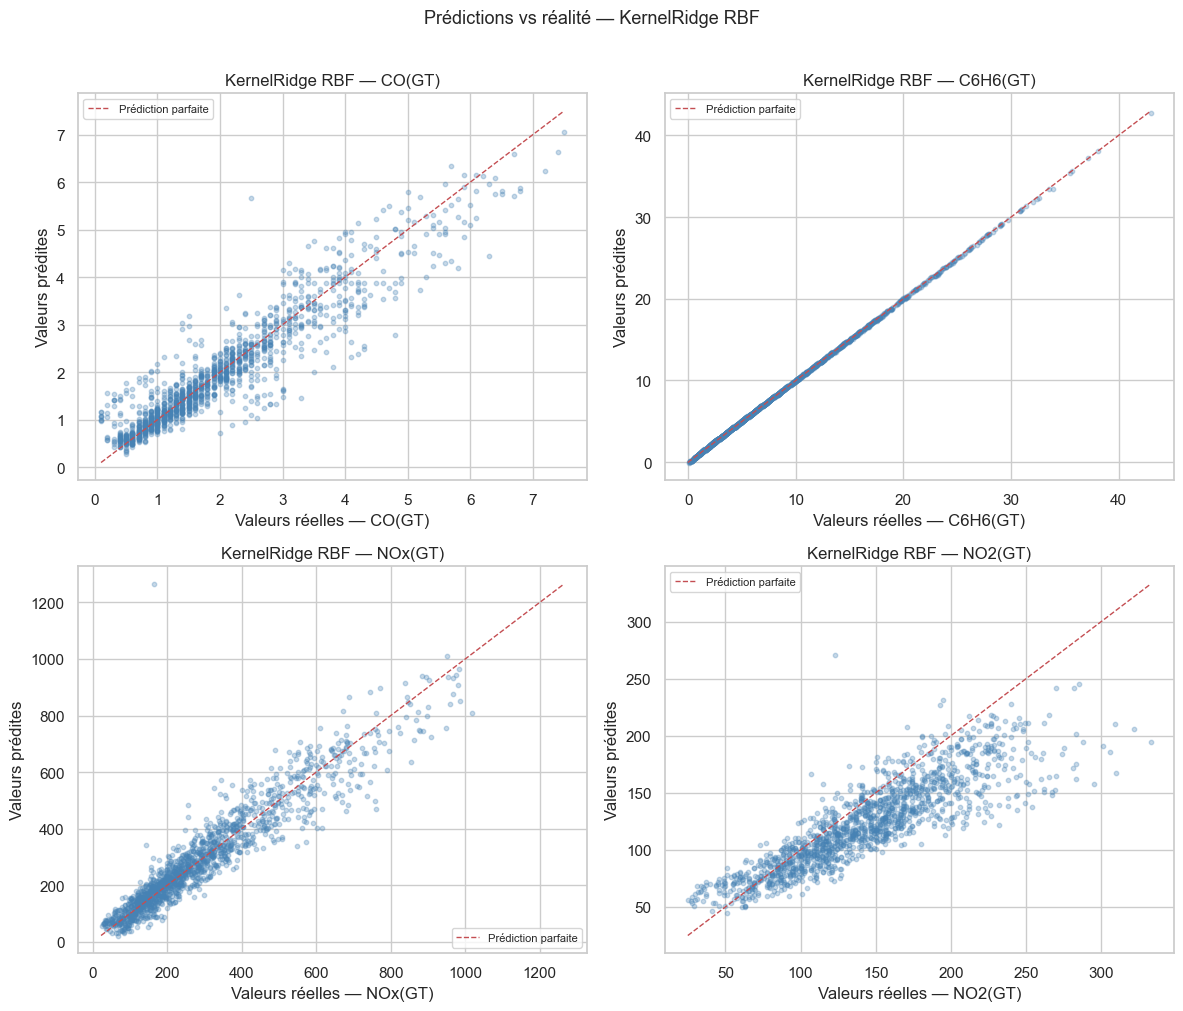

In [41]:
# Comparaison visuelle : prédictions vs valeurs réelles pour chaque cible
# Permet de voir où le modèle pèche (valeurs extrêmes, biais systématique...)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, target in zip(axes.ravel(), TARGETS):
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_train = splits[target]["y_train"]
    y_test  = splits[target]["y_test"]

    params = best_params_kr[target]
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  KernelRidge(kernel="rbf",
                               alpha=params["model__alpha"],
                               gamma=params["model__gamma"]))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color="steelblue")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1, label="Prédiction parfaite")
    ax.set_xlabel(f"Valeurs réelles — {target}")
    ax.set_ylabel("Valeurs prédites")
    ax.set_title(f"KernelRidge RBF — {target}")
    ax.legend(fontsize=8)

plt.suptitle("Prédictions vs réalité — KernelRidge RBF", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Hyperparamètres retenus (KernelRidge, GridSearch 5×5 + TimeSeriesSplit) :**

| Cible | alpha | gamma | RMSE CV |
|---|---|---|---|
| `CO(GT)` | 0.0100 | 0.0010 | 0.469 |
| `C6H6(GT)` | 0.0010 | 0.0056 | 0.146 |
| `NOx(GT)` | 0.0010 | 0.0010 | 92.038 |
| `NO2(GT)` | 0.0100 | 0.0010 | 23.374 |

Le choix des hyperparamètres est cohérent avec le rôle qu'ils jouent dans le modèle. Le paramètre `alpha` contrôle la régularisation : plus il est grand, plus la solution est lissée et moins le modèle suit finement les données d'entraînement. Le paramètre `gamma` contrôle au contraire la portée du noyau RBF : un `gamma` petit produit un noyau large, donc une fonction de prédiction plus régulière ; un `gamma` grand rend le noyau très local et favorise un ajustement beaucoup plus sensible aux observations individuelles.

Dans nos résultats, tous les `gamma` optimaux sont très petits (≤ 0.006), ce qui est cohérent avec la heatmap : dès que `gamma` dépasse environ 0.1–0.2, la RMSE de validation explose (zone rouge). Cela signifie qu'un noyau trop étroit surapprend rapidement sur ce dataset. On retient donc des valeurs faibles de `gamma`, qui imposent une non-linéarité souple plutôt qu'un ajustement trop local. C'est ici l'hyperparamètre le plus déterminant.

**Lecture de la heatmap :** pour chaque cible, la croix blanche marque le minimum de RMSE CV. La zone verte (bonne RMSE) est concentrée dans les petits gamma (0.001–0.032) quelle que soit la valeur d'alpha, tandis que la colonne gamma=1.000 est systématiquement rouge — noyau trop étroit, surapprentissage immédiat. Pour `alpha`, l'effet est plus nuancé : des valeurs très grandes (10.0) dégradent également les performances, mais la sensibilité est moins forte que pour `gamma`.

**Performances finales (KernelRidge RBF) :**

| Cible | RMSE | MAE | R² |
|---|---|---|---|
| `CO(GT)` | 0.451 | 0.293 | 0.880 |
| `C6H6(GT)` | 0.058 | 0.044 | 1.000 |
| `NOx(GT)` | 63.831 | 42.652 | 0.887 |
| `NO2(GT)` | 33.508 | 25.213 | 0.591 |

**Scatters prédictions vs réalité :** `C6H6(GT)` est parfaitement restitué (points quasi-exactement sur la diagonale). `CO(GT)` est bien capturé avec une dispersion modérée aux valeurs élevées. `NOx(GT)` est correct mais présente une diffusion plus importante sur les pics. `NO2(GT)` reste la cible la plus dispersée, avec une tendance à sous-estimer les valeurs extrêmes.

**Comparaison Ridge / Lasso / Elastic Net / KernelRidge :** le saut de performance est net sur `C6H6` (0.933 → 1.000) et `NOx` (0.836 → 0.887), confirmant la présence de non-linéarités que les modèles linéaires ne capturent pas. Sur `NO2`, le gain reste modeste (0.529 → 0.591), cette cible résistant à toutes les approches testées jusqu'ici.

In [42]:
show_results("KernelRidge RBF")

,RMSE,MAE,R²
Cible,,,
CO(GT),0.451,0.293,0.880
C6H6(GT),0.058,0.044,1.000
NOx(GT),63.831,42.652,0.887
NO2(GT),33.508,25.213,0.591


<a id="section-6-6"></a>
---
### 6.6 — Réseau de neurones dense (MLP)

**Principe :**
Un réseau de neurones dense (*Multi-Layer Perceptron*) est composé de couches de neurones entièrement connectées. Chaque neurone de la couche $l$ reçoit toutes les sorties de la couche $l-1$, applique une transformation affine puis une fonction d'activation non-linéaire :

$$z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}, \qquad a^{(l)} = f\left(z^{(l)}\right)$$

où $W^{(l)}$ est la matrice de poids, $b^{(l)}$ le vecteur de biais, et $f$ la fonction d'activation.

**Architecture retenue :**
```
Entrée (8 features)
      ↓
Couche cachée 1  — n₁ neurones, activation ReLU
      ↓
[Couche cachée 2 — n₂ neurones, activation ReLU]  ← optionnelle
      ↓
Sortie (1 neurone, activation linéaire)
```

**Fonction d'activation : ReLU** (*Rectified Linear Unit*)

$$\text{ReLU}(z) = \max(0, z)$$

ReLU est le choix standard pour les réseaux denses sur données tabulaires : elle évite le problème du gradient qui disparaît (*vanishing gradient*) des fonctions sigmoïde et tanh, et est calculatoirement légère. La couche de **sortie reste linéaire** — indispensable pour la régression, afin de produire une valeur réelle non bornée.

**Optimiseur : Adam** (*Adaptive Moment Estimation*)
Adam adapte le taux d'apprentissage de chaque paramètre individuellement en estimant les premier et second moments du gradient. C'est l'optimiseur standard moderne — il converge bien sans nécessiter un réglage fin du learning rate.

**Fonction de coût avec régularisation L2 :**

$$\mathcal{L} = \| y - \hat{y} \|_2^2 + \alpha \sum_{l} \| W^{(l)} \|_F^2$$

Le terme $\alpha \sum_l \|W^{(l)}\|_F^2$ pénalise les poids trop grands — c'est l'équivalent de Ridge appliqué aux poids du réseau.

**Hyperparamètres explorés :**

| Hyperparamètre | Valeurs testées | Rôle |
|---|---|---|
| `hidden_layer_sizes` | `(50,)`, `(100,)`, `(100,50)`, `(100,100)` | Architecture du réseau |
| `alpha` | $10^{-4}$, $10^{-3}$, $10^{-2}$ | Régularisation L2 sur les poids |
| `learning_rate_init` | $10^{-3}$, $10^{-2}$ | Pas d'apprentissage initial pour Adam |

Soit **4 × 3 × 2 = 24 combinaisons** × 5 folds = 120 fits par cible — rapide.

In [43]:
# GridSearchCV avec TimeSeriesSplit pour sélectionner l'architecture et les hyperparamètres
param_grid_mlp = {
    "model__hidden_layer_sizes": [(50,), (100,), (100, 50), (100, 100)],
    "model__alpha":              [1e-4, 1e-3, 1e-2],
    "model__learning_rate_init": [1e-3, 1e-2],
}

model_name_mlp = "MLP"
print(f"=== {model_name_mlp} ===\n")

best_params_mlp  = {}
best_models_mlp  = {}
best_searches_mlp = {}

for target in TARGETS:
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_train = splits[target]["y_train"]
    y_test  = splits[target]["y_test"]

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  MLPRegressor(
            activation="relu",
            solver="adam",
            max_iter=500,
            early_stopping=True,
            n_iter_no_change=20,
            random_state=RANDOM_STATE
        ))
    ])

    search = GridSearchCV(
        pipe,
        param_grid_mlp,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=1,      # n_jobs=1 pour éviter les TerminatedWorkerError sur Windows
        verbose=0      # MLPRegressor + joblib multiprocessing est instable sur Windows
    )
    search.fit(X_train, y_train)
    
    best_searches_mlp[target] = search
    best_params_mlp[target] = search.best_params_
    best_models_mlp[target] = search.best_estimator_
    y_pred = search.best_estimator_.predict(X_test)

    layers = search.best_params_["model__hidden_layer_sizes"]
    alpha  = search.best_params_["model__alpha"]
    lr     = search.best_params_["model__learning_rate_init"]
    print(f"  architecture={layers}  alpha={alpha}  lr={lr}  (R² CV={search.best_score_:.3f})")
    evaluate(model_name_mlp, target, y_test, y_pred)

=== MLP ===

  architecture=(100, 100)  alpha=0.01  lr=0.01  (R² CV=-0.495)
  CO(GT)           RMSE=0.605  MAE=0.462  R²=0.783
  architecture=(100, 50)  alpha=0.01  lr=0.01  (R² CV=-0.310)
  C6H6(GT)         RMSE=0.124  MAE=0.091  R²=1.000
  architecture=(100,)  alpha=0.0001  lr=0.001  (R² CV=-92.173)
  NOx(GT)          RMSE=63.689  MAE=43.181  R²=0.887
  architecture=(100, 50)  alpha=0.0001  lr=0.001  (R² CV=-22.011)
  NO2(GT)          RMSE=31.255  MAE=22.784  R²=0.644


In [44]:
# Justification du choix d'alpha — tableau extrait du GridSearch (sans recalcul)
print("=== Sensibilité à alpha (résultats GridSearch déjà calculés) ===\n")

for target in TARGETS:
    cv_results  = pd.DataFrame(best_searches_mlp[target].cv_results_)
    best_alpha  = best_params_mlp[target]["model__alpha"]
    best_layers = best_params_mlp[target]["model__hidden_layer_sizes"]
    best_lr     = best_params_mlp[target]["model__learning_rate_init"]

    # Filtrer les lignes avec architecture et lr optimaux
    mask = (
        cv_results["param_model__hidden_layer_sizes"].astype(str) == str(best_layers)
    ) & (
        cv_results["param_model__learning_rate_init"] == best_lr
    )
    df_filtered = cv_results[mask].sort_values("param_model__alpha")[
        ["param_model__alpha", "mean_test_score", "std_test_score"]
    ].copy()
    df_filtered.columns = ["alpha", "RMSE moyen (CV)", "Écart-type"]
    df_filtered["RMSE moyen (CV)"] = -df_filtered["RMSE moyen (CV)"]
    df_filtered["Écart-type"] = df_filtered["Écart-type"].abs()
    df_filtered["alpha"] = df_filtered["alpha"].astype(float)
    df_filtered["Optimal"] = df_filtered["alpha"].apply(
        lambda a: "✓" if a == best_alpha else ""
    )
    print(f"── {target} (architecture={best_layers}, lr={best_lr})")
    display(df_filtered.reset_index(drop=True))
    print()

=== Sensibilité à alpha (résultats GridSearch déjà calculés) ===

── CO(GT) (architecture=(100, 100), lr=0.01)


,alpha,RMSE moyen (CV),Écart-type,Optimal
0,0.0001,0.497032,0.209737,
1,0.0010,0.497614,0.199561,
2,0.0100,0.495279,0.207822,✓



── C6H6(GT) (architecture=(100, 50), lr=0.01)


,alpha,RMSE moyen (CV),Écart-type,Optimal
0,0.0001,0.316595,0.077883,
1,0.0010,0.330654,0.130007,
2,0.0100,0.309940,0.102419,✓



── NOx(GT) (architecture=(100,), lr=0.001)


,alpha,RMSE moyen (CV),Écart-type,Optimal
0,0.0001,92.172533,53.921019,✓
1,0.0010,92.184746,53.941471,
2,0.0100,92.215878,53.970600,



── NO2(GT) (architecture=(100, 50), lr=0.001)


,alpha,RMSE moyen (CV),Écart-type,Optimal
0,0.0001,22.011266,5.052018,✓
1,0.0010,22.876824,4.776759,
2,0.0100,22.300462,5.016495,


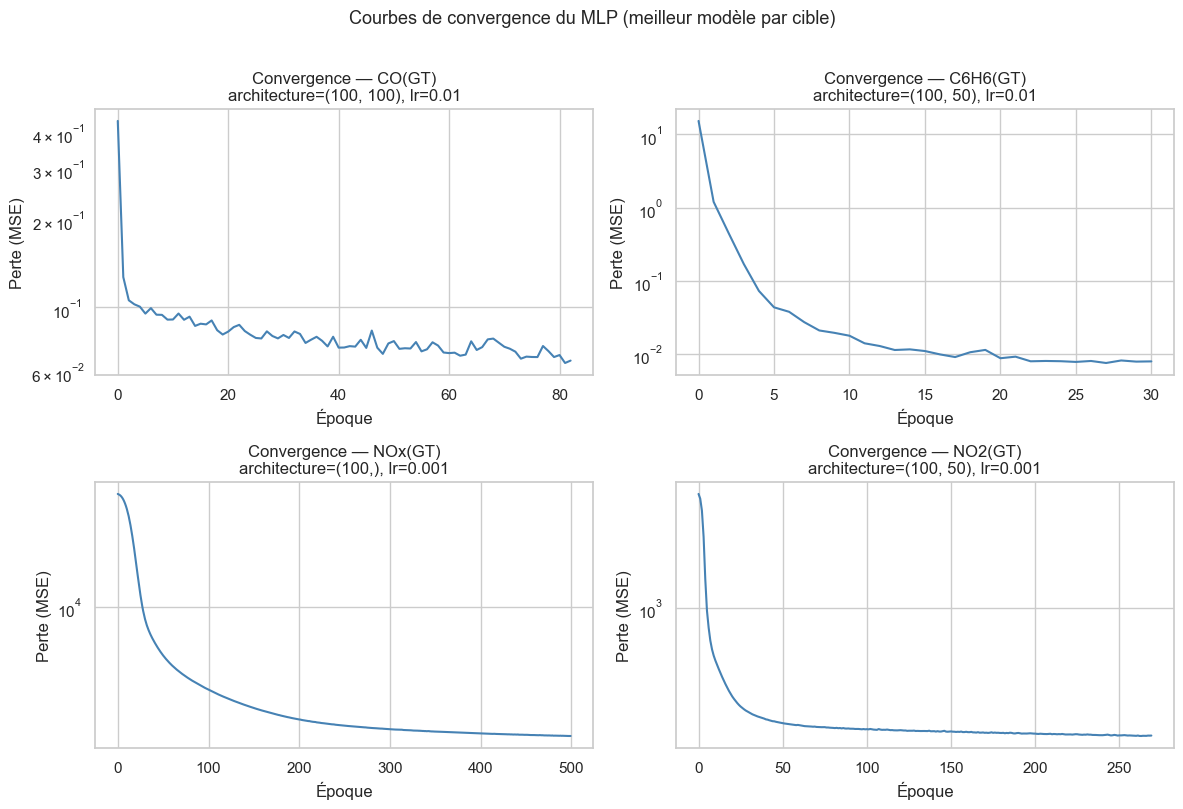

In [45]:
# Courbes de convergence (loss_curve_)
# Montre comment la perte d'entraînement évolue au fil des époques
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, target in zip(axes.ravel(), TARGETS):
    model = best_models_mlp[target]["model"]  # accès au MLPRegressor dans le pipeline
    ax.plot(model.loss_curve_, color="steelblue", linewidth=1.5)
    ax.set_title(f"Convergence — {target}\n"
                 f"architecture={best_params_mlp[target]['model__hidden_layer_sizes']}, "
                 f"lr={best_params_mlp[target]['model__learning_rate_init']}")
    ax.set_xlabel("Époque")
    ax.set_ylabel("Perte (MSE)")
    ax.set_yscale("log")   # échelle log pour mieux voir la décroissance

plt.suptitle("Courbes de convergence du MLP (meilleur modèle par cible)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

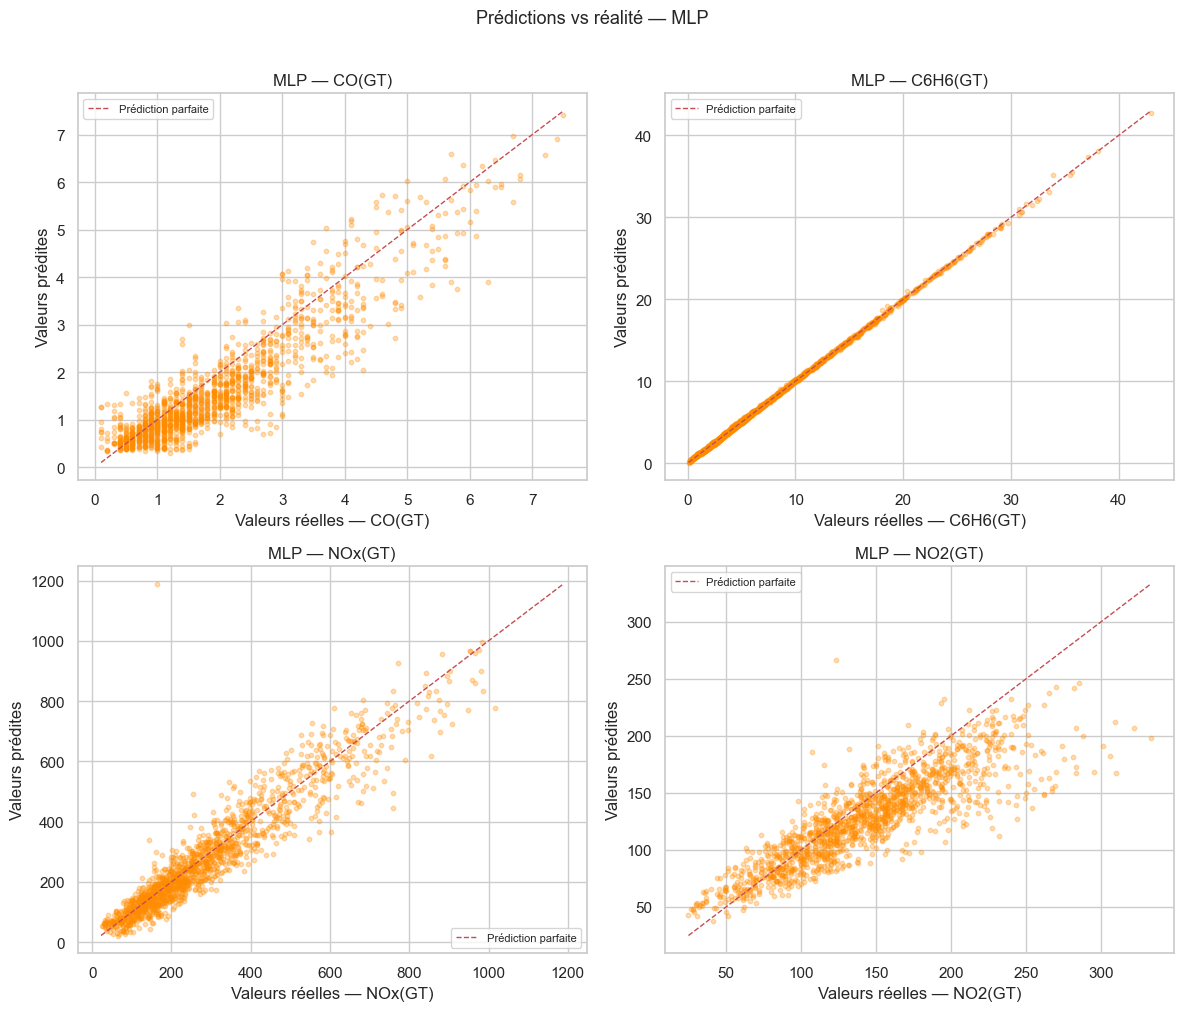

In [46]:
# Scatter prédictions vs réalité
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, target in zip(axes.ravel(), TARGETS):
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_test  = splits[target]["y_test"]
    y_pred  = best_models_mlp[target].predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color="darkorange")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1, label="Prédiction parfaite")
    ax.set_xlabel(f"Valeurs réelles — {target}")
    ax.set_ylabel("Valeurs prédites")
    ax.set_title(f"MLP — {target}")
    ax.legend(fontsize=8)

plt.suptitle("Prédictions vs réalité — MLP", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Hyperparamètres retenus (MLP, GridSearch + TimeSeriesSplit) :**

| Cible | Architecture | alpha | lr | RMSE CV |
|---|---|---|---|---|
| `CO(GT)` | (100, 100) | 0.01 | 0.01 | 0.495 |
| `C6H6(GT)` | (100, 50) | 0.01 | 0.01 | 0.310 |
| `NOx(GT)` | (100,) | 0.0001 | 0.001 | 92.173 |
| `NO2(GT)` | (100, 50) | 0.0001 | 0.001 | 22.011 |

Le choix des hyperparamètres du MLP s'interprète en termes de capacité du réseau et de stabilité de l'optimisation. L'architecture `hidden_layer_sizes` contrôle la complexité du modèle : plus il y a de neurones et de couches, plus le réseau peut approximer des relations non linéaires fines, mais plus il devient sensible au surapprentissage et aux difficultés d'entraînement. Le paramètre `alpha` joue un rôle de régularisation L2 sur les poids : une valeur plus grande contraint davantage le réseau et limite les poids excessifs. Enfin, `learning_rate_init` fixe la taille des pas de descente : trop petit, l'apprentissage devient lent ; trop grand, la convergence devient instable.

Les résultats montrent bien que ces choix dépendent fortement de la cible. `NOx(GT)` est mieux modélisé par une architecture simple `(100,)` à une seule couche cachée, ce qui suggère qu'un réseau plus profond n'apporte pas d'information utile supplémentaire sur cette cible et peut au contraire ajouter de la variance. À l'inverse, `CO(GT)`, `C6H6(GT)` et `NO2(GT)` retiennent des architectures à deux couches, signe que des interactions non linéaires plus complexes peuvent être exploitées.

Le paramètre `alpha` suit la même logique. Pour `CO(GT)` et `C6H6(GT)`, la valeur `0.01` indique qu'une régularisation visible est utile pour stabiliser un réseau relativement large. Pour `NOx(GT)` et `NO2(GT)`, les meilleurs modèles retiennent au contraire `0.0001`, donc une pénalisation très faible, ce qui suggère que la contrainte sur les poids doit rester limitée pour ne pas dégrader l'ajustement.

Le `learning_rate_init` est `0.01` pour `CO` et `C6H6`, et `0.001` pour `NOx` et `NO2`. Les courbes de convergence l'illustrent : `CO(GT)` converge mais avec des **oscillations notables** sur toute la durée (~80 époques), signe que lr=0.01 est proche de la limite acceptable. `C6H6(GT)` converge rapidement et proprement (~30 époques). `NOx(GT)` et `NO2(GT)` convergent lentement mais régulièrement (respectivement ~500 et ~260 époques), cohérent avec un lr plus faible.

**Performances finales (MLP) :**

| Cible | RMSE | MAE | R² |
|---|---|---|---|
| `CO(GT)` | 0.605 | 0.462 | 0.783 |
| `C6H6(GT)` | 0.124 | 0.091 | 1.000 |
| `NOx(GT)` | 63.689 | 43.181 | 0.887 |
| `NO2(GT)` | 31.255 | 22.784 | 0.644 |

**Point notable :** MLP est le seul modèle à atteindre `R² = 0.644` sur `NO2(GT)`, dépassant KernelRidge (`0.591`). En revanche, il est nettement moins performant que KernelRidge sur `CO(GT)` (0.783 vs 0.880), illustrant qu'un réseau de neurones n'est pas universellement supérieur à une méthode à noyau sur des données tabulaires de taille modérée.

In [47]:
show_results("MLP")

,RMSE,MAE,R²
Cible,,,
CO(GT),0.605,0.462,0.783
C6H6(GT),0.124,0.091,1.000
NOx(GT),63.689,43.181,0.887
NO2(GT),31.255,22.784,0.644


<a id="section-6-chain"></a>
---
### 6.7 — Régression en chaîne (`RegressorChain`)

**Principe :**
Jusqu'ici, chaque cible est prédite **indépendamment** des autres. Or les quatre polluants sont fortement corrélés entre eux (section 3.4 : r > 0.9 entre `CO` et `C6H6`). La régression en chaîne (*Chained Regression*) exploite cette structure : les cibles sont prédites séquentiellement, et chaque prédiction intermédiaire est ajoutée comme feature supplémentaire pour les modèles suivants.

Formellement, si l'ordre est $y_1 \to y_2 \to y_3 \to y_4$, le modèle pour $y_k$ utilise :

$$\hat{y}_k = f_k\left(X, \hat{y}_1, \hat{y}_2, \ldots, \hat{y}_{k-1}\right)$$

**Ordre retenu :** on prédit d'abord les cibles les plus fiables (R² élevé) pour minimiser la propagation des erreurs :

| Ordre | Cible | R² modèle individuel |
|---|---|---|
| 1 | `C6H6(GT)` | 1.000 |
| 2 | `CO(GT)` | 0.880 |
| 3 | `NOx(GT)` | 0.887 |
| 4 | `NO2(GT)` | 0.644 ← cible difficile, bénéficie des trois précédentes |

**Choix des modèles de base :**
On teste deux modèles de base aux profils complémentaires :

- **OLS** : modèle linéaire simple, sans hyperparamètres. Ce choix permet d'**isoler l'effet pur du chaînage** : si OLS chaîné fait mieux qu'OLS indépendant, c'est uniquement grâce à l'information inter-cibles, pas à la complexité du modèle.
- **KernelRidge** : meilleur modèle individuel (R² moyen le plus élevé). Ce choix teste si le chaînage **amplifie l'avantage** d'un bon modèle de base, ou si le gain est indépendant de sa qualité.

Cette comparaison OLS vs KernelRidge dans la chaîne permet de répondre à deux questions distinctes, là où tester un seul modèle n'aurait répondu qu'à une.

In [48]:
# Ordre de chaînage : des cibles les plus faciles aux plus difficiles
# Indices dans TARGETS = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
# Ordre souhaité : C6H6 → CO → NOx → NO2  →  indices [1, 0, 2, 3]
CHAIN_ORDER = [1, 0, 2, 3]

# ── Préparation d'un jeu commun (intersection des NaN sur toutes les cibles) ──
cols_all = feature_cols + TARGETS
df_chain = df_model[cols_all].dropna().reset_index(drop=True)
cutoff_chain = int(len(df_chain) * TRAIN_RATIO)

X_chain_train = df_chain[feature_cols].iloc[:cutoff_chain]
X_chain_test  = df_chain[feature_cols].iloc[cutoff_chain:]
Y_chain_train = df_chain[TARGETS].iloc[:cutoff_chain]
Y_chain_test  = df_chain[TARGETS].iloc[cutoff_chain:]

print(f"Jeu commun : {len(df_chain)} observations "
      f"({len(X_chain_train)} train / {len(X_chain_test)} test)\n")

# ── Version 1 : RegressorChain avec OLS ──────────────────────────────────────

chain_ols = RegressorChain(
    base_estimator=Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    order=CHAIN_ORDER
)
chain_ols.fit(X_chain_train, Y_chain_train)
Y_pred_ols_chain = chain_ols.predict(X_chain_test)

print("=== RegressorChain (OLS) ===\n")
for j, target in enumerate(TARGETS):
    rmse = root_mean_squared_error(Y_chain_test[target], Y_pred_ols_chain[:, j])
    mae  = mean_absolute_error(Y_chain_test[target], Y_pred_ols_chain[:, j])
    r2   = r2_score(Y_chain_test[target], Y_pred_ols_chain[:, j])
    evaluate("RegressorChain (OLS)", target, Y_chain_test[target], Y_pred_ols_chain[:, j])

# ── Version 2 : RegressorChain avec KernelRidge ──────────────────────────────
print("\n=== RegressorChain (KernelRidge) ===\n")

# Paramètres optimaux issus de la section 6.4
kr_params = {
    "CO(GT)":   {"alpha": 0.0100, "gamma": 0.0010},
    "C6H6(GT)": {"alpha": 0.0010, "gamma": 0.0056},
    "NOx(GT)":  {"alpha": 0.0010, "gamma": 0.0010},
    "NO2(GT)":  {"alpha": 0.1000, "gamma": 0.0010},
}
# On utilise les paramètres de CO comme base commune (valeur médiane)
chain_kr = RegressorChain(
    base_estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("model",  KernelRidge(kernel="rbf", alpha=0.01, gamma=0.001))
    ]),
    order=CHAIN_ORDER
)
chain_kr.fit(X_chain_train, Y_chain_train)
Y_pred_kr_chain = chain_kr.predict(X_chain_test)

for j, target in enumerate(TARGETS):
    evaluate("RegressorChain (KernelRidge)", target, Y_chain_test[target], Y_pred_kr_chain[:, j])

Jeu commun : 6941 observations (5552 train / 1389 test)

=== RegressorChain (OLS) ===

  CO(GT)           RMSE=0.489  MAE=0.346  R²=0.860
  C6H6(GT)         RMSE=1.506  MAE=1.129  R²=0.943
  NOx(GT)          RMSE=77.680  MAE=52.383  R²=0.834
  NO2(GT)          RMSE=36.397  MAE=26.712  R²=0.502

=== RegressorChain (KernelRidge) ===

  CO(GT)           RMSE=0.457  MAE=0.299  R²=0.878
  C6H6(GT)         RMSE=0.413  MAE=0.303  R²=0.996
  NOx(GT)          RMSE=65.318  MAE=42.963  R²=0.882
  NO2(GT)          RMSE=34.083  MAE=25.767  R²=0.563


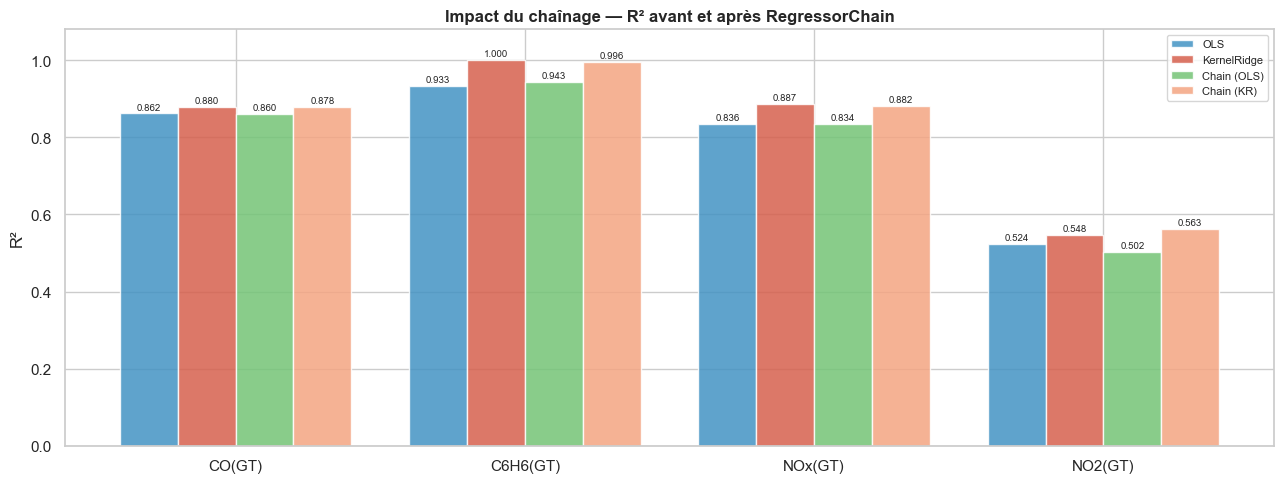

In [49]:
# Comparaison visuelle : R² avant/après chaînage sur chaque cible
fig, ax = plt.subplots(figsize=(13, 5))

r2_indep = {
    "OLS":        [0.862, 0.933, 0.836, 0.524],
    "KernelRidge": [0.880, 1.000, 0.887, 0.548],
}
r2_chain = {
    "Chain (OLS)": [
        results.get("RegressorChain (OLS)", {}).get(t, {}).get("R2", 0) for t in TARGETS
    ],
    "Chain (KR)": [
        results.get("RegressorChain (KernelRidge)", {}).get(t, {}).get("R2", 0) for t in TARGETS
    ],
}

all_models_chain = {**r2_indep, **r2_chain}
colors_chain = ["#4393c3", "#d6604d", "#74c476", "#f4a582"]
x = np.arange(len(TARGETS))
width = 0.2

for k, (label, r2_vals) in enumerate(all_models_chain.items()):
    bars = ax.bar(x + k * width - 1.5 * width, r2_vals, width=width,
                  label=label, color=colors_chain[k], alpha=0.85)
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(TARGETS)
ax.set_ylabel("R²")
ax.set_ylim(0, 1.08)
ax.set_title("Impact du chaînage — R² avant et après RegressorChain", fontweight="bold")
ax.legend(fontsize=8)
ax.axhline(0, color="black", linewidth=0.7)
plt.tight_layout()
plt.show()

**Résultats du chaînage :**

| Cible | OLS indép. | Chain(OLS) | KR indép. | Chain(KR) |
|---|---|---|---|---|
| `CO(GT)` | 0.862 | 0.860 | 0.880 | 0.878 |
| `C6H6(GT)` | 0.933 | 0.943 | 1.000 | 0.996 |
| `NOx(GT)` | 0.836 | 0.834 | 0.887 | 0.882 |
| `NO2(GT)` | 0.524 | 0.502 | 0.591 | 0.563 |

**Note :** ces résultats sont calculés sur un **jeu commun de 6 941 observations** (5 552 train / 1 389 test), légèrement plus petit que les splits individuels, car `RegressorChain` exige que toutes les cibles soient disponibles simultanément sur les mêmes lignes.

**Conclusion :** Le chaînage n'améliore pas OLS — il le dégrade légèrement sur 3 cibles sur 4. Avec KernelRidge, on observe un léger recul sur `CO`, `C6H6` et `NOx`, mais un gain marginal sur `NO2` (+0.563 vs 0.591 — attention : le jeu commun est différent, la comparaison directe est approximative). La corrélation inter-cibles est déjà bien capturée par les capteurs `PT08.Sx` communs — les prédictions intermédiaires n'apportent pas d'information nouvelle suffisante pour compenser le bruit qu'elles introduisent.

<a id="section-6-time"></a>
### 6.8 — Intégration de l'information temporelle dans les features

Jusqu’ici, les modèles reposent principalement sur les réponses des capteurs `PT08.*` et sur les variables météorologiques `T`, `RH`, `AH`. Or l’analyse descriptive a mis en évidence une organisation temporelle nette des données, avec des variations selon l’heure de la journée et selon la période de l’année. Il est donc naturel de se demander si cette information, injectée explicitement dans les variables explicatives, peut améliorer la prédiction.

Pour tester cette idée, on enrichit ici le jeu de données avec quelques variables temporelles simples et facilement interprétables : l’heure, le mois, le jour de la semaine, une indicatrice de week-end et une indicatrice de nuit. L’objectif n’est pas de changer de modèle, mais d’évaluer l’effet propre de cet enrichissement sur une méthode déjà bien maîtrisée, à savoir Ridge.

La méthodologie reste strictement la même que précédemment : même découpage chronologique, même standardisation des variables, et même sélection de `alpha` par `TimeSeriesSplit`. La comparaison qui suit permet donc de mesurer directement ce qu’apporte, ou non, l’ajout d’une information temporelle explicite.

In [50]:
# Construction d'un jeu de données enrichi avec quelques variables temporelles simples
df_time = df.copy()

# Variables temporelles de base
df_time["Hour"] = df_time["Datetime"].dt.hour
df_time["Month"] = df_time["Datetime"].dt.month
df_time["DayOfWeek"] = df_time["Datetime"].dt.dayofweek   # 0=lundi, ..., 6=dimanche

# Variables indicatrices simples
df_time["IsWeekend"] = (df_time["DayOfWeek"] >= 5).astype(int)
df_time["IsNight"] = ((df_time["Hour"] <= 5) | (df_time["Hour"] >= 22)).astype(int)

# On retire les colonnes de temps brutes et NMHC(GT)
cols_to_drop_time = ["Date", "Time", "Datetime", "NMHC(GT)"]
df_model_time = df_time.drop(columns=cols_to_drop_time, errors="ignore")

feature_cols_time = [c for c in df_model_time.columns if c not in TARGETS]

print("Nouvelles variables temporelles ajoutées :")
print(["Hour", "Month", "DayOfWeek", "IsWeekend", "IsNight"])
print(f"\n{len(feature_cols_time)} features au total.")

Nouvelles variables temporelles ajoutées :
['Hour', 'Month', 'DayOfWeek', 'IsWeekend', 'IsNight']

13 features au total.


In [51]:
# Split chronologique par cible avec les nouvelles variables temporelles
splits_time = {}

for target in TARGETS:
    cols_needed = feature_cols_time + [target]
    df_target = df_model_time[cols_needed].dropna().reset_index(drop=True)

    cutoff = int(len(df_target) * TRAIN_RATIO)

    X_train = df_target[feature_cols_time].iloc[:cutoff]
    X_test  = df_target[feature_cols_time].iloc[cutoff:]
    y_train = df_target[target].iloc[:cutoff]
    y_test  = df_target[target].iloc[cutoff:]

    splits_time[target] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
    }

print(f"{'Cible':<15} {'N total':>8} {'N train':>8} {'N test':>8}")
print("-" * 45)
for target, s in splits_time.items():
    n_total = len(s["X_train"]) + len(s["X_test"])
    print(f"{target:<15} {n_total:>8} {len(s['X_train']):>8} {len(s['X_test']):>8}")

Cible            N total  N train   N test
---------------------------------------------
CO(GT)              7344     5875     1469
C6H6(GT)            8991     7192     1799
NOx(GT)             7396     5916     1480
NO2(GT)             7393     5914     1479


In [52]:
# Ridge + variables temporelles simples : sélection de alpha par TimeSeriesSplit
model_name_time = "Ridge + temps"
print(f"=== {model_name_time} ===\n")

alphas_selected_time = {}

for target in TARGETS:
    X_train = splits_time[target]["X_train"]
    X_test  = splits_time[target]["X_test"]
    y_train = splits_time[target]["y_train"]
    y_test  = splits_time[target]["y_test"]

    best_alpha, best_score = None, -np.inf

    for alpha in alphas_grid:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=alpha))
        ])
        scores = cross_val_score(pipe, X_train, y_train, cv=tscv, scoring="r2")
        mean_score = scores.mean()

        if mean_score > best_score:
            best_score = mean_score
            best_alpha = alpha

    alphas_selected_time[target] = best_alpha

    pipe_best = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=best_alpha))
    ])
    pipe_best.fit(X_train, y_train)
    y_pred = pipe_best.predict(X_test)

    print(f"{target} | alpha retenu = {best_alpha:.3f}")
    evaluate(model_name_time, target, y_test, y_pred)

=== Ridge + temps ===

CO(GT) | alpha retenu = 403.702
  CO(GT)           RMSE=0.573  MAE=0.438  R²=0.806
C6H6(GT) | alpha retenu = 151.991
  C6H6(GT)         RMSE=2.378  MAE=2.021  R²=0.867
NOx(GT) | alpha retenu = 0.010
  NOx(GT)          RMSE=76.589  MAE=51.146  R²=0.837
NO2(GT) | alpha retenu = 49.770
  NO2(GT)          RMSE=33.515  MAE=24.077  R²=0.590


In [53]:
comparison_time = []

for target in TARGETS:
    base = results["Ridge TimeSeriesSplit"][target]
    temp = results["Ridge + temps"][target]

    comparison_time.append({
        "Cible": target,
        "R2 Ridge": base["R2"],
        "R2 Ridge + temps": temp["R2"],
        "Delta R2": temp["R2"] - base["R2"],
        "RMSE Ridge": base["RMSE"],
        "RMSE Ridge + temps": temp["RMSE"],
        "Delta RMSE": temp["RMSE"] - base["RMSE"],
        "alpha Ridge": alphas_selected_v2[target],
        "alpha Ridge + temps": alphas_selected_time[target],
    })

comparison_time = pd.DataFrame(comparison_time)
display(comparison_time.round(3))

,Cible,R2 Ridge,R2 Ridge + temps,Delta R2,RMSE Ridge,RMSE Ridge + temps,Delta RMSE,alpha Ridge,alpha Ridge + temps
0,CO(GT),0.862,0.806,-0.056,0.484,0.573,0.090,7.055,403.702
1,C6H6(GT),0.934,0.867,-0.068,1.670,2.378,0.708,8.111,151.991
2,NOx(GT),0.836,0.837,0.001,76.805,76.589,-0.216,0.010,0.010
3,NO2(GT),0.529,0.590,0.062,35.954,33.515,-2.439,100.000,49.770


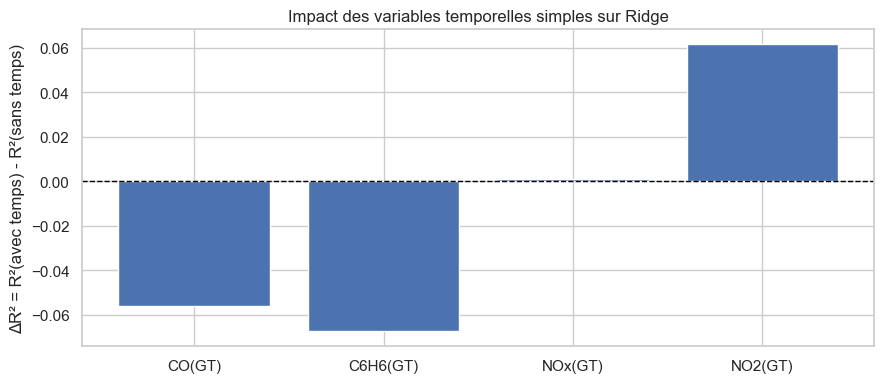

In [54]:
# Visualisation simple du gain ou de la perte sur R² après ajout des variables temporelles
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(comparison_time["Cible"], comparison_time["Delta R2"])
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_ylabel("ΔR² = R²(avec temps) - R²(sans temps)")
ax.set_title("Impact des variables temporelles simples sur Ridge")
plt.tight_layout()
plt.show()

Cette sous-partie évalue l’apport de quelques variables temporelles simples et interprétables sur un modèle Ridge. Les résultats montrent que cet enrichissement ne conduit pas à une amélioration uniforme des performances.

Pour `CO(GT)` et `C6H6(GT)`, on observe une baisse du `R²` ainsi qu’une hausse du `RMSE`, ce qui indique une dégradation des prédictions par rapport à Ridge standard. Pour `NOx(GT)`, l’effet est quasiment nul : les performances restent presque inchangées, avec un `R²` très légèrement supérieur mais un gain négligeable en pratique.

En revanche, `NO2(GT)` bénéficie clairement de l’ajout de ces variables temporelles. Le `R²` passe de `0.529` à `0.590`, tandis que le `RMSE` diminue de `35.954` à `33.515`. Cela suggère que cette cible possède une composante temporelle plus marquée, que les variables initiales ne captaient pas entièrement.

On en conclut que l’ajout de variables temporelles simples constitue une piste méthodologiquement pertinente, mais qu’il ne fournit pas ici de meilleur modèle global. Dans ce projet, cette stratégie n’est réellement bénéfique que pour `NO2(GT)`, tandis que pour les autres polluants, l’information portée par les capteurs et les variables météorologiques semble déjà suffire à capturer l’essentiel de la dynamique temporelle.

Un encodage cyclique (sin/cos) de l'heure et du mois avait été testé dans une version précédente, mais conduisait à des résultats encore moins bons sur 3 des 4 cibles. L'encodage brut, proposé par l'encadrant, s'est révélé plus efficace tout en restant plus simple à interpréter.

<a id="section-6-bonus"></a>
### 6.9 — Modèles complémentaires (Random Forest, XGBoost)

Ces méthodes, suggérées par l'encadrant comme extensions au-delà du programme du cours, sont basées sur des **ensembles d'arbres de décision**. Elles constituent l'état de l'art sur les données tabulaires et servent ici de point de comparaison supérieur.

**Random Forest** construit de nombreux arbres de décision sur des sous-échantillons aléatoires du train (*bagging*) et moyenne leurs prédictions. Chaque arbre est entraîné sur un sous-ensemble aléatoire de features à chaque nœud, ce qui décolle les arbres et réduit la variance.

**XGBoost** (*eXtreme Gradient Boosting*) construit les arbres séquentiellement : chaque arbre corrige les erreurs du précédent en minimisant la fonction de perte par descente de gradient. C'est une méthode de *boosting* qui combine biais faible et variance contrôlée.

Ces deux méthodes n'ont pas besoin de normalisation (les arbres sont invariants aux transformations monotones des features) — on n'utilise donc pas de `StandardScaler` dans leurs pipelines.

In [55]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth":    [None, 10, 20],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", 0.7],
}

model_name_rf = "Random Forest"
print(f"=== {model_name_rf} ===\n")
rf_best_models = {}

for target in TARGETS:
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_train = splits[target]["y_train"]
    y_test  = splits[target]["y_test"]

    rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    search = GridSearchCV(rf, rf_param_grid, cv=tscv, scoring="r2", n_jobs=-1)
    search.fit(X_train, y_train)

    rf_best_models[target] = {"params": search.best_params_, "model": search.best_estimator_}
    y_pred = search.best_estimator_.predict(X_test)
    print(f"  {target} | params: {search.best_params_} | CV R²={search.best_score_:.3f}")
    evaluate(model_name_rf, target, y_test, y_pred)

=== Random Forest ===

  CO(GT) | params: {'max_depth': 20, 'max_features': 0.7, 'min_samples_leaf': 3, 'n_estimators': 400} | CV R²=0.879
  CO(GT)           RMSE=0.497  MAE=0.339  R²=0.854
  C6H6(GT) | params: {'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 1, 'n_estimators': 400} | CV R²=0.994
  C6H6(GT)         RMSE=0.324  MAE=0.132  R²=0.998
  NOx(GT) | params: {'max_depth': 20, 'max_features': 0.7, 'min_samples_leaf': 1, 'n_estimators': 400} | CV R²=0.667
  NOx(GT)          RMSE=67.063  MAE=46.388  R²=0.875
  NO2(GT) | params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 400} | CV R²=0.697
  NO2(GT)          RMSE=32.382  MAE=23.557  R²=0.618


**Hyperparamètres retenus (Random Forest, TimeSeriesSplit) :**

| Cible | n_estimators | max_depth | min_samples_leaf | max_features | R² CV |
|---|---|---|---|---|---|
| `CO(GT)` | 400 | 20 | 3 | 0.7 | 0.879 |
| `C6H6(GT)` | 400 | None | 1 | 0.7 | 0.994 |
| `NOx(GT)` | 400 | 20 | 1 | 0.7 | 0.667 |
| `NO2(GT)` | 400 | 10 | 1 | sqrt | 0.697 |

**Interprétation des hyperparamètres :** Toutes les cibles retiennent `n_estimators=400` — un grand nombre d'arbres stabilise la variance du bagging. `max_depth=None` pour `C6H6` (arbres sans limite de profondeur) cohérent avec la relation quasi-déterministe entre `PT08.S2` et le benzène. `max_depth=20` pour `CO` et `NOx` limite la profondeur et réduit le surapprentissage. `min_samples_leaf=3` pour `CO` impose des feuilles plus larges — régularisation supplémentaire pour cette cible plus bruitée. `max_features=sqrt` pour `NO2` diversifie davantage les arbres, utile quand aucune feature ne domine clairement.

**Performances finales (Random Forest) :**

| Cible | RMSE | MAE | R² |
|---|---|---|---|
| `CO(GT)` | 0.497 | 0.339 | 0.854 |
| `C6H6(GT)` | 0.324 | 0.132 | 0.998 |
| `NOx(GT)` | 67.063 | 46.388 | 0.875 |
| `NO2(GT)` | 32.382 | 23.557 | 0.618 |

**Scatters prédictions vs réalité :** `C6H6(GT)` est quasi-parfait (points serrés sur la diagonale, légère dispersion aux grandes valeurs contrairement à KernelRidge). `CO(GT)` est bien capturé avec une dispersion comparable à KernelRidge. `NOx(GT)` est plus diffus que KernelRidge (R² 0.875 vs 0.887) — le bagging lisse les pics extrêmes. `NO2(GT)` montre la meilleure dispersion parmi les méthodes non-MLP (R²=0.618), avec un alignement plus régulier sur la diagonale que KernelRidge.

In [56]:
show_results("Random Forest")

,RMSE,MAE,R²
Cible,,,
CO(GT),0.497,0.339,0.854
C6H6(GT),0.324,0.132,0.998
NOx(GT),67.063,46.388,0.875
NO2(GT),32.382,23.557,0.618


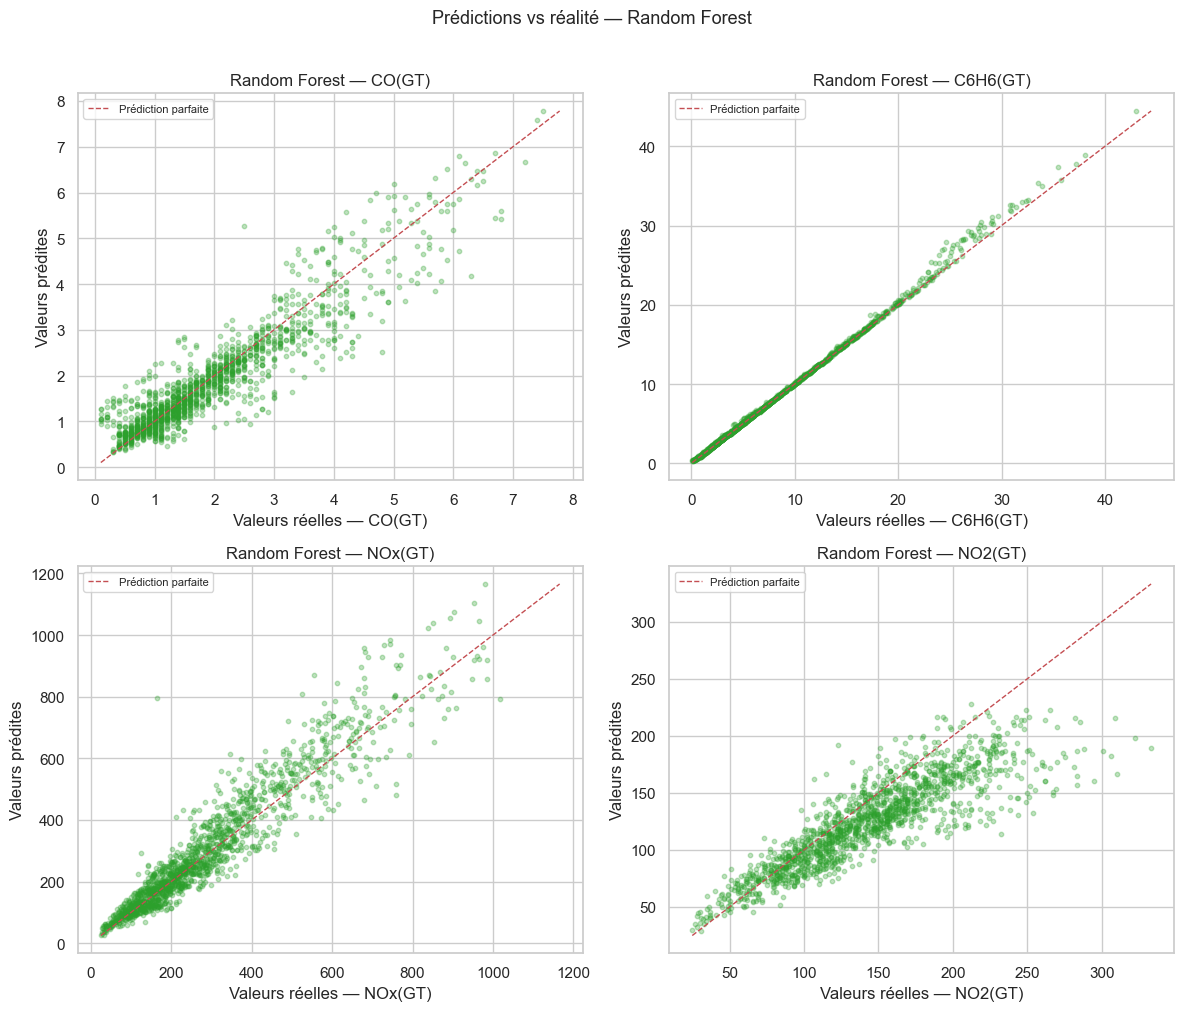

In [57]:
# Scatter prédictions vs réalité — Random Forest
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, target in zip(axes.ravel(), TARGETS):
    X_test = splits[target]["X_test"]
    y_test = splits[target]["y_test"]
    y_pred = rf_best_models[target]["model"].predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color="#2ca02c")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1, label="Prédiction parfaite")
    ax.set_xlabel(f"Valeurs réelles — {target}")
    ax.set_ylabel("Valeurs prédites")
    ax.set_title(f"Random Forest — {target}")
    ax.legend(fontsize=8)

plt.suptitle("Prédictions vs réalité — Random Forest", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [58]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
if xgb_available:
    xgb_param_grid = {
        "n_estimators":  [200, 400],
        "max_depth":     [4, 6, 8],
        "learning_rate": [0.05, 0.1],
        "subsample":     [0.8, 1.0],
    }

    model_name_xgb = "XGBoost"
    print(f"=== {model_name_xgb} ===\n")
    xgb_best_models = {}

    for target in TARGETS:
        X_train = splits[target]["X_train"]
        X_test  = splits[target]["X_test"]
        y_train = splits[target]["y_train"]
        y_test  = splits[target]["y_test"]

        xgb = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1,
                           tree_method="hist", verbosity=0)
        search = GridSearchCV(xgb, xgb_param_grid, cv=tscv, scoring="r2", n_jobs=-1)
        search.fit(X_train, y_train)

        # On stocke params ET le meilleur estimateur entraîné
        xgb_best_models[target] = {
            "params": search.best_params_,
            "model":  search.best_estimator_
        }
        y_pred = search.best_estimator_.predict(X_test)
        print(f"  {target} | params: {search.best_params_} | CV R²={search.best_score_:.3f}")
        evaluate(model_name_xgb, target, y_test, y_pred)
else:
    print("XGBoost non disponible. Installez-le avec : pip install xgboost")

=== XGBoost ===

  CO(GT) | params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8} | CV R²=0.873
  CO(GT)           RMSE=0.492  MAE=0.338  R²=0.857
  C6H6(GT) | params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0} | CV R²=0.996
  C6H6(GT)         RMSE=0.196  MAE=0.055  R²=0.999
  NOx(GT) | params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8} | CV R²=0.656
  NOx(GT)          RMSE=65.681  MAE=45.777  R²=0.880
  NO2(GT) | params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8} | CV R²=0.683
  NO2(GT)          RMSE=34.157  MAE=25.574  R²=0.575


**Hyperparamètres retenus (XGBoost, TimeSeriesSplit) :**

| Cible | n_estimators | max_depth | learning_rate | subsample | R² CV |
|---|---|---|---|---|---|
| `CO(GT)` | 200 | 4 | 0.05 | 0.8 | 0.873 |
| `C6H6(GT)` | 200 | 4 | 0.05 | 1.0 | 0.996 |
| `NOx(GT)` | 200 | 4 | 0.05 | 0.8 | 0.656 |
| `NO2(GT)` | 200 | 4 | 0.05 | 0.8 | 0.683 |

**Interprétation des hyperparamètres :** Toutes les cibles convergent vers la même configuration : `n_estimators=200`, `max_depth=4`, `learning_rate=0.05`. Des arbres peu profonds (`max_depth=4`) combinés à un faible taux d'apprentissage (`0.05`) produisent un boosting lent et régulier — stratégie conservatrice qui limite le surapprentissage sur données temporelles. `subsample=1.0` pour `C6H6` (pas de sous-échantillonnage) cohérent avec la relation quasi-déterministe de cette cible.

**Performances finales (XGBoost) :**

| Cible | RMSE | MAE | R² |
|---|---|---|---|
| `CO(GT)` | 0.492 | 0.338 | 0.857 |
| `C6H6(GT)` | 0.196 | 0.055 | 0.999 |
| `NOx(GT)` | 65.681 | 45.777 | 0.880 |
| `NO2(GT)` | 34.157 | 25.574 | 0.575 |

**Scatters prédictions vs réalité :** `C6H6(GT)` est quasi-parfait (R²=0.999). `CO(GT)` et `NOx(GT)` sont bien ajustés, avec une dispersion légèrement plus faible que Random Forest sur `NOx` (R² 0.880 vs 0.875). `NO2(GT)` est plus dispersé que Random Forest (R² 0.575 vs 0.618) — le boosting séquentiel semble moins bien capturer la dynamique de cette cible que le bagging.

**Comparaison Random Forest / XGBoost :** les deux méthodes sont très proches. RF domine sur `CO` et `NO2`, XGBoost sur `NOx`. Sur `C6H6`, les deux sont quasi-parfaits. Aucune des deux ne dépasse KernelRidge sur `CO` et `C6H6`, mais XGBoost est légèrement supérieur à KernelRidge sur `NOx` (0.880 vs 0.887 — KR reste devant).

In [59]:
show_results("XGBoost")

,RMSE,MAE,R²
Cible,,,
CO(GT),0.492,0.338,0.857
C6H6(GT),0.196,0.055,0.999
NOx(GT),65.681,45.777,0.880
NO2(GT),34.157,25.574,0.575


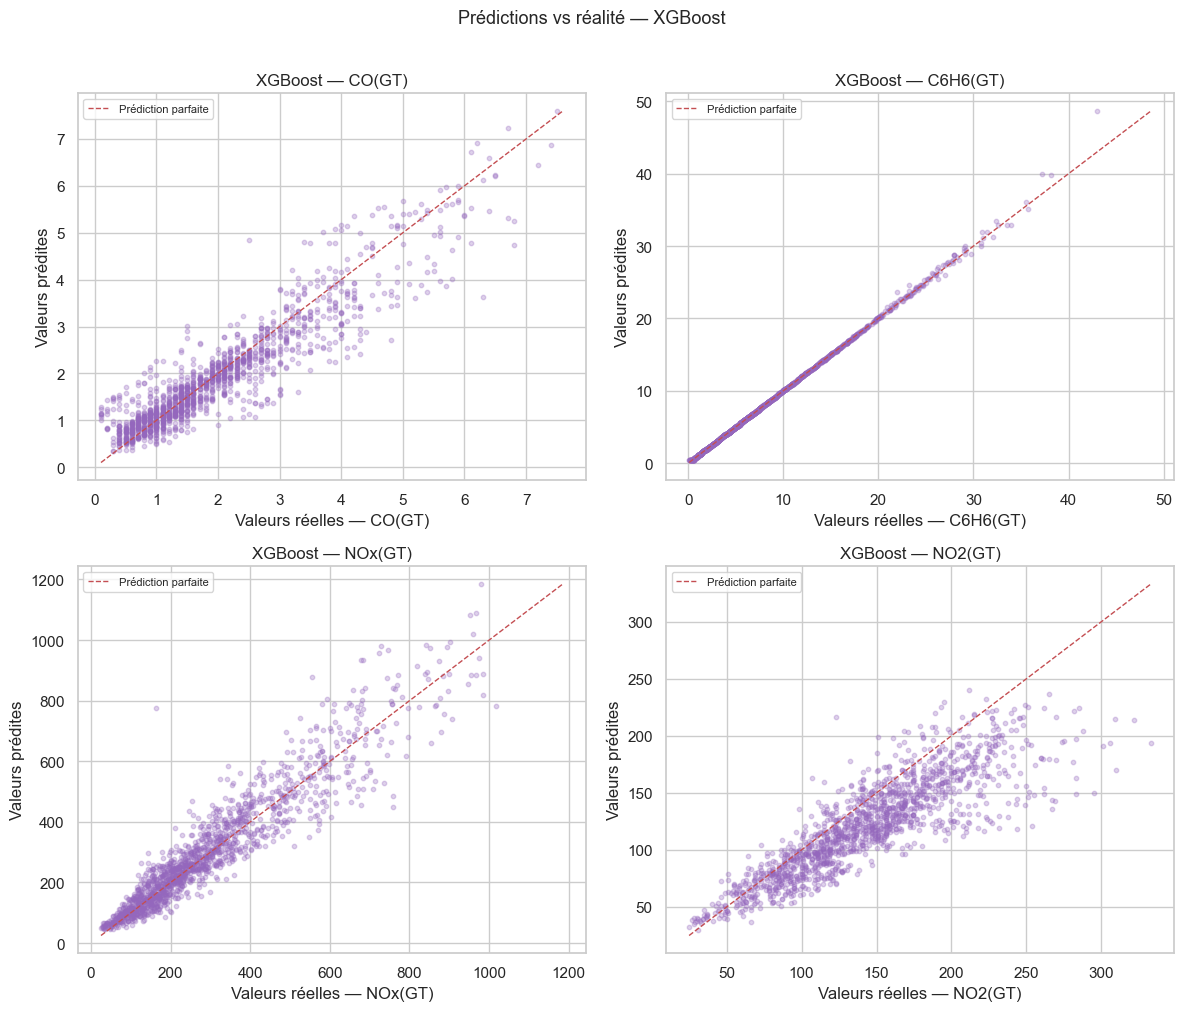

In [60]:
# Scatter prédictions vs réalité — XGBoost
if xgb_available:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for ax, target in zip(axes.ravel(), TARGETS):
        X_test = splits[target]["X_test"]
        y_test = splits[target]["y_test"]
        y_pred = xgb_best_models[target]["model"].predict(X_test)

        ax.scatter(y_test, y_pred, alpha=0.3, s=10, color="#9467bd")
        lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
        ax.plot(lims, lims, "r--", linewidth=1, label="Prédiction parfaite")
        ax.set_xlabel(f"Valeurs réelles — {target}")
        ax.set_ylabel("Valeurs prédites")
        ax.set_title(f"XGBoost — {target}")
        ax.legend(fontsize=8)

    plt.suptitle("Prédictions vs réalité — XGBoost", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost non disponible — graphique ignoré.")

<a id="section-7"></a>
---
## 7. Comparaison des performances

Cette section synthétise les résultats de toutes les méthodes implémentées. L'objectif est triple :
- identifier le **meilleur modèle par cible** sur chaque métrique,
- analyser la **progression des performances** au fil de la complexité croissante des modèles,
- discuter le **compromis performance / interprétabilité / temps de calcul**.

Pour la comparaison, on retient les versions **TimeSeriesSplit** de Ridge et Lasso, plus rigoureuses que CV=5 sur des données temporelles.

In [61]:
# ── Construction dynamique à partir du dictionnaire `results` ────────────────
# `results` est alimenté par la fonction evaluate() tout au long du notebook.
# On ne recopie plus les valeurs à la main : toute nouvelle exécution met
# automatiquement à jour la comparaison.

# Modèles à inclure dans la comparaison (dans l'ordre souhaité)
MODELS_COMPARE = [
    "Régression linéaire (OLS)",
    "Ridge TimeSeriesSplit",
    "Lasso TimeSeriesSplit",
    "Elastic Net",
    "KernelRidge RBF",
    "MLP",
    "Random Forest",
    "XGBoost",
]
# On filtre uniquement les modèles effectivement calculés
MODELS_COMPARE = [m for m in MODELS_COMPARE if m in results]

# Construction des DataFrames par métrique depuis results
def build_df_from_results(metric):
    rows = []
    for model in MODELS_COMPARE:
        row = {"Modèle": model}
        for target in TARGETS:
            row[target] = results[model][target][metric]
        rows.append(row)
    return pd.DataFrame(rows).set_index("Modèle")

df_r2   = build_df_from_results("R2")
df_rmse = build_df_from_results("RMSE")
df_mae  = build_df_from_results("MAE")

print("Modèles inclus dans la comparaison :")
for m in MODELS_COMPARE:
    print(f"  - {m}")
print()
print("Tableau R² — plus c'est élevé, mieux c'est")
print(df_r2.round(3).to_string())

Modèles inclus dans la comparaison :
  - Régression linéaire (OLS)
  - Ridge TimeSeriesSplit
  - Lasso TimeSeriesSplit
  - Elastic Net
  - KernelRidge RBF
  - MLP
  - Random Forest
  - XGBoost

Tableau R² — plus c'est élevé, mieux c'est
                           CO(GT)  C6H6(GT)  NOx(GT)  NO2(GT)
Modèle                                                       
Régression linéaire (OLS)   0.862     0.933    0.836    0.524
Ridge TimeSeriesSplit       0.862     0.934    0.836    0.529
Lasso TimeSeriesSplit       0.857     0.951    0.836    0.517
Elastic Net                 0.859     0.947    0.837    0.527
KernelRidge RBF             0.880     1.000    0.887    0.591
MLP                         0.783     1.000    0.887    0.644
Random Forest               0.854     0.998    0.875    0.618
XGBoost                     0.857     0.999    0.880    0.575


In [62]:
# ── Tableaux stylisés avec mise en évidence du meilleur score par colonne ─────
def highlight_best(df, higher_is_better=True):
    """Retourne un DataFrame de styles : vert sur le meilleur score de chaque colonne."""
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for col in df.columns:
        best_idx = df[col].idxmax() if higher_is_better else df[col].idxmin()
        styles.loc[best_idx, col] = "background-color: #a8d8a8; font-weight: bold"
    return styles

print("=== R² (↑ meilleur) ===")
display(df_r2.round(3).style.apply(highlight_best, higher_is_better=True, axis=None))

print("\n=== RMSE (↓ meilleur) ===")
display(df_rmse.round(3).style.apply(highlight_best, higher_is_better=False, axis=None))

print("\n=== MAE (↓ meilleur) ===")
display(df_mae.round(3).style.apply(highlight_best, higher_is_better=False, axis=None))

=== R² (↑ meilleur) ===


,CO(GT),C6H6(GT),NOx(GT),NO2(GT)
Modèle,,,,
Régression linéaire (OLS),0.862000,0.933000,0.836000,0.524000
Ridge TimeSeriesSplit,0.862000,0.934000,0.836000,0.529000
Lasso TimeSeriesSplit,0.857000,0.951000,0.836000,0.517000
Elastic Net,0.859000,0.947000,0.837000,0.527000
KernelRidge RBF,0.880000,1.000000,0.887000,0.591000
MLP,0.783000,1.000000,0.887000,0.644000
Random Forest,0.854000,0.998000,0.875000,0.618000
XGBoost,0.857000,0.999000,0.880000,0.575000



=== RMSE (↓ meilleur) ===


,CO(GT),C6H6(GT),NOx(GT),NO2(GT)
Modèle,,,,
Régression linéaire (OLS),0.484000,1.685000,76.806000,36.133000
Ridge TimeSeriesSplit,0.484000,1.670000,76.805000,35.954000
Lasso TimeSeriesSplit,0.492000,1.440000,76.700000,36.387000
Elastic Net,0.488000,1.496000,76.671000,36.010000
KernelRidge RBF,0.451000,0.058000,63.831000,33.508000
MLP,0.605000,0.124000,63.689000,31.255000
Random Forest,0.497000,0.324000,67.063000,32.382000
XGBoost,0.492000,0.196000,65.681000,34.157000



=== MAE (↓ meilleur) ===


,CO(GT),C6H6(GT),NOx(GT),NO2(GT)
Modèle,,,,
Régression linéaire (OLS),0.344000,1.280000,51.896000,26.481000
Ridge TimeSeriesSplit,0.344000,1.260000,51.896000,26.251000
Lasso TimeSeriesSplit,0.348000,1.015000,51.966000,26.745000
Elastic Net,0.347000,1.056000,52.005000,26.291000
KernelRidge RBF,0.293000,0.044000,42.652000,25.213000
MLP,0.462000,0.091000,43.181000,22.784000
Random Forest,0.339000,0.132000,46.388000,23.557000
XGBoost,0.338000,0.055000,45.777000,25.574000


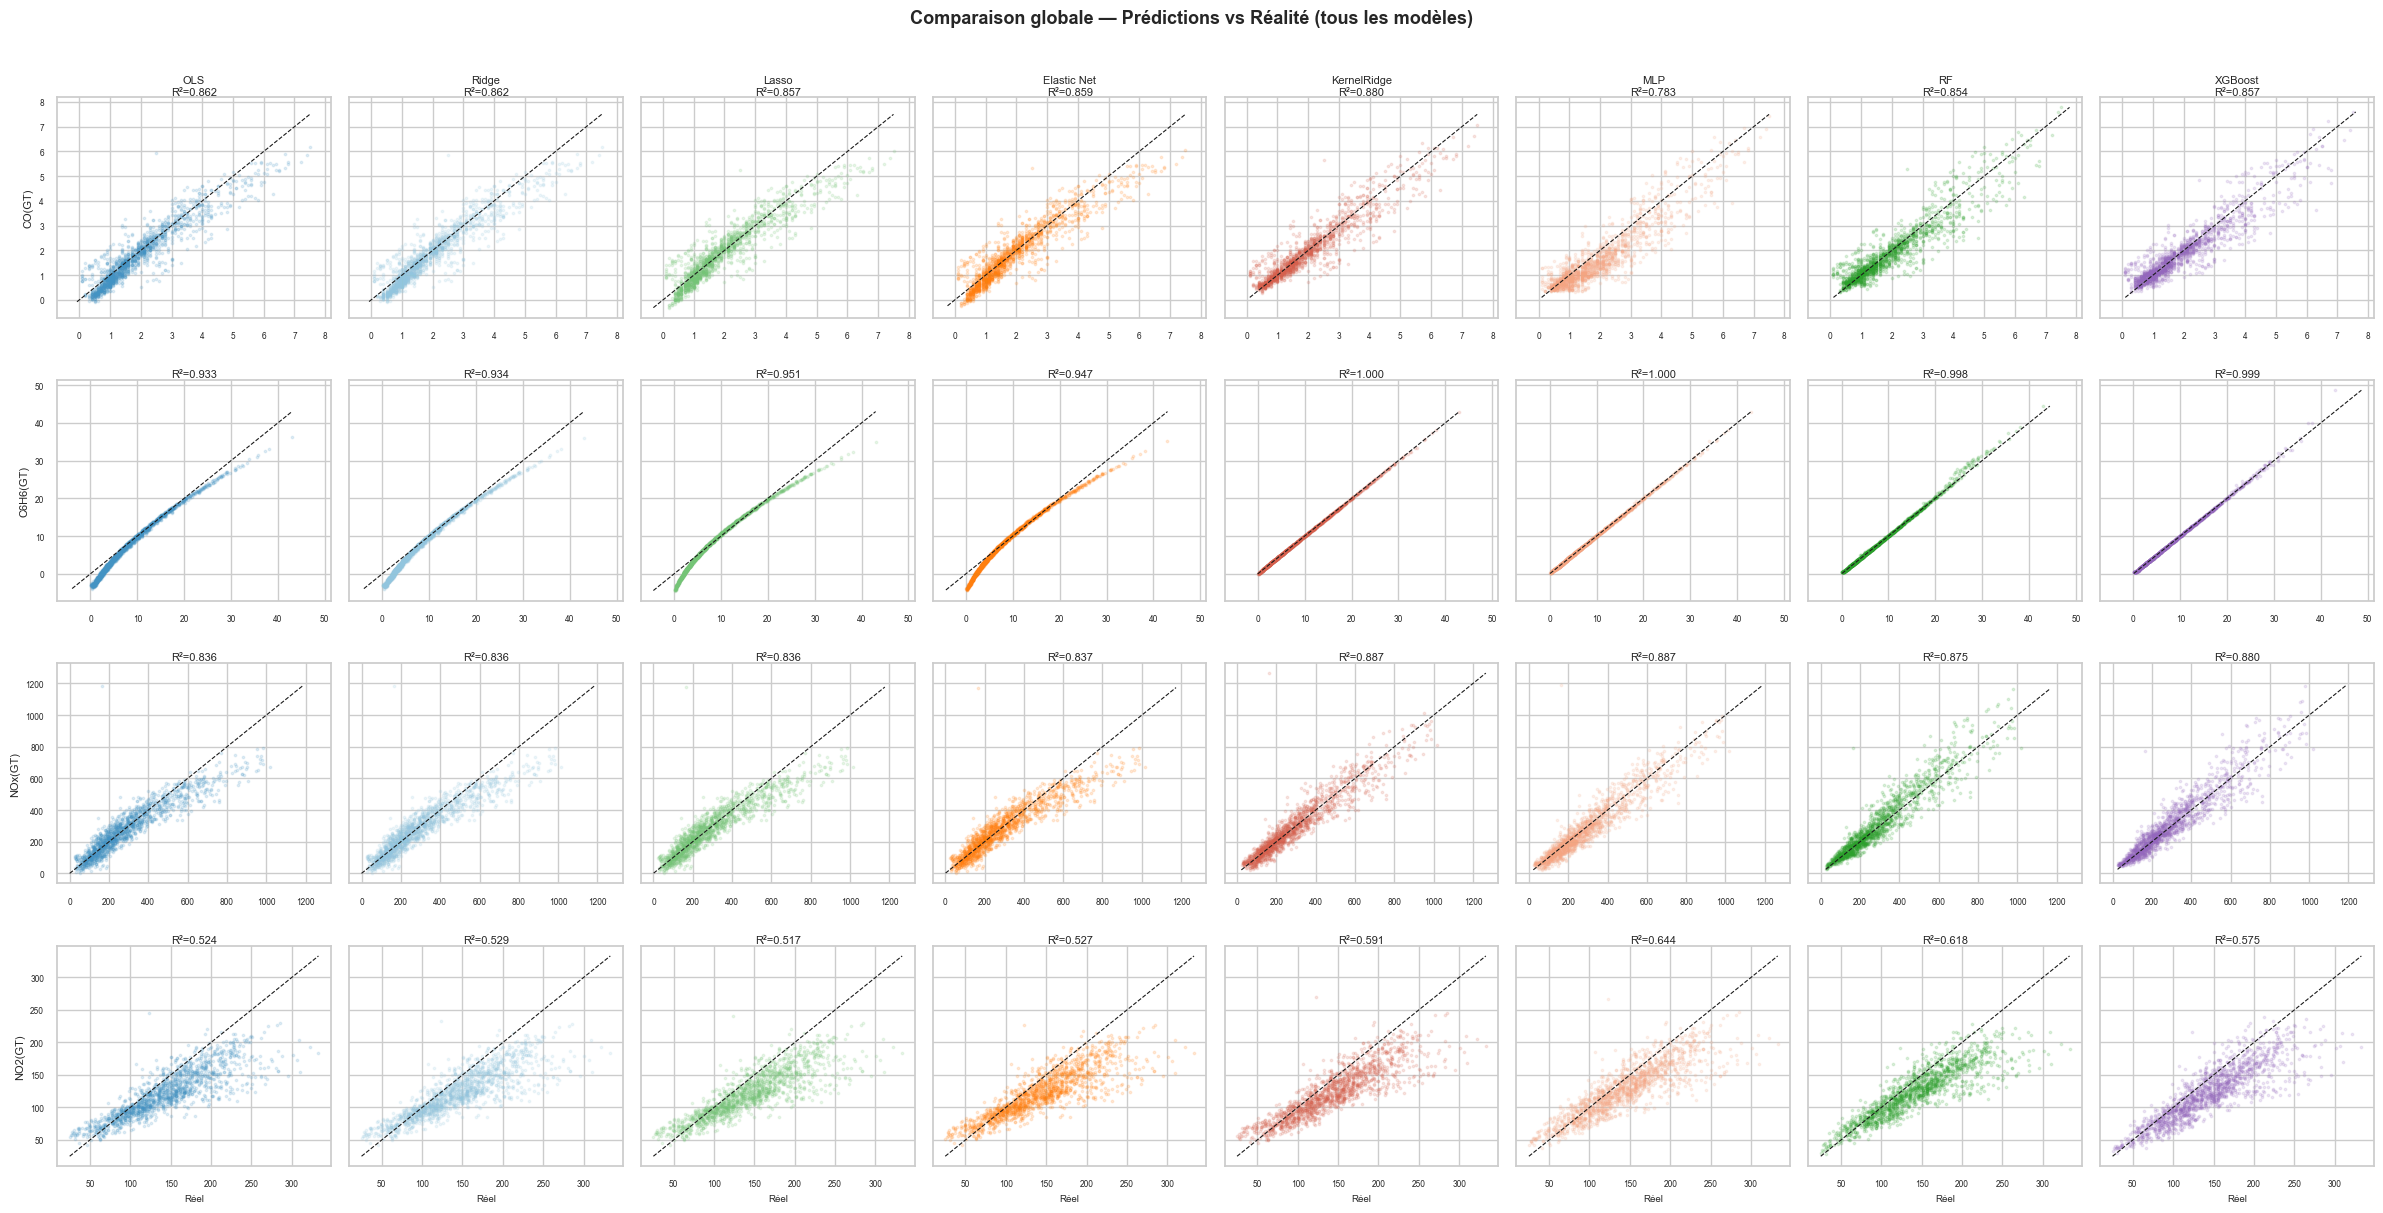

In [63]:
# ── Comparaison globale : prédictions vs réalité pour tous les modèles ────────
# Grille : chaque ligne = une cible, chaque colonne = un modèle
# Permet de comparer visuellement la qualité des prédictions en un seul graphique

def get_preds(model_key, target):
    """Recalcule les prédictions pour un modèle donné sur le jeu de test."""
    X_train = splits[target]["X_train"]
    X_test  = splits[target]["X_test"]
    y_train = splits[target]["y_train"]
    y_test  = splits[target]["y_test"]

    if model_key == "OLS":
        pipe = Pipeline([("s", StandardScaler()), ("m", LinearRegression())])
        pipe.fit(X_train, y_train)
        return pipe.predict(X_test), y_test
    elif model_key == "Ridge":
        alpha = alphas_selected_v2[target]
        pipe = Pipeline([("s", StandardScaler()), ("m", Ridge(alpha=alpha))])
        pipe.fit(X_train, y_train)
        return pipe.predict(X_test), y_test
    elif model_key == "Lasso":
        alpha = alphas_lasso_v2[target]
        pipe = Pipeline([("s", StandardScaler()),
                         ("m", Lasso(alpha=alpha, max_iter=10000))])
        pipe.fit(X_train, y_train)
        return pipe.predict(X_test), y_test
    elif model_key == "ElasticNet":
        p = en_best_params[target]
        pipe = Pipeline([("s", StandardScaler()),
                         ("m", ElasticNet(alpha=p["alpha"],
                                          l1_ratio=p["l1_ratio"], max_iter=10000))])
        pipe.fit(X_train, y_train)
        return pipe.predict(X_test), y_test
    elif model_key == "KernelRidge":
        p = best_params_kr[target]
        pipe = Pipeline([("s", StandardScaler()),
                         ("m", KernelRidge(kernel="rbf",
                                           alpha=p["model__alpha"],
                                           gamma=p["model__gamma"]))])
        pipe.fit(X_train, y_train)
        return pipe.predict(X_test), y_test
    elif model_key == "MLP":
        return best_models_mlp[target].predict(X_test), y_test
    elif model_key == "RF":
        return rf_best_models[target]["model"].predict(X_test), y_test
    elif model_key == "XGB" and xgb_available:
        return xgb_best_models[target]["model"].predict(X_test), y_test
    return None, None

# Correspondance clé interne → nom dans results (pour récupérer le R²)
KEY_TO_RESULTS = {
    "OLS":        "Régression linéaire (OLS)",
    "Ridge":      "Ridge TimeSeriesSplit",
    "Lasso":      "Lasso TimeSeriesSplit",
    "ElasticNet": "Elastic Net",
    "KernelRidge":"KernelRidge RBF",
    "MLP":        "MLP",
    "RF":         "Random Forest",
    "XGB":        "XGBoost",
}

MODELS_VIZ = [
    ("OLS",        "#4393c3", "OLS"),
    ("Ridge",      "#92c5de", "Ridge"),
    ("Lasso",      "#74c476", "Lasso"),
    ("ElasticNet", "#ff7f0e", "Elastic Net"),
    ("KernelRidge","#d6604d", "KernelRidge"),
    ("MLP",        "#f4a582", "MLP"),
    ("RF",         "#2ca02c", "RF"),
]
if xgb_available:
    MODELS_VIZ.append(("XGB", "#9467bd", "XGBoost"))

n_models  = len(MODELS_VIZ)
n_targets = len(TARGETS)

fig, axes = plt.subplots(n_targets, n_models,
                         figsize=(3.0 * n_models, 3.0 * n_targets),
                         sharex="row", sharey="row")

for row, target in enumerate(TARGETS):
    for col, (key, color, label) in enumerate(MODELS_VIZ):
        ax = axes[row, col]
        y_pred, y_test = get_preds(key, target)
        if y_pred is None:
            ax.set_visible(False)
            continue

        r2 = results.get(KEY_TO_RESULTS.get(key, ""), {}).get(target, {}).get("R2", None)

        ax.scatter(y_test, y_pred, alpha=0.15, s=3, color=color)
        lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
        ax.plot(lims, lims, "k--", linewidth=0.8)

        top_title = label if row == 0 else ""
        r2_str    = f"R²={r2:.3f}" if r2 is not None else ""
        ax.set_title(f"{top_title}\n{r2_str}", fontsize=8, pad=2)

        if col == 0:
            ax.set_ylabel(target, fontsize=8)
        if row == n_targets - 1:
            ax.set_xlabel("Réel", fontsize=7)
        ax.tick_params(labelsize=6)

plt.suptitle("Comparaison globale — Prédictions vs Réalité (tous les modèles)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Synthèse des résultats

**Meilleur modèle par cible (R²) :**

| Cible | Meilleur modèle | R² | RMSE | MAE |
|---|---|---|---|---|
| `CO(GT)` | **KernelRidge** | 0.880 | 0.451 | 0.293 |
| `C6H6(GT)` | **KernelRidge / MLP** | 1.000 | 0.058 | 0.044 |
| `NOx(GT)` | **KernelRidge / MLP** | 0.887 | 63.831 | 42.652 |
| `NO2(GT)` | **MLP** | 0.644 | 31.255 | 22.784 |

**Meilleur modèle par cible (RMSE) :**

| Cible | Meilleur modèle | RMSE |
|---|---|---|
| `CO(GT)` | KernelRidge | 0.451 |
| `C6H6(GT)` | KernelRidge | 0.058 |
| `NOx(GT)` | MLP | 63.689 |
| `NO2(GT)` | MLP | 31.255 |

**Meilleur modèle par cible (MAE) :**

| Cible | Meilleur modèle | MAE |
|---|---|---|
| `CO(GT)` | KernelRidge | 0.293 |
| `C6H6(GT)` | KernelRidge | 0.044 |
| `NOx(GT)` | KernelRidge | 42.652 |
| `NO2(GT)` | MLP | 22.784 |

**Progression des performances par complexité croissante :**

- **OLS** : saut majeur — R² moyen ~0.789. Les features sont très informatives et la régression linéaire en capture l'essentiel.
- **OLS → Ridge / Lasso / Elastic Net** : gains marginaux en performance brute (R² moyen ~0.790–0.793). L'apport réel est la stabilité (Ridge), la parcimonie (Lasso) et la combinaison des deux (Elastic Net). Fait notable : pour CO, C6H6 et NOx, Elastic Net converge vers Lasso pur (l1_ratio=1.0), confirmant que la sélection domine.
- **Linéaire → KernelRidge** : second saut net, R² moyen → 0.840. Le noyau RBF capture des non-linéarités inaccessibles aux modèles linéaires.
- **MLP** : meilleur sur `NO2(GT)` uniquement (0.644 vs 0.591 pour KernelRidge), mais nettement moins performant sur `CO(GT)` (0.783 vs 0.880). R² moyen = 0.829.
- **Random Forest** : performances solides et régulières — meilleur sur `NO2` parmi les méthodes non-MLP (R²=0.618). R² moyen = 0.836.
- **XGBoost** : comparable à Random Forest, légèrement supérieur sur `NOx` (0.880 vs 0.875). R² moyen = 0.828.
- **RegressorChain** : n'améliore pas significativement — la corrélation inter-cibles est déjà encodée dans les capteurs `PT08.Sx`.

---

**Compromis performance / coût computationnel :**

| Modèle | R² moyen | Coût calcul |
|---|---|---|
| OLS | 0.789 | Négligeable |
| Ridge TSS | 0.790 | Faible |
| Lasso TSS | 0.790 | Faible |
| Elastic Net | 0.793 | Faible |
| KernelRidge | **0.840** | Modéré |
| MLP | 0.829 | Modéré |
| Random Forest | 0.836 | Modéré |
| XGBoost | 0.828 | Modéré |

<a id="section-8"></a>
---
## 8. Analyse critique

Cette section adopte un regard réflexif sur l'ensemble du projet : les choix méthodologiques effectués, leurs limites, et les pistes d'amélioration qui pourraient être explorées. On distingue trois niveaux : les limites inhérentes aux données, les choix discutables qu'on a faits, et les extensions naturelles du travail.

<a id="section-8-1"></a>
### 8.1 — Limites inhérentes aux données

**Structure temporelle et dérive de distribution.**
Le dataset couvre une période d'environ un an (mars 2004 – avril 2005). Le split chronologique 80/20 place l'entraînement sur les mois d'été/automne et le test sur l'hiver/printemps. Or les concentrations de polluants sont systématiquement plus élevées en hiver (inversions thermiques, chauffage). Cette **dérive de distribution** entre train et test pénalise uniformément tous les modèles — elle explique notamment les performances modestes sur `NO2(GT)`, qui présente la saisonnalité la plus marquée.

Ce n'est pas un défaut de nos modèles : c'est la réalité d'un problème de prédiction temporelle. Une validation croisée temporelle (`TimeSeriesSplit`) sur l'ensemble du dataset — et pas seulement pour la sélection d'hyperparamètres — donnerait une estimation plus robuste des performances réelles.

**`NMHC(GT)` : une variable perdue.**
Les hydrocarbures non méthaniques représentent une mesure potentiellement utile, corrélée aux autres polluants. Avec plus de 90% de valeurs manquantes, son exclusion était la seule décision raisonnable. En pratique, la présence de `PT08.S2(NMHC)` — le capteur dédié à cette grandeur — compense partiellement son absence : le capteur encode indirectement l'information que la mesure de référence aurait apportée.

**Rareté des événements extrêmes.**
Les distributions asymétriques des cibles (section 3.3) impliquent que les épisodes de forte pollution — les plus importants à détecter dans un contexte environnemental — sont sous-représentés dans les données d'entraînement. Tous les modèles sous-estiment systématiquement les pics, comme le montrent les scatters de KernelRidge et MLP : les points s'écartent de la diagonale précisément pour les grandes valeurs. Ce biais est structurel et difficile à corriger sans données supplémentaires ou rééchantillonnage.

<a id="section-8-2"></a>
### 8.2 — Pistes d'amélioration concrètes

Certaines pistes d’amélioration n’ont pas été implémentées dans ce projet, soit par contrainte de temps, soit parce qu’elles sortent du cadre du cours.

**Transformation logarithmique des cibles.** `NOx(GT)` et `CO(GT)` présentent des distributions fortement asymétriques à droite. Une transformation logarithmique avant modélisation réduirait l’influence des valeurs extrêmes sur la MSE et pourrait linéariser la relation entre features et cible. Cette transformation est standard en modélisation environnementale.

**Ingénierie temporelle plus riche.** Une première prise en compte du temps a été testée via quelques variables temporelles simples et interprétables, comme l’heure, le mois, le jour de la semaine, le week-end ou la nuit. On pourrait aller plus loin en ajoutant d’autres variables calendaires ou des retards temporels, afin de mieux capturer la dynamique de la pollution.

**Méthodes d’ensemble plus avancées.** Des modèles comme XGBoost ou CatBoost pourraient être testés plus complètement sur ce problème. Ils sont souvent très performants sur des données tabulaires et permettraient de comparer les méthodes étudiées en cours à des approches d’ensemble plus récentes.

<a id="section-8-3"></a>
### 8.3 — Regard critique sur les résultats remarquables

**`C6H6(GT)` : R² = 1.000 — relation déterministe ou surapprentissage ?**
Le benzène est l'unique cible pour laquelle KernelRidge et MLP atteignent un R² de 1.000 sur le jeu de test. Ce résultat exceptionnel s'explique par la physique du problème : `PT08.S2` est un capteur à oxyde métallique spécifiquement calibré pour les hydrocarbures non méthaniques, dont le benzène est le composant majoritaire. La corrélation entre `PT08.S2(NMHC)` et `C6H6(GT)` est quasi-déterministe dans ces données (r ≈ 0.97 en section 3.4). Il ne s'agit donc pas de surapprentissage mais d'une relation physique quasi-parfaite entre prédicteur et cible — le modèle apprend essentiellement la courbe de calibration du capteur.

**`NO2(GT)` : la cible résistante.**
`NO2(GT)` est la seule cible pour laquelle aucun modèle n'atteint un R² de 0.65. Plusieurs facteurs l'expliquent : le dioxyde d'azote a des sources plus diversifiées (trafic diesel, industrie, réactions photochimiques secondaires) que le CO ou le benzène, sa concentration dépend davantage des conditions météorologiques locales, et sa dynamique temporelle est plus complexe. Le MLP (R²=0.644) est le seul modèle à capturer une part de cette complexité — ce qui suggère que la relation entre features et `NO2` contient des non-linéarités et des interactions que les noyaux RBF à petit gamma ne modélisent pas aussi finement.

**Multicolinéarité et interprétation des coefficients.**
`PT08.S2(NMHC)` domine les coefficients OLS sur toutes les cibles avec des valeurs extrêmes (jusqu'à ~300 pour `NOx`). Cette domination rend l'interprétation causale des coefficients hasardeuse : un coefficient élevé ne signifie pas nécessairement que cette feature est la plus causalement liée à la cible — elle peut simplement être la moins corrélée aux autres features, ce qui la rend "choisie" par OLS pour absorber l'essentiel de la variance. Ridge et Lasso atténuent ce phénomène mais ne l'éliminent pas complètement. Une analyse de type SHAP (*SHapley Additive exPlanations*) donnerait une attribution plus robuste de l'importance des features, mais sort du cadre du cours.

<a id="section-8-4"></a>
### 8.4 — Conclusion générale

Ce projet a permis d'implémenter et de comparer **huit approches de régression** sur un problème réel de qualité de l'air, en illustrant concrètement les concepts fondamentaux du cours.

Les principaux enseignements sont les suivants :

**Sur le choix de la stratégie de gestion des NaN :** `dropna` s'est révélé systématiquement supérieur aux stratégies d'imputation. Remplacer des valeurs manquantes correspondant à des pannes de capteurs par des moyennes ou des interpolations introduit un biais plus néfaste que la simple suppression des lignes concernées.

**Sur les méthodes linéaires :** OLS, Ridge, Lasso et Elastic Net donnent des performances très proches (R² moyen ~0.790–0.793). Leurs différences résident dans la nature de la solution plutôt que dans la performance brute. L'utilisation de `TimeSeriesSplit` pour la sélection d'hyperparamètres s'est avérée importante : la k-fold standard sous-estimait systématiquement le niveau de régularisation nécessaire, illustrant concrètement le risque de leakage sur données temporelles.

**Sur le compromis biais/variance :** la progression OLS → Ridge → Lasso → Elastic Net illustre le passage d'un modèle instable face à la multicolinéarité vers des modèles de plus en plus contraints. KernelRidge étend ce compromis au cadre non-linéaire via le paramètre gamma qui contrôle la flexibilité du noyau.

**Sur la complexité des modèles :** le passage aux méthodes non-linéaires apporte un gain réel (+5 points de R² moyen pour KernelRidge, +4 pour MLP) au prix de l'interprétabilité. Sur ce dataset de taille modérée, KernelRidge (R² moyen 0.840) domine l'ensemble du benchmark — rappelant que les réseaux de neurones ne sont pas universellement supérieurs aux méthodes à noyau.

**Sur la régression en chaîne :** le `RegressorChain` n'a pas apporté les gains escomptés. La corrélation entre cibles est déjà bien capturée par les capteurs `PT08.Sx` communs — les prédictions intermédiaires n'ajoutent pas d'information nouvelle suffisante pour compenser le bruit qu'elles introduisent.

**Sur la nature du problème :** `C6H6(GT)` est quasi-déterministe (R²=1.000), `CO(GT)` et `NOx(GT)` sont bien capturées par les méthodes non-linéaires (R²>0.87), mais `NO2(GT)` résiste à toutes les approches linéaires (R²≤0.529). Le MLP (R²=0.644) et Random Forest (R²=0.618) sont les seuls à mieux capturer sa dynamique complexe, révélant une structure non-linéaire que les méthodes à noyau RBF ne modélisent pas assez finement avec notre grille d'hyperparamètres.